In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord
from scipy import linalg
from scipy.special import gamma
from dynesty.results import Results
import io
from PIL import Image
from scipy.special import j0
import mcfit
from astropy import constants
import time
import copy
from scipy import special
from healpy.newvisufunc import projview
from scipy.special import sici, exp1
import matplotlib.colors as mcolors

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/mcfit/kernels.py:10: SyntaxWarning: invalid escape sequence '\l'
  """Real deriv is wrt :math:`t`, complex deriv is wrt :math:`\ln t`"""


In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5 #20.5

In [4]:
nthreads = 18

In [5]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)

In [6]:
cosmo_planck18 = ccl.Cosmology(
    Omega_c=Planck18.Odm0,
    Omega_b=Planck18.Ob0,
    h=Planck18.h,
    Neff=Planck18.Neff,
    T_CMB=Planck18.Tcmb0.value,
    m_nu=Planck18.m_nu,
    sigma8=0.8102,   # or pull from wherever your actual source specifies Planck18's sigma8
    n_s=0.9665        # same
)

In [7]:
Delta = 200
delta_c = 1.686

In [8]:
hmf = {mass_def: ccl.halos.MassFuncTinker10(mass_def = mass_def) for mass_def in ['200m', '200c']} #ccl.halos.MassFuncTinker10()

In [9]:
NSIDE = 64

In [10]:
M_max = 16.8 #15

## Define functions

In [285]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [286]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [287]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [288]:
method = 'pyccl' #'pyccl' #'manual'

In [289]:
mass_def = '200c' #'200c' #'200m'

In [290]:
b1_E_func_tinker10 = {mass_def: ccl.halos.hbias.tinker10.HaloBiasTinker10(mass_def=mass_def) for mass_def in ['200m', '200c']}

In [291]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf[mass_def], recenter = True, units = '(h/Mpc)^3'):

    if recenter == True:
        bins = quaia.recenter(bins)
    if units == '(h/Mpc)^3':
        nm = hmf(cosmo, bins, a)/cosmo['h']**3*(cu.littleh/u.Mpc)**3
    else:
        nm = hmf(cosmo, bins, a)*(1/u.Mpc)**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm # (units of Mpc/h)^3

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, method = method, hmf = hmf[mass_def], 
         b1_E_func_tinker10 = b1_E_func_tinker10[mass_def], b1_E_tinker = None, n_g_manual = None, calc_bias = True, units = '(h/Mpc)^3'):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf, units = units)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    if n_g_manual is None:
        n_g = np.trapz(n_g, bins)
        n_g_manual = n_g
        
    if calc_bias == False:
        return n_g

    else:
        
        dn_dm = nm/(bins*np.log(10))
    
        if b1_E_tinker is None:
            
            b1_E_tinker = b1_E_func(bins, a = a, cosmo = cosmo, mod = mod, method = method, b1_E_func_tinker10 = b1_E_func_tinker10)
        
        n_m[~np.isfinite(n_m)]=0 
        integrand = dn_dm*n_m
        integrand[np.isnan(integrand)]=0

        return bias_function(n_g_manual, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [292]:
def b1_E_func(bins, a = 1, cosmo = cosmo_planck18, Delta = Delta, delta_c = delta_c, mod = False, method = method, b1_E_func_tinker10 = b1_E_func_tinker10[mass_def]): #nu

    if method == 'pyccl':

        return b1_E_func_tinker10(cosmo, bins, a)

    else:

        Nu = nu(bins, a = a, cosmo = cosmo)
        
        if mod == False:
            y = np.log10(Delta)
            A =  1.0+0.24*y*np.exp(-(4/y)**4)
            a = 0.44*y-0.88
            B = 0.183
            b =  1.5
            C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
            c = 2.4
            
        else:
            A =  1.0
            a = 0.0906
            B = -4.5002
            b =  2.1419
            C = 4.9148
            c = 2.1419
        
        return 1-A*Nu**a/(Nu**a+delta_c**a)+B*Nu**b+C*Nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [293]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf[mass_def], units = '(h/Mpc)^3'):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf, units = units)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [294]:
def HOD_step(bins, fduty): #, M_min, recenter = False):

    return np.ones(np.shape(bins))*fduty

In [295]:
def HOD_scatter(bins, M_min, fduty, sigma):
    
    return fduty/2*special.erfc(np.log(10**M_min/bins)/(np.sqrt(2)*np.log(10)*sigma))

In [296]:
def N_c(bins_m, M_min, f_duty, M_max = M_max, sigma = 0):#, step = False): #, recenter = False): #bins_m

    n_m = HOD_scatter(bins_m, M_min, f_duty, sigma)
    
    # if np.all(bins_m[0]==10**M_min) and (step == True): # for step function HOD
    if np.all(bins_m[0]==10**M_min) and np.all(sigma==0): # for step function HOD

        return HOD_step(bins_m, f_duty) # M_min, f_duty, recenter = recenter)
        
    # elif np.any(bins_m==10**M_min): # for scatter HOD with point at Mmin
    
    n_m[bins_m==10**M_min]=f_duty/2
        
    return n_m

In [283]:
n_bins = 201

In [284]:
def n_DM(cosmo, a, M_min, hmf = hmf[mass_def], M_max = M_max, N = n_bins): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Visualize the luminosity threshold cuts and redshift bins

In [25]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])[:0:-1]
L_bins

array([-20., -25., -26., -27.])

In [26]:
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_orange = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_green = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
colors = ['Red', 'Orange', 'Green', 'Blue']

In [27]:
b = 30

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_27189/50625153.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax3.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.linspace(-32, -20, 30), alpha = 0.5, label = '$M_i\leq{}$'.format(L_bins[i]))
/tmp/ipykernel_27189/50625153.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_27189/50625153.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_27189/50625153.py:48: SyntaxWarning: invalid escape sequence '\

Pixels masked by MC but not already by selfunc: 2468
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.33              218365 vs 324336
Pixels masked by MC but not already by selfunc: 4785
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.30              453228 vs 648196
Pixels masked by MC but not already by selfunc: 2764
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.28              207602 vs 286508
Pixels masked by MC but not already by selfunc: 307
G20.5_zmin3.0zmax4.6_Lmax-20.0: 0.23              28043 vs 36458
Pixels masked by MC but not already by selfunc: 490
G20.5_zmin0.0zmax1.0_Lmax-25.0: 0.46              29985 vs 55261
Pixels masked by MC but not already by selfunc: 3840
G20.5_zmin1.0zmax2.0_Lmax-25.0: 0.33              336125 vs 502242
Pixels masked by MC but not already by selfunc: 2764
G20.5_zmin2.0zmax3.0_Lmax-25.0: 0.28              207602 vs 286508
Pixels masked by MC but not already by selfunc: 307
G20.5_zmin3.0zmax4.6_Lmax-25.0: 0.23              28043 vs 36458
Pixels masked by MC but not already by selfunc: 1

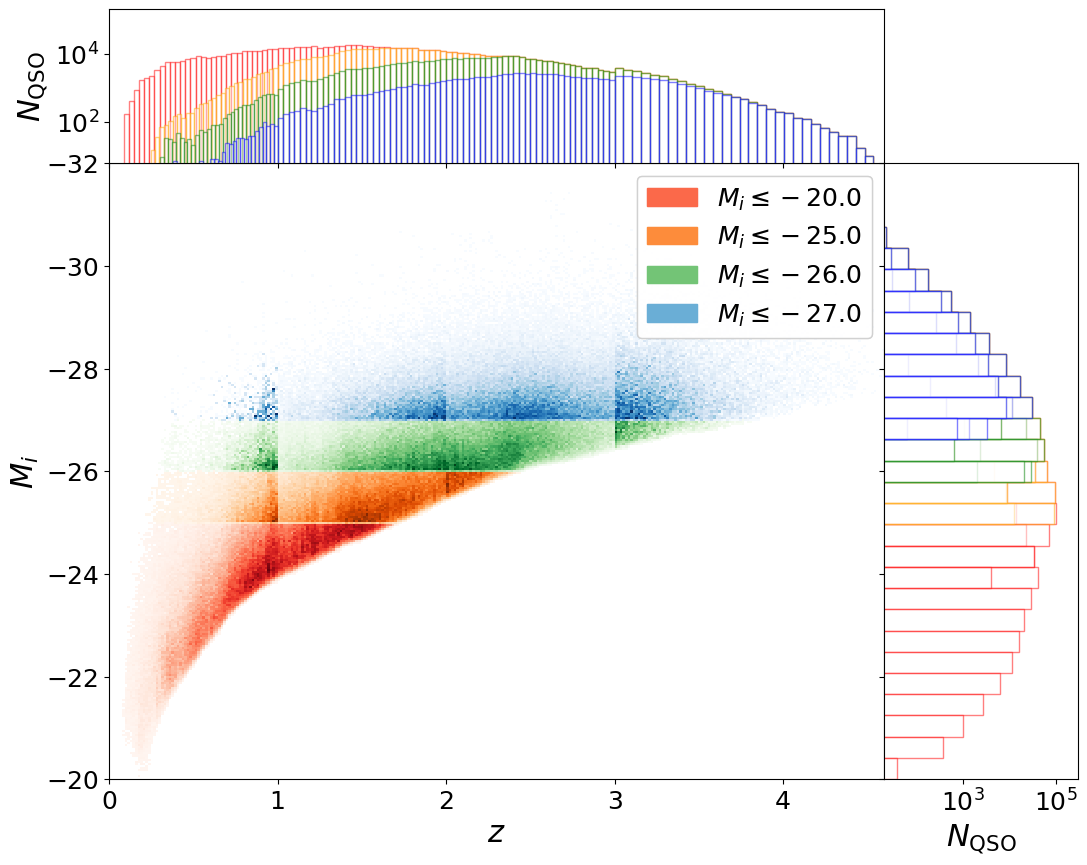

In [28]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)
fac_rand = 25

ax1 = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[0])
ax3 = fig.add_subplot(gs[3])

N = {L: [] for L in L_bins}

for i in range(len(L_bins)):
        
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                             bins = [z_bins, L_bins], tab_gcat_type = 'data', 
                                                                                              method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                              n_bins = [None, None], b = b, mask_type = 'b')
        quaia.absolute(tab_datahi_mask_zbin0, G_hi)
        h1, xedges, yedges, image = ax1.hist2d(tab_datahi_mask_zbin0['redshift_quaia'], tab_datahi_mask_zbin0['M_i'],
                                               cmap = plt.get_cmap('{}s'.format(colors[i])), bins = [np.linspace(0, 4.6, 300), np.linspace(-32, -20, 300)],
                                               cmin = 1)
        xlim = ax1.get_xlim()

        ax2.hist(tab_datahi_mask_zbin0['redshift_quaia'], color = 'white', edgecolor = colors[i], bins = 30, alpha = 0.5)
        ax3.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.linspace(-32, -20, 30), alpha = 0.5, label = '$M_i\leq{}$'.format(L_bins[i]))
        
        N[L_bins[i]].append(len(tab_datahi_mask_zbin0))
    
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)

ax2.set_ylabel('$N_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3.set_xlabel('$N_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(-20, -32)
ax3.set_xlim(2e1,3e5)

custom_lines = [mpatches.Patch(color=plt.get_cmap('{}s'.format(colors[i]))(np.array(0.5))) for i in range(len(L_bins))]
second_legend = ax1.legend(custom_lines, ['$M_i\leq{}$'.format(L) for L in L_bins])
fig.add_artist(second_legend)

plt.show()

In [29]:
tab_datahi_mask, tab_randhi_mask, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, 0, True, 'z', 
                                                                                             bins = [0,4.6], tab_gcat_type = 'data', fac_rand = fac_rand, 
                                                                                              n_bins = None, b = b, mask_type = 'b')

Leaving tab_gcat_catalog unbinned
Pixels masked by MC but not already by selfunc: 10324
G20.5: 0.30              907242 vs 1295502


In [30]:
tab_datahi, tab_randhi, key_zbin0, _, _, _, selfunc_datahi, _, _ = quaia.make_bins(G_hi, 0, True, 'z', 
                                                                                             bins = [0,4.6], tab_gcat_type = 'data', fac_rand = fac_rand, 
                                                                                              n_bins = None, mask_type = 'b')

Leaving tab_gcat_catalog unbinned
Pixels masked by MC but not already by selfunc: 13364
G20.5: 0.01              1282138 vs 1295502


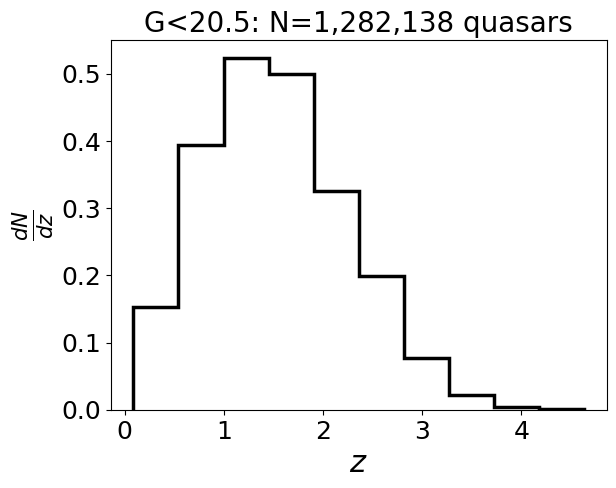

In [31]:
N_gcatlo = len(tab_datahi)
plt.hist(tab_datahi['redshift_quaia'], histtype = 'step', linewidth = 2.5, color = 'black', density = True)
plt.ylabel(r'$\frac{dN}{dz}$')
plt.xlabel('$z$')
plt.title('G<{}: N={:,} quasars'.format(G_hi, N_gcatlo))
plt.show()

In [32]:
# NSIDE = 64
NPIX = hp.nside2npix(NSIDE)
name_catalog = '$Gaia$-$unWISE$ Quasar Catalog'
cmap_map = 'plasma'

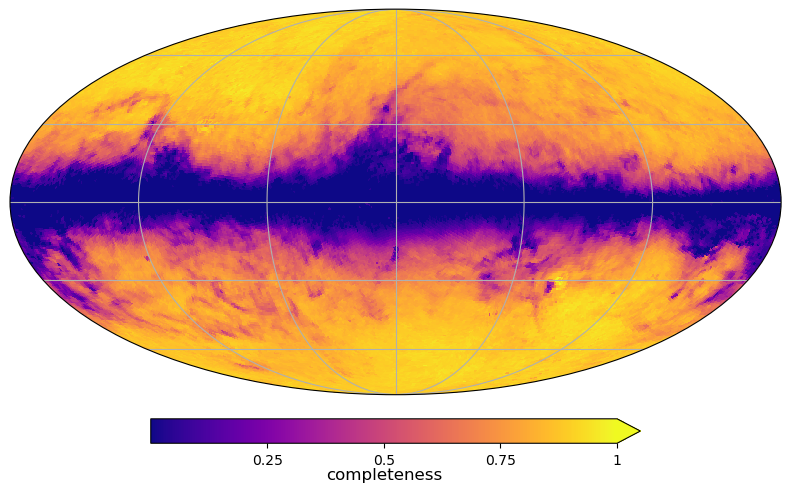

In [33]:
title_gcatlo = rf"{name_catalog}, $G<{G_hi}$ (N={N_gcatlo:,})"
projview(selfunc_datahi, #title='selection function',
            unit=r"completeness", cmap=cmap_map, coord=['C','G'],
            min=0, max = 1, 
            graticule=True, cbar_ticks=[0.25, 0.5, 0.75, 1.0], graticule_labels=False) #True

In [34]:
quaia.absolute(tab_datahi_mask, G_hi)

array([ 2351.99612994, 13397.25003193, 11312.87200823, ...,
       20331.42198124, 12512.68945875,  4349.94408756])

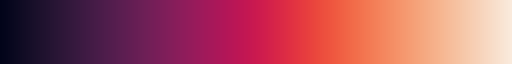

In [35]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

In [36]:
L_array = np.array([-32, -27, -26, -25, -20])[::-1]

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_27189/2952415765.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax2_hi.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_27189/2952415765.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax3_hi.set_xlabel('N$_\mathrm{QSO}$')


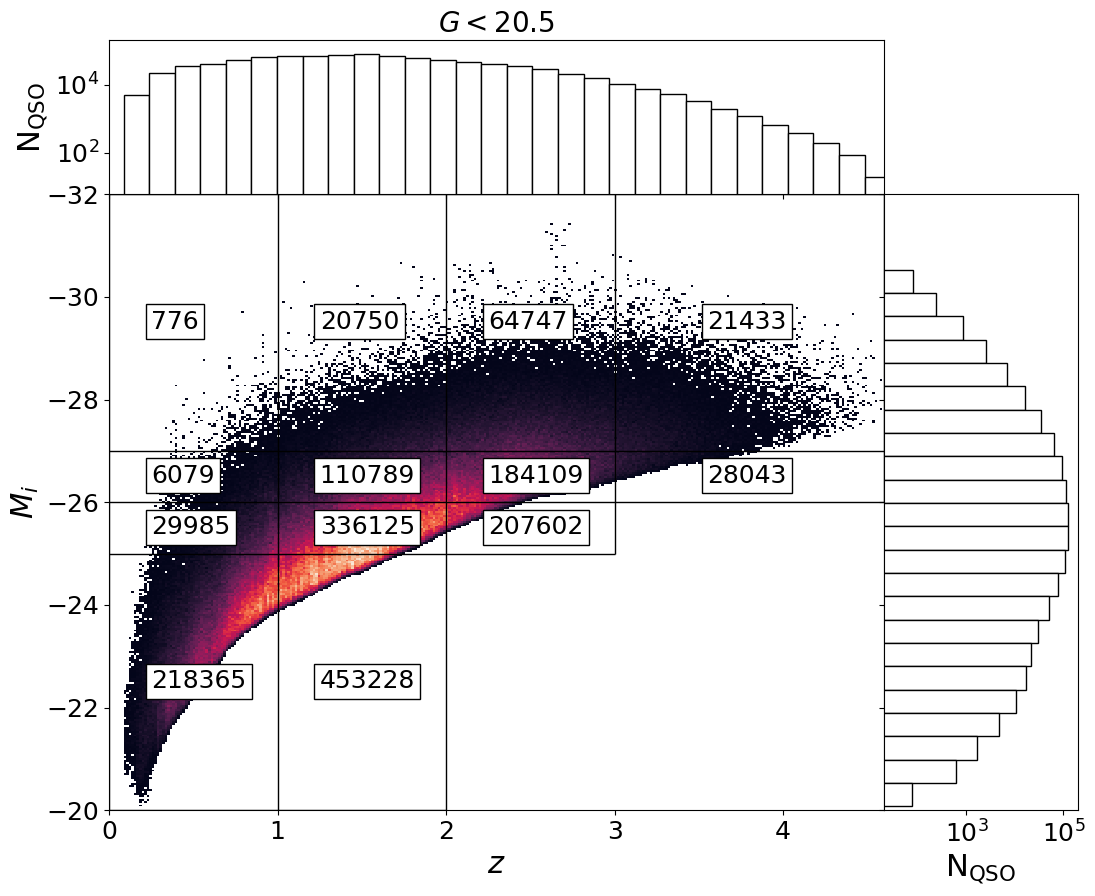

In [37]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1_hi = fig.add_subplot(gs[2])

h1, xedges, yedges, image = ax1_hi.hist2d(tab_datahi_mask['redshift_quaia'], tab_datahi_mask['M_i'], cmap = cmap, bins = 300, 
                                       cmin = 1)

for L_bin, xmax in zip(L_array, [z_bins[2], z_bins[3], z_bins[4], z_bins[4], z_bins[4]]):
    ax1_hi.hlines(L_bin, color = 'black', xmin = z_bins[0], xmax = xmax, linewidth = 1)
for z_bin, ymax in zip(z_bins, [L_bins[0], L_bins[0], L_bins[0], L_bins[1], L_bins[2]]):
    ax1_hi.vlines(z_bin, color = 'black', ymin = -32, ymax = ymax, linewidth = 1)
    
for i in z_array:
    for j in range(len(L_bins)):
        if ((j<3) and (N[L_bins[j]][i]>N[L_bins[j+1]][i])) or (j ==3):
            ax1_hi.text(quaia.recenter(z_bins)[i]-0.25, quaia.recenter(L_array)[j]+0.125, N[L_bins[j]][i], fontsize = 18, color = 'black', bbox=dict(facecolor='white'))
            
ax1_hi.set_ylabel('$M_i$')
xlim = ax1.get_xlim()
ax1_hi.set_xlabel('$z$')
ax1_hi.set_ylim(-20, -32)
ax1_hi.set_xlim(xlim[0], z_bins[-1])

ax2_hi = fig.add_subplot(gs[0])
ax2_hi.hist(tab_datahi_mask['redshift_quaia'], color = 'white', edgecolor = 'black', bins = 30)
ax2_hi.set_title('$G<{}$'.format(G_hi))
ax2_hi.set_ylabel('N$_\mathrm{QSO}$')
ax2_hi.set_yscale('log')
ax2_hi.set_xlim(xlim[0], z_bins[-1])
ax2_hi.set_ylim(6,2e5)
ax2_hi.set_xticklabels([])

ax3_hi = fig.add_subplot(gs[3])
ax3_hi.hist(tab_datahi_mask['M_i'], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3_hi.set_xlabel('N$_\mathrm{QSO}$')
ax3_hi.set_xscale('log')
ax3_hi.set_yticklabels([])
ax3_hi.set_ylim(-20, -32)
ax3_hi.set_xlim(2e1,2e5)

plt.show()

# Implement halo model
## Plot HOD: $\langle N\left(M\right)\rangle=\frac{f_{\text {duty }}}{2} \operatorname{erfc}\left[\frac{\ln (M_\mathrm{min} / M)}{\sqrt{2} \log{10} \Sigma}\right]$
### At fixed $f_{duty}$ and $M_{min}$

In [38]:
bins = np.logspace(9, M_max, n_bins)

### Translate mass definition

In [39]:
dz = np.linspace(0, 4.6)

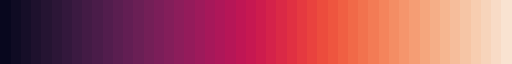

In [40]:
cmap = sns.color_palette("rocket", n_colors = len(dz))
palette = matplotlib.colors.ListedColormap(cmap)
palette

In [41]:
c_m = ccl.halos.concentration.diemer15.ConcentrationDiemer15()

/tmp/ipykernel_27189/2696947960.py:17: RuntimeWarning: invalid value encountered in divide
  plt.plot(bins, np.abs(nM_200m/nM_200c-1), linewidth = 2.5, color = cmap[i])


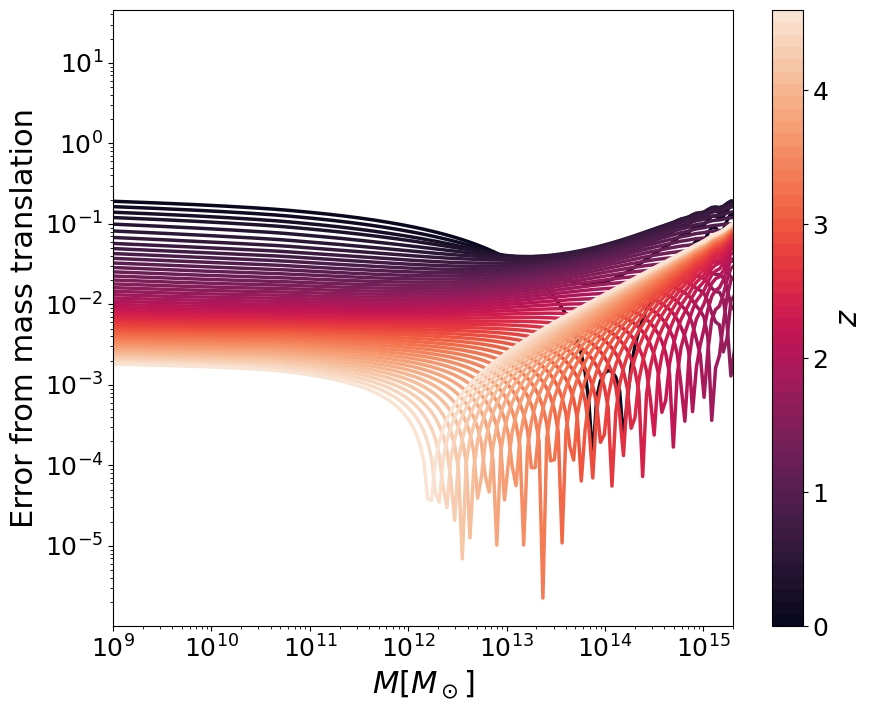

In [42]:
# # Let's define a mass function object for Delta = 200 (critical)
# Now let's compare the mass function parametrized for 200 (matter)
# with the mass function parametrized for 200 (critical) but
# translated to 200 (matter)
mass_trans_200c_to_200m = ccl.halos.mass_translator(mass_in=ccl.halos.MassDef200c, mass_out=ccl.halos.MassDef200m, 
                                       concentration=c_m)

fig = plt.figure(figsize = (10, 8))
for i,z in enumerate(dz):

    a = 1/(1+z)
    bins_200m = mass_trans_200c_to_200m(cosmo_planck18, bins, a)

    nM_200c = hmf['200c'](cosmo_planck18, bins, a)
    nM_200m = hmf['200m'](cosmo_planck18, bins_200m, a)
    
    plt.plot(bins, np.abs(nM_200m/nM_200c-1), linewidth = 2.5, color = cmap[i])
    
plt.xscale('log')
plt.xlabel(r'$M [M_\odot]$')
plt.ylabel('Error from mass translation')
plt.yscale('log')
plt.xlim(1e9, 2e15)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.Normalize(vmin=0, vmax = 4.6)), ax = plt.gca(),
                label = '$z$')
plt.show()

/tmp/ipykernel_27189/902407972.py:10: RuntimeWarning: invalid value encountered in divide
  plt.plot(bins_200m, nM_200c/nM_200m-1, linewidth = 2.5, color = cmap[i])


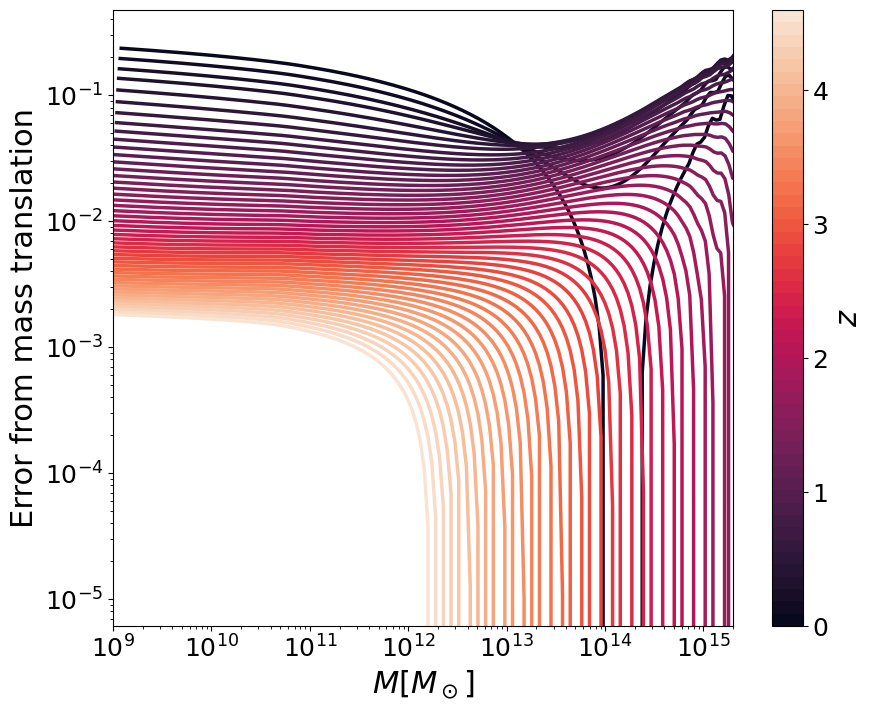

In [43]:
fig = plt.figure(figsize = (10, 8))
for i,z in enumerate(dz):

    a = 1/(1+z)
    bins_200m = mass_trans_200c_to_200m(cosmo_planck18, bins, a)

    nM_200c = hmf['200c'](cosmo_planck18, bins, a)
    nM_200m = hmf['200m'](cosmo_planck18, bins_200m, a)
    
    plt.plot(bins_200m, nM_200c/nM_200m-1, linewidth = 2.5, color = cmap[i])
    
plt.xscale('log')
plt.xlabel(r'$M [M_\odot]$')
plt.ylabel('Error from mass translation')
plt.yscale('log')
plt.xlim(1e9, 2e15)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.Normalize(vmin=0, vmax = 4.6)), ax = plt.gca(),
                label = '$z$')
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/2470489207.py:11: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


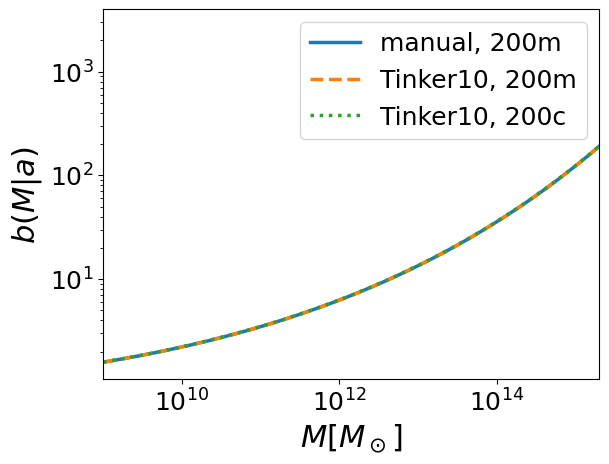

In [44]:
b_h_tinker10_200m = b1_E_func(bins, a = a, method = 'pyccl', b1_E_func_tinker10 = b1_E_func_tinker10['200m'])
b_h = b1_E_func(bins, a = a, method = 'manual')

plt.plot(bins_200m, b_h, linewidth = 2.5, label = 'manual, 200m')
plt.plot(bins_200m, b_h_tinker10_200m, linewidth = 2.5, linestyle = '--', label = 'Tinker10, 200m')

b_h_tinker10_200c = b1_E_func(bins, a = a, method = 'pyccl', b1_E_func_tinker10 = b1_E_func_tinker10['200c'])
plt.plot(bins, b_h_tinker10_200c, linewidth = 2.5, linestyle = ':', label = 'Tinker10, 200c')

plt.ylabel('$b(M|a)$')
plt.xlabel('$M [M_\odot]$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e9, 2e15)
plt.legend()
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/2027246863.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


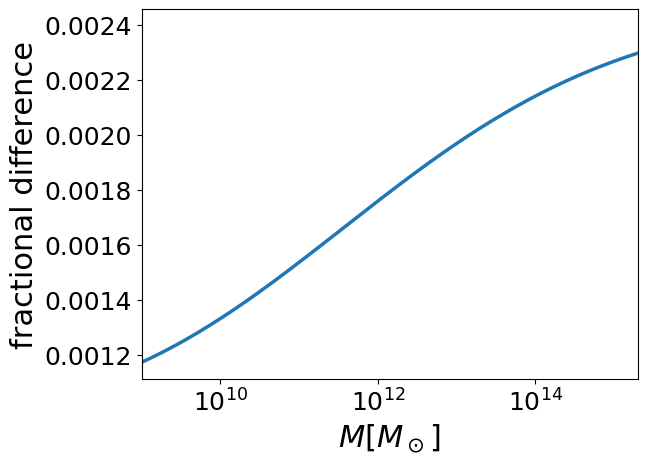

In [45]:
plt.plot(bins_200m, b_h_tinker10_200c/b_h_tinker10_200m - 1, linewidth = 2.5)
plt.xscale('log')
plt.ylabel('fractional difference')
plt.xlabel('$M [M_\odot]$')
plt.xlim(1e9, 2e15)
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/696865994.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


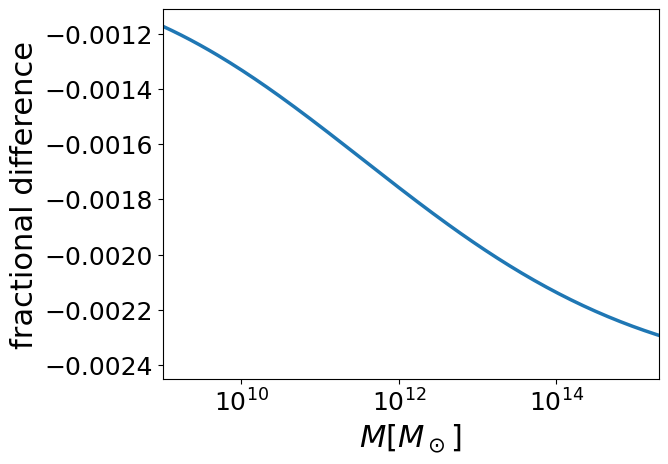

In [46]:
plt.plot(bins, b_h_tinker10_200m/b_h_tinker10_200c - 1, linewidth = 2.5)
plt.xscale('log')
plt.ylabel('fractional difference')
plt.xlabel('$M [M_\odot]$')
plt.xlim(1e9, 2e15)
plt.show()

In [47]:
b1 = bias(bins_200m, np.ones(np.shape(bins_200m)), recenter = 'False')[0]
print(b1)

b1_200m = bias(bins_200m, np.ones(np.shape(bins)), recenter = 'False', method = 'pyccl')[0]
print(b1_200m)

b1_200c = bias(bins, np.ones(np.shape(bins)), recenter = 'False', method = 'pyccl', b1_E_func_tinker10 = b1_E_func_tinker10['200c'])[0]
print(b1_200c)

0.7032796026037778
0.7032796026037778
0.7032462179809505


In [48]:
M_min_array = [11.94, 11.98, 11.97, 12.07]

In [49]:
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))

In [50]:
fduty = [0.002, 0.002, 0.003, 0.002]

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\S'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_27189/513207219.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(bins_i, n_m, linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_blue[i])
/tmp/ipykernel_27189/513207219.py:31: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel('$M (M_\odot)$')
/tmp/ipykernel_27189/513207219.py:38: SyntaxWarning: invalid escape sequence '\S'
  ax1.set_title('$\Sigma={}$ dex'.format(sigma_array[j]))
/tmp/ipykernel_27189/1712182293.py:3: RuntimeWarning: divide by zero encountered in divide
  return fduty/2*special.erfc(np.log(10**M_min/bins)/(np.sqrt(2)*np.log(10)*sigma))
/tmp/ipykernel_27189/1712182293.py:3: RuntimeWarning: invalid value en

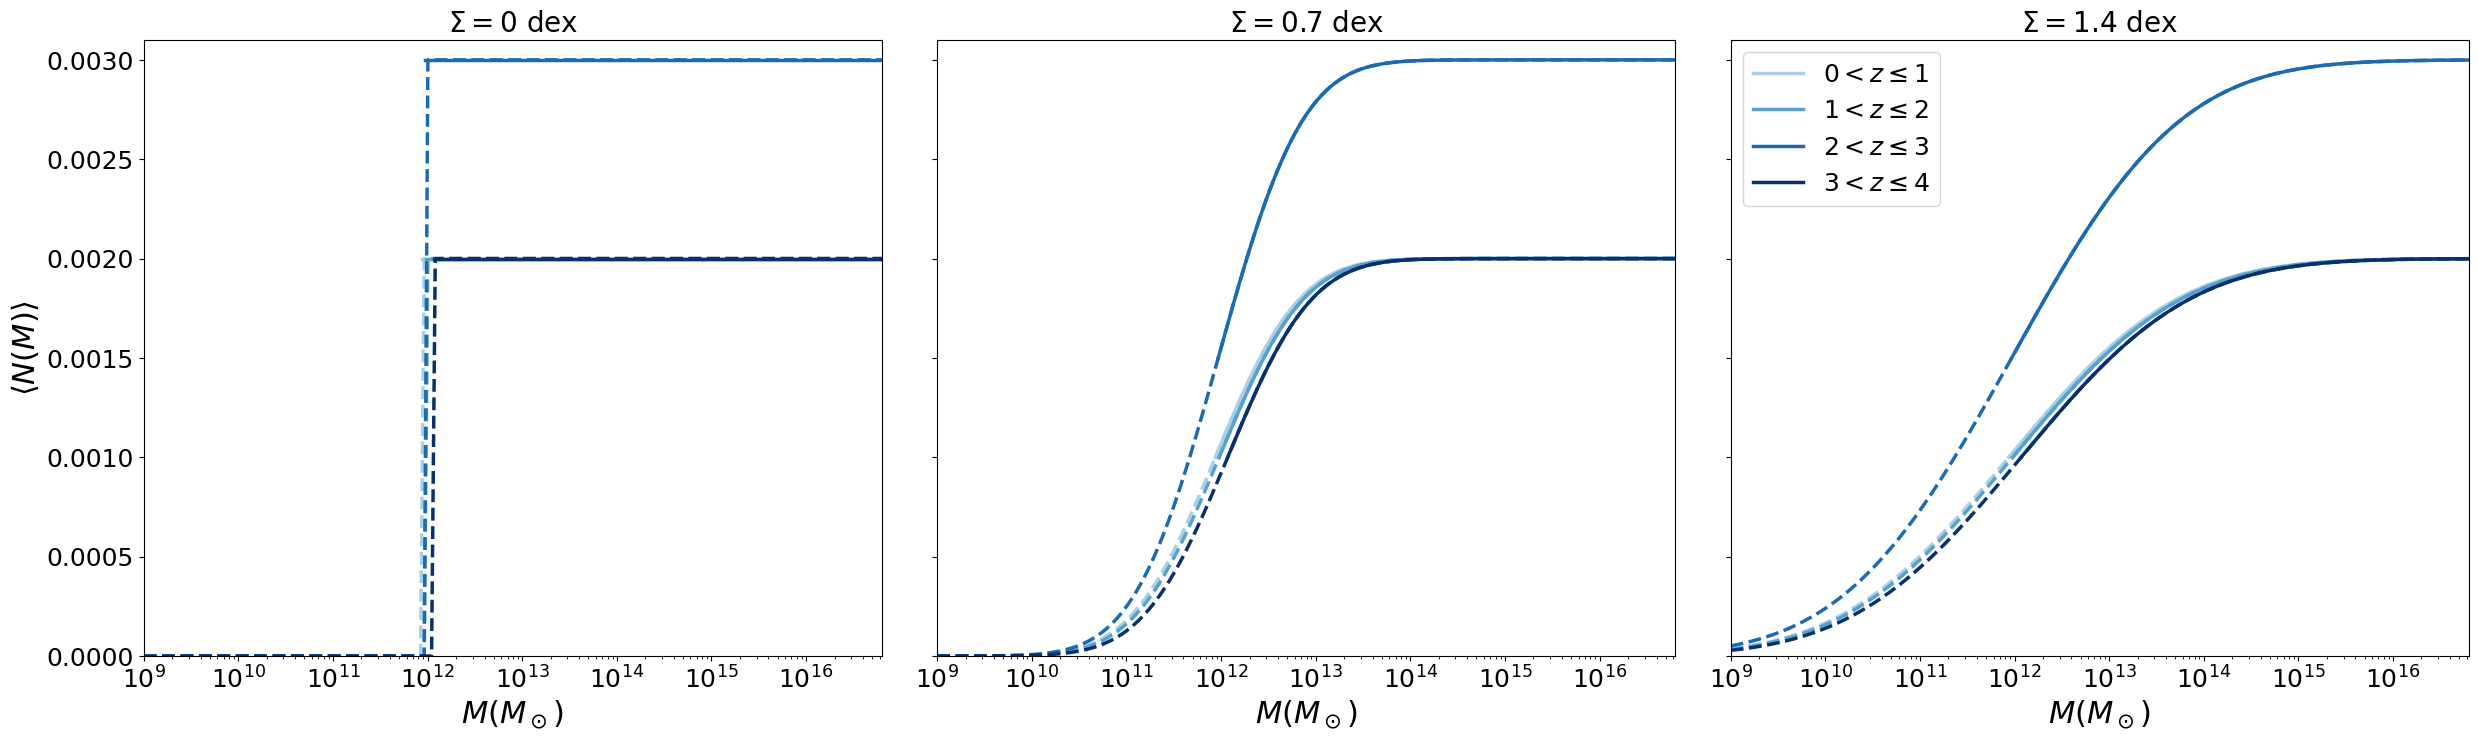

In [51]:
fig = plt.figure(figsize = (30, 8))
gs = gridspec.GridSpec(1, 3, wspace = 0.075)
sigma_array = [0, 0.7, 1.4]
n_m_array, bins_M_min = [], []

for j in range(len(sigma_array)):
    
    ax1 = fig.add_subplot(gs[j])
        
    for i in z_array:
        
        bins_i = np.logspace(M_min_array[i], M_max, n_bins)

        n_m = N_c(bins_i, M_min_array[i], fduty[i], sigma = sigma_array[j])

        ax1.plot(bins_i, n_m, linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_blue[i])

        # bins_i = np.sort(np.append(bins, 10**M_min_array[i]))
        # n_m = HOD_scatter(fduty[i], M_min_array[i], bins_i, sigma_array[j])
        # n_m[bins_i==10**M_min_array[i]]=fduty[i]/2
        n_m = N_c(bins, M_min_array[i], fduty[i], sigma = sigma_array[j])

        ax1.plot(bins, n_m, linewidth = 2.5, linestyle ='--', color = cmap_blue[i])

        if j == 0:
            
            n_m_array.append(n_m)
            bins_M_min.append(bins_i)
    
    ax1.set_xscale('log')
    ax1.set_xlabel('$M (M_\odot)$')
    
    if j== 0:
        ax1.set_ylabel(r'$\langle N(M) \rangle$')
    else:
        ax1.set_yticklabels([])
    
    ax1.set_title('$\Sigma={}$ dex'.format(sigma_array[j]))
    ax1.set_xlim(1e9,10**M_max)
    ax1.set_ylim(0, 0.0031)
    
    print()
    
ax1.legend()
plt.show()

In [52]:
Sigma = 0.4

In [53]:
n_c = []
for i in z_array:        
    n_m = N_c(quaia.recenter(bins), M_min_array[i], fduty[i], sigma = Sigma)
    n_c.append(n_m)

## Step-function HOD: $\langle N_c(M) \rangle = \Theta\left(M-M_{min}\right)f_{duty} = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$

In [54]:
n_c_step = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_c_step.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/1466996065.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_c_step[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_27189/1466996065.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


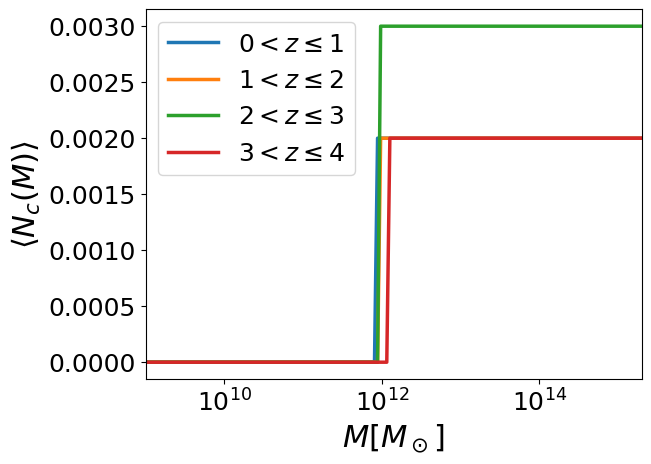

In [55]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_c_step[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M [M_\odot]$')
plt.ylabel(r'$\langle N_c(M) \rangle$')
plt.xlim(1e9, 2e15)
plt.legend()
plt.show()

In [56]:
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, n_bins)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [57]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

# Add satellites
## Option 1: $\left\langle N_s(M)\right\rangle=f_{duty}\left(\frac{M}{M_1}\right)^\alpha$

In [152]:
def N_s(bins_m, fduty, M0, M1, alpha, exp = False, step = True): #bins_m

    if exp == False:

        n_m = fduty*((bins_m-M0)/M1)**alpha
        
        if step == True:
            n_m[bins_m<M0]=0
            
    else:

        n_m = N_s_exp(bins_m, M1, alpha, M0, fduty)

    return n_m

In [153]:
def N_s_exp(M, M1, alpha, Mcut, fduty):

    return fduty*(M/M1)**alpha*np.exp(-Mcut/M)

In [154]:
n_s_1 = []
for i in range(len(M_min_array)):
    n_s_1.append(N_s(quaia.recenter(bins), fduty[i], 0, 12*10**M_min_array[i], 0.9, step = False))

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/1101186836.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_s_1[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_27189/1101186836.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


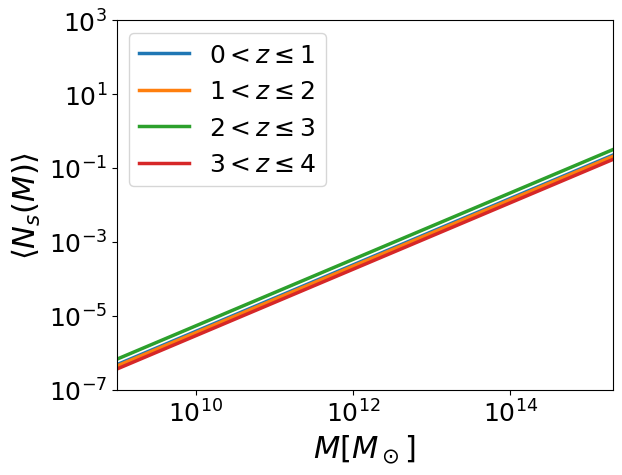

In [155]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_s_1[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M [M_\odot]$')
plt.ylabel(r'$\langle N_s(M) \rangle$')
plt.legend()
plt.yscale('log')
plt.ylim(1e-7, 1e3)
plt.xlim(1e9, 2e15)
plt.show()

## Option 2: $\left\langle N_s(M)\right\rangle=f_{duty}\Theta\left(M-M_0\right)\left(\frac{M-M_0}{M_1}\right)^\alpha$

In [156]:
n_s = []
for i in range(len(M_min_array)):

    n_s.append(N_s(quaia.recenter(bins), fduty[i], 10**M_min_array[i], 12*10**M_min_array[i], 0.9))

/tmp/ipykernel_27189/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/3002737524.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_s[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_27189/3002737524.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


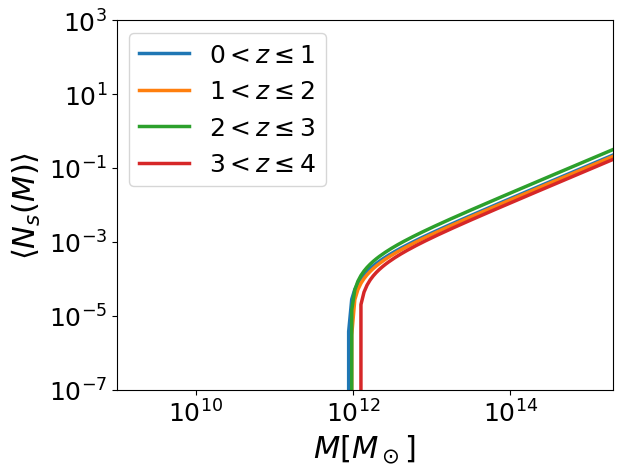

In [157]:
for i in z_array:

    plt.plot(quaia.recenter(bins), n_s[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
    
plt.xscale('log')
plt.xlabel('$M [M_\odot]$')
plt.ylabel(r'$\langle N_s(M) \rangle$')
plt.legend()
plt.yscale('log')
plt.xlim(1e9, 2e15)
plt.ylim(1e-7, 1e3)
plt.show()

## Option 3: $\left\langle N_{\mathrm{s}}\right\rangle=f_{duty}\left(\frac{M}{M_1}\right)^\alpha \exp \left(\frac{-M_{\mathrm{cut}}}{M}\right)$

In [158]:
n_s_exp = []
for i in range(len(M_min_array)):

    n_s_exp.append(N_s(quaia.recenter(bins), fduty[i], 10**M_min_array[i], 12*10**M_min_array[i], 0.9, exp = True))

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/1727180482.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_s_exp[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_27189/1727180482.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


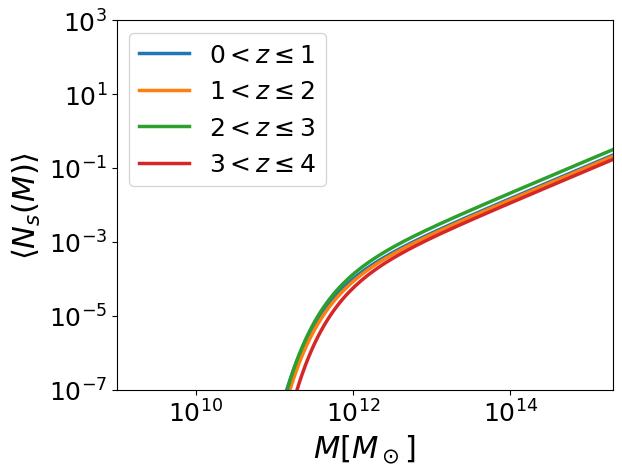

In [159]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_s_exp[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M [M_\odot]$')
plt.ylabel(r'$\langle N_s(M) \rangle$')
plt.legend()
plt.yscale('log')
plt.xlim(1e9, 2e15)
plt.ylim(1e-7, 1e3)
plt.show()

## Define the total occupation
### $\langle N(M) \rangle = \langle N_c(M) \rangle +\langle N_s(M) \rangle$

In [160]:
cmap_theta = sns.color_palette("flare_r", n_colors = len(L_bins))
cmap_theta

[(0.47936222, 0.18006056, 0.43733022),
 (0.66635279, 0.22717328, 0.43008427),
 (0.83765537, 0.30784814, 0.3723105),
 (0.90732341, 0.4939774, 0.38990532)]

<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/2232022962.py:10: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


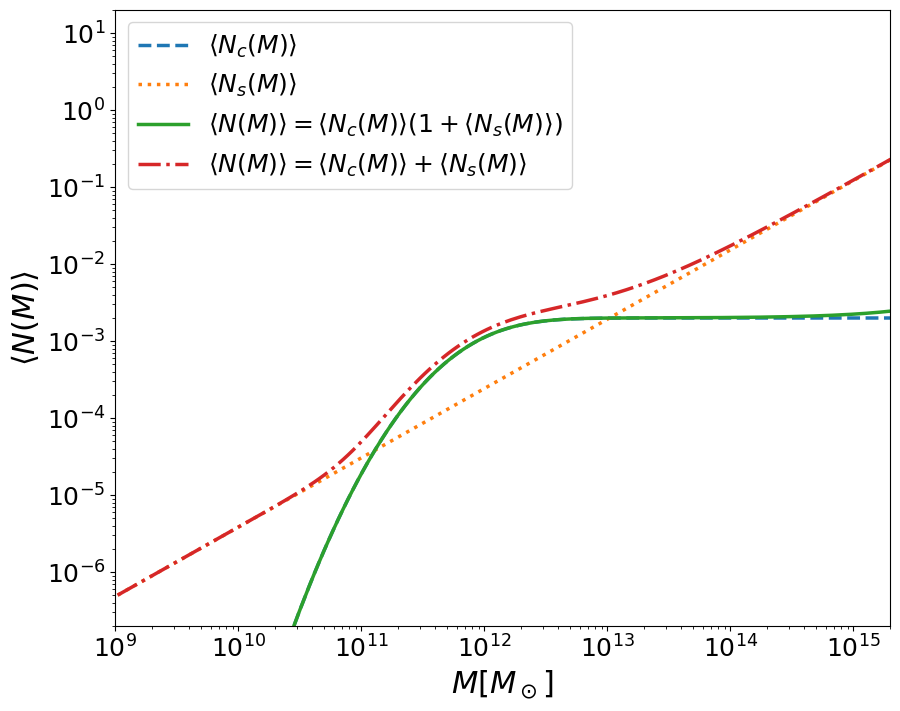

In [161]:
fig = plt.figure(figsize = (10, 8))
i = 0
        
plt.plot(quaia.recenter(bins), n_c[i], linewidth = 2.5, linestyle = '--', label = r'$\langle N_c(M) \rangle$') #color = cmap_theta[i], 
plt.plot(quaia.recenter(bins), n_s_1[i], linewidth = 2.5, linestyle = ':', label = r'$\langle N_s(M) \rangle$')
plt.plot(quaia.recenter(bins), n_c[i]*(1+n_s_1[i]), linewidth = 2.5, label = r'$\langle N(M) \rangle = \langle N_c(M) \rangle (1+\langle N_s(M) \rangle)$') #label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), 
plt.plot(quaia.recenter(bins), n_c[i]+n_s_1[i], linewidth = 2.5, linestyle = '-.', label = r'$\langle N(M) \rangle = \langle N_c(M) \rangle +\langle N_s(M) \rangle$')

plt.xscale('log')
plt.xlabel('$M [M_\odot]$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.yscale('log')
plt.ylim(2e-7, 2e1)
plt.legend()
plt.xlim(1e9, 2e15)

plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/1917564411.py:9: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


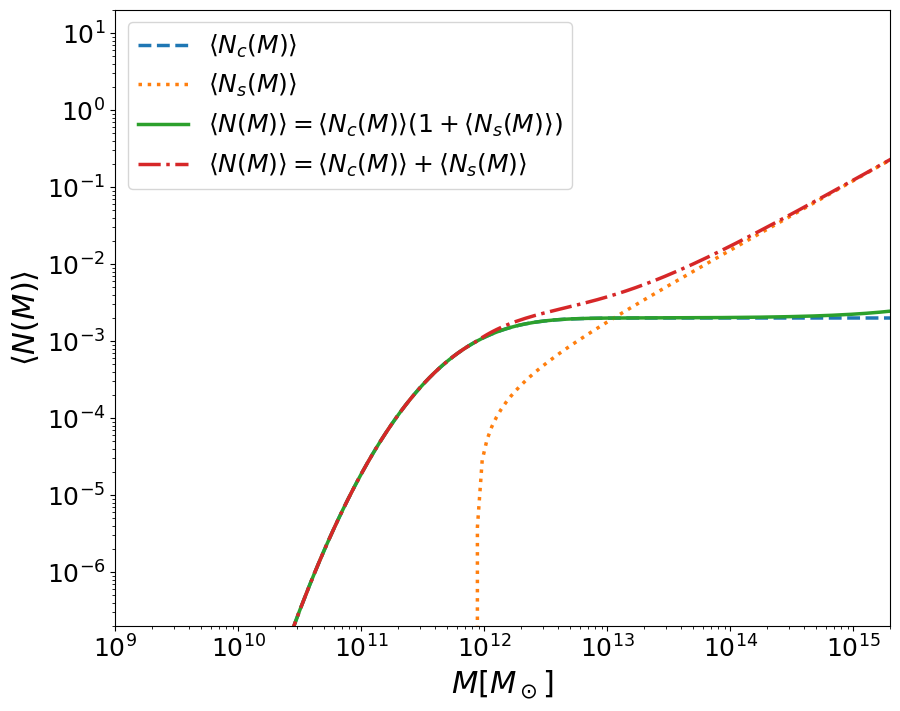

In [162]:
fig = plt.figure(figsize = (10, 8))

plt.plot(quaia.recenter(bins), n_c[i], linewidth = 2.5, linestyle = '--', label = r'$\langle N_c(M) \rangle$') #color = cmap_theta[i], 
plt.plot(quaia.recenter(bins), n_s[i], linewidth = 2.5, linestyle = ':', label = r'$\langle N_s(M) \rangle$')
plt.plot(quaia.recenter(bins), n_c[i]*(1+n_s[i]), linewidth = 2.5, label = r'$\langle N(M) \rangle = \langle N_c(M) \rangle (1+\langle N_s(M) \rangle)$') #label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), 
plt.plot(quaia.recenter(bins), n_c[i]+n_s[i], linewidth = 2.5, linestyle = '-.', label = r'$\langle N(M) \rangle = \langle N_c(M) \rangle +\langle N_s(M) \rangle$')

plt.xscale('log')
plt.xlabel('$M [M_\odot]$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.yscale('log')
plt.xlim(1e9, 2e15)
plt.ylim(2e-7, 2e1)

plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/3456805486.py:9: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')


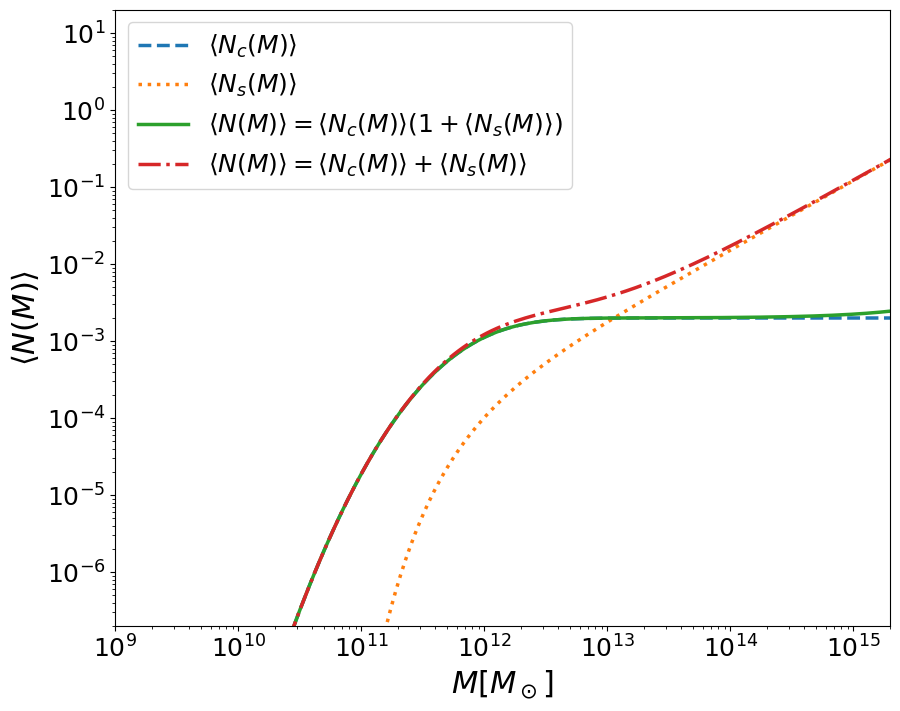

In [163]:
fig = plt.figure(figsize = (10, 8))

plt.plot(quaia.recenter(bins), n_c[i], linewidth = 2.5, linestyle = '--', label = r'$\langle N_c(M) \rangle$') #color = cmap_theta[i], 
plt.plot(quaia.recenter(bins), n_s_exp[i], linewidth = 2.5, linestyle = ':', label = r'$\langle N_s(M) \rangle$')
plt.plot(quaia.recenter(bins), n_c[i]*(1+n_s_exp[i]), linewidth = 2.5, label = r'$\langle N(M) \rangle = \langle N_c(M) \rangle (1+\langle N_s(M) \rangle)$') #label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), 
plt.plot(quaia.recenter(bins), n_c[i]+n_s_exp[i], linewidth = 2.5, linestyle = '-.', label = r'$\langle N(M) \rangle = \langle N_c(M) \rangle +\langle N_s(M) \rangle$')

plt.xscale('log')
plt.xlabel('$M [M_\odot]$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.yscale('log')
plt.xlim(1e9, 2e15)
plt.ylim(2e-7, 2e1)
plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [164]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, n_bins) for j in range(len(bins))]

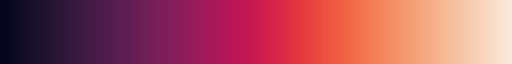

In [165]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [166]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [167]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [168]:
tab_datahi_mask_zbins, selfunc_hi_bins = {L: [] for L in L_bins}, {L: [] for L in L_bins}

for i in range(len(L_bins)):
            
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                         bins = [z_bins, L_bins], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                          n_bins = [None, None], b = b, mask_type = 'b')
        tab_datahi_mask_zbins[L_bins[i]].append(tab_datahi_mask_zbin0['redshift_quaia'])
        selfunc_hi_bins[L_bins[i]].append(selfunc_hi_bin0)

Pixels masked by MC but not already by selfunc: 2468
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.33              218365 vs 324336
Pixels masked by MC but not already by selfunc: 4785
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.30              453228 vs 648196
Pixels masked by MC but not already by selfunc: 2764
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.28              207602 vs 286508
Pixels masked by MC but not already by selfunc: 307
G20.5_zmin3.0zmax4.6_Lmax-20.0: 0.23              28043 vs 36458
Pixels masked by MC but not already by selfunc: 490
G20.5_zmin0.0zmax1.0_Lmax-25.0: 0.46              29985 vs 55261
Pixels masked by MC but not already by selfunc: 3840
G20.5_zmin1.0zmax2.0_Lmax-25.0: 0.33              336125 vs 502242
Pixels masked by MC but not already by selfunc: 2764
G20.5_zmin2.0zmax3.0_Lmax-25.0: 0.28              207602 vs 286508
Pixels masked by MC but not already by selfunc: 307
G20.5_zmin3.0zmax4.6_Lmax-25.0: 0.23              28043 vs 36458
Pixels masked by MC but not already by selfunc: 1

In [169]:
for i in range(len(L_bins)):
            
    for j in z_array:

        print([int(z_bins[j]), np.abs(int(L_bins[i]))])

[0, 20]
[1, 20]
[2, 20]
[3, 20]
[0, 25]
[1, 25]
[2, 25]
[3, 25]
[0, 26]
[1, 26]
[2, 26]
[3, 26]
[0, 27]
[1, 27]
[2, 27]
[3, 27]


In [172]:
np.random.default_rng([int(z_bins[0]), int(z_bins[1]), np.abs(int(L_bins[0]))])

Generator(PCG64) at 0x7FA88D1B2EA0

In [173]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud

In [174]:
LMC_radius = 9*u.deg

In [175]:
SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud

In [176]:
SMC_radius = 5*u.deg

In [177]:
NPIX = hp.nside2npix(NSIDE)

In [178]:
theta, phi = hp.pix2ang(NSIDE, range(NPIX), lonlat=True)
c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
MC_idx = np.append(LMC_idx,SMC_idx)
MC_mask = np.full_like(range(NPIX), True, dtype = bool)
MC_mask[MC_idx] = False

In [179]:
selfunc_mask = np.abs(c.galactic.b.value)>=b

In [180]:
n_q, n_q_err, V_eff, N_q = {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}

for i in range(len(L_bins)):
            
    for j in z_array:   

        N = len(tab_datahi_mask_zbins[L_bins[i]][j])
        f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[L_bins[i]][j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
        V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
        N_q[L_bins[i]].append(N)
        n_q[L_bins[i]].append(N/V.value)
        n_q_err[L_bins[i]].append(np.sqrt(N)/V.value) # Poisson error
        V_eff[L_bins[i]].append(V)
        print(np.sqrt(N)/N*100)
        
n_q_err, N/V

0.21399739416959668
0.14853938923101784
0.2194745834562775
0.5971559501134015
0.5774946609060736
0.17248430868424924
0.2194745834562775
0.5971559501134015
1.2825784196427568
0.3004357977625259
0.23305718175637785
0.5971559501134015
3.58979079308869
0.6942101345006233
0.3929978502486891
0.6830594718982789


({-20.0: [2.306551403404182e-08,
   1.208077202021923e-08,
   6.8836698683460285e-09,
   1.6257950737213308e-09],
  -25.0: [1.2163780573680231e-08,
   1.0235703557927114e-08,
   6.8836698683460285e-09,
   1.6257950737213308e-09],
  -26.0: [5.315303569404201e-09,
   8.222287402598444e-09,
   6.159309194526849e-09,
   1.6257950737213308e-09],
  -27.0: [1.9549622374672744e-09,
   4.239757610474862e-09,
   3.949929691972451e-09,
   1.272591786871808e-09]},
 <Quantity 1.86307611e-07 h3 / Mpc3>)

In [181]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [182]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf[mass_def], cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Calculate extent of Limber approximation

In [183]:
def theta_break(slope, sigma, rm):

    return 2*np.sqrt(3)/np.sqrt(np.pi)*gamma(slope/2)/gamma(slope/2-1/2)*sigma/rm*u.rad

In [184]:
slope = [1.89, 1.89, 1.89, 2.13]

In [185]:
for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))

    for j in z_array:

        print('{:.1f}<z<={:.1f}\n'.format(z_bins[j], z_bins[j+1]))
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(
            G_hi, [j, i], True, ['z', 'L'], bins = [z_bins, L_bins], tab_gcat_type = 'data', method = ['minmax', 'max'], fac_rand = fac_rand, 
            n_bins = [None, None], b = b, mask_type = 'b', verbose = False)

        z = np.mean(tab_datahi_mask_zbin0['redshift_quaia'])
        rm = quaia.comoving_dist(z)
        sigma = quaia.comoving_dist(z+np.mean(tab_datahi_mask_zbin0['redshift_quaia_err']))-rm
        theta = theta_break(slope[j], sigma, rm)
        
        print('sigma/rm      : {:.2f}'.format(sigma/rm))
        print('10% error     : {:.2f}'.format(260*sigma/rm*u.arcmin))
        print('10% error     : {:.2f}'.format((260*sigma/rm*u.arcmin).to(u.deg)))
        print('theta_break   : {:.2f}'.format(theta))
        print('theta_break/10: {:.2f}\n'.format(theta.to(u.deg)))

M_i<=-20.0
0.0<z<=1.0

sigma/rm      : 0.14
10% error     : 35.15 arcmin
10% error     : 0.59 deg
theta_break   : 0.14 rad
theta_break/10: 7.87 deg

1.0<z<=2.0

sigma/rm      : 0.07
10% error     : 18.83 arcmin
10% error     : 0.31 deg
theta_break   : 0.07 rad
theta_break/10: 4.22 deg

2.0<z<=3.0

sigma/rm      : 0.04
10% error     : 10.30 arcmin
10% error     : 0.17 deg
theta_break   : 0.04 rad
theta_break/10: 2.31 deg

3.0<z<=4.6

sigma/rm      : 0.02
10% error     : 5.79 arcmin
10% error     : 0.10 deg
theta_break   : 0.03 rad
theta_break/10: 1.53 deg

M_i<=-25.0
0.0<z<=1.0

sigma/rm      : 0.10
10% error     : 25.89 arcmin
10% error     : 0.43 deg
theta_break   : 0.10 rad
theta_break/10: 5.80 deg

1.0<z<=2.0

sigma/rm      : 0.06
10% error     : 16.08 arcmin
10% error     : 0.27 deg
theta_break   : 0.06 rad
theta_break/10: 3.60 deg

2.0<z<=3.0

sigma/rm      : 0.04
10% error     : 10.30 arcmin
10% error     : 0.17 deg
theta_break   : 0.04 rad
theta_break/10: 2.31 deg

3.0<z<=4.6

s

In [186]:
Mvir = 1e13*u.Msun

for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))

    for j in z_array:

        print('{:.1f}<z<={:.1f}\n'.format(z_bins[j], z_bins[j+1]))
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(
            G_hi, [j, i], True, ['z', 'L'], bins = [z_bins, L_bins], tab_gcat_type = 'data', method = ['minmax', 'max'], fac_rand = fac_rand, 
            n_bins = [None, None], b = b, mask_type = 'b', verbose = False)

        z = np.mean(tab_datahi_mask_zbin0['redshift_quaia'])
        Rvir = ((Mvir*3/4/np.pi/200/Planck18.critical_density(z))**(1/3)).to(u.Mpc)
        theta = Rvir*(1+z)/quaia.comoving_dist(z, units = 'Mpc')*u.rad

        print('Rvir      : {:.2f}'.format(Rvir))
        print('theta     : {:.2e}'.format(theta))
        print('theta     : {:.2e}'.format(theta.to(u.deg)))
        print('theta     : {:.2e}\n'.format(theta.to(u.arcmin)))

M_i<=-20.0
0.0<z<=1.0

Rvir      : 0.35 Mpc
theta     : 2.33e-04 rad
theta     : 1.34e-02 deg
theta     : 8.01e-01 arcmin

1.0<z<=2.0

Rvir      : 0.26 Mpc
theta     : 1.44e-04 rad
theta     : 8.26e-03 deg
theta     : 4.95e-01 arcmin

2.0<z<=3.0

Rvir      : 0.19 Mpc
theta     : 1.13e-04 rad
theta     : 6.46e-03 deg
theta     : 3.88e-01 arcmin

3.0<z<=4.6

Rvir      : 0.15 Mpc
theta     : 9.78e-05 rad
theta     : 5.61e-03 deg
theta     : 3.36e-01 arcmin

M_i<=-25.0
0.0<z<=1.0

Rvir      : 0.33 Mpc
theta     : 2.04e-04 rad
theta     : 1.17e-02 deg
theta     : 7.02e-01 arcmin

1.0<z<=2.0

Rvir      : 0.25 Mpc
theta     : 1.40e-04 rad
theta     : 8.01e-03 deg
theta     : 4.81e-01 arcmin

2.0<z<=3.0

Rvir      : 0.19 Mpc
theta     : 1.13e-04 rad
theta     : 6.46e-03 deg
theta     : 3.88e-01 arcmin

3.0<z<=4.6

Rvir      : 0.15 Mpc
theta     : 9.78e-05 rad
theta     : 5.61e-03 deg
theta     : 3.36e-01 arcmin

M_i<=-26.0
0.0<z<=1.0

Rvir      : 0.33 Mpc
theta     : 2.04e-04 rad
theta     : 1

## Calculate min scale
[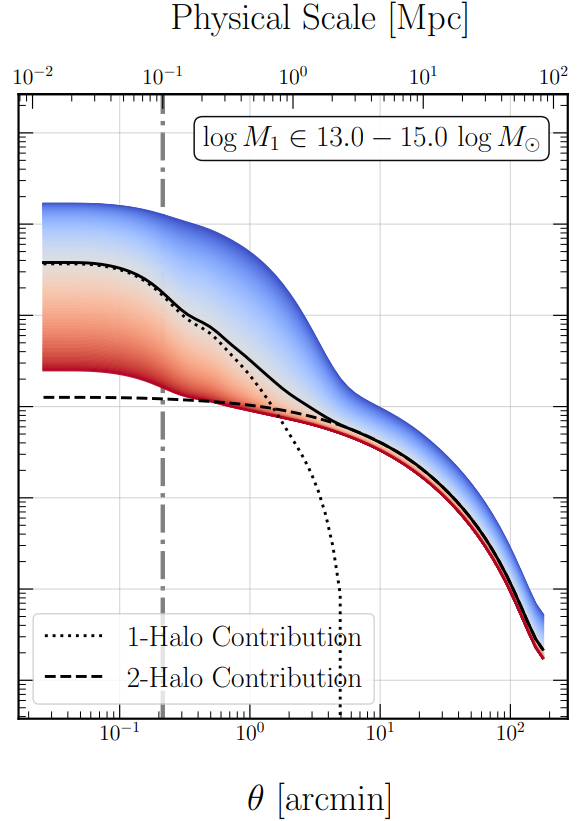](https://arxiv.org/abs/2510.11780)

In [187]:
np.log10((2e-1*u.arcmin).to(u.deg).value), np.log10(1e-2)

(-2.4771212547196626, -2.0)

In [188]:
(2e2*u.arcmin).to(u.deg)

<Quantity 3.33333333 deg>

## Limit angular scales to $0.001^\circ\geq \theta \geq 10^\circ$

In [189]:
# Create the bins array
rmin = 0.001
rmax = 10.0
nbins = 30 #20 #30 #20
thetabins = np.logspace(np.log10(rmin), np.log10(rmax), nbins+1)
np.log10(thetabins), quaia.recenter(np.log10(thetabins)), np.diff(np.log10(thetabins))

(array([-3.        , -2.86666667, -2.73333333, -2.6       , -2.46666667,
        -2.33333333, -2.2       , -2.06666667, -1.93333333, -1.8       ,
        -1.66666667, -1.53333333, -1.4       , -1.26666667, -1.13333333,
        -1.        , -0.86666667, -0.73333333, -0.6       , -0.46666667,
        -0.33333333, -0.2       , -0.06666667,  0.06666667,  0.2       ,
         0.33333333,  0.46666667,  0.6       ,  0.73333333,  0.86666667,
         1.        ]),
 array([-2.93333333e+00, -2.80000000e+00, -2.66666667e+00, -2.53333333e+00,
        -2.40000000e+00, -2.26666667e+00, -2.13333333e+00, -2.00000000e+00,
        -1.86666667e+00, -1.73333333e+00, -1.60000000e+00, -1.46666667e+00,
        -1.33333333e+00, -1.20000000e+00, -1.06666667e+00, -9.33333333e-01,
        -8.00000000e-01, -6.66666667e-01, -5.33333333e-01, -4.00000000e-01,
        -2.66666667e-01, -1.33333333e-01, -2.42861287e-16,  1.33333333e-01,
         2.66666667e-01,  4.00000000e-01,  5.33333333e-01,  6.66666667e-01,
       

In [190]:
pimax = 80 # 40 # 5000.0 # 40.0\

In [191]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

## Pick cosmology

In [192]:
cosmo = 'Planck'

In [193]:
N = 50 #20 #65 #50 #30 #15 #80

In [194]:
wp_chi2, wp_matter_chi2, rpavg_chi2 = {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}
a_zbin, b_wp_q = {L: [] for L in L_bins}, {L: [] for L in L_bins}
for i in range(len(L_bins)):
            
    for j in z_array:                                                               

        wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
        a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))
      
        wp_chi2[L_bins[i]].append(wp_zbin_i)

        # scale factor
        a_zbin[L_bins[i]].append(a)

In [195]:
log_thetamin = -2 #-1
log_thetamax = 0
theta_mask=(quaia.recenter(np.log10(thetabins))>=log_thetamin) & (quaia.recenter(np.log10(thetabins))<=log_thetamax)
np.log10(quaia.recenter(thetabins)[theta_mask])

array([-1.99490311, -1.86156978, -1.72823645, -1.59490311, -1.46156978,
       -1.32823645, -1.19490311, -1.06156978, -0.92823645, -0.79490311,
       -0.66156978, -0.52823645, -0.39490311, -0.26156978, -0.12823645,
        0.00509689])

In [196]:
offset = 0.3

In [197]:
delta_xlim = np.diff(np.log10(thetabins))[0]/2
delta_xlim/2, thetabins, 10**(np.log10(thetabins) - 2*delta_xlim)

(0.033333333333333326,
 array([1.00000000e-03, 1.35935639e-03, 1.84784980e-03, 2.51188643e-03,
        3.41454887e-03, 4.64158883e-03, 6.30957344e-03, 8.57695899e-03,
        1.16591440e-02, 1.58489319e-02, 2.15443469e-02, 2.92864456e-02,
        3.98107171e-02, 5.41169527e-02, 7.35642254e-02, 1.00000000e-01,
        1.35935639e-01, 1.84784980e-01, 2.51188643e-01, 3.41454887e-01,
        4.64158883e-01, 6.30957344e-01, 8.57695899e-01, 1.16591440e+00,
        1.58489319e+00, 2.15443469e+00, 2.92864456e+00, 3.98107171e+00,
        5.41169527e+00, 7.35642254e+00, 1.00000000e+01]),
 array([7.35642254e-04, 1.00000000e-03, 1.35935639e-03, 1.84784980e-03,
        2.51188643e-03, 3.41454887e-03, 4.64158883e-03, 6.30957344e-03,
        8.57695899e-03, 1.16591440e-02, 1.58489319e-02, 2.15443469e-02,
        2.92864456e-02, 3.98107171e-02, 5.41169527e-02, 7.35642254e-02,
        1.00000000e-01, 1.35935639e-01, 1.84784980e-01, 2.51188643e-01,
        3.41454887e-01, 4.64158883e-01, 6.30957344e-01,

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_27189/2220482154.py:22: SyntaxWarning: invalid escape sequence '\l'
  yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '$M_i\leq{}$'.format(L_bins[i])) #capsize = 2.5
/tmp/ipykernel_27189/2220482154.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


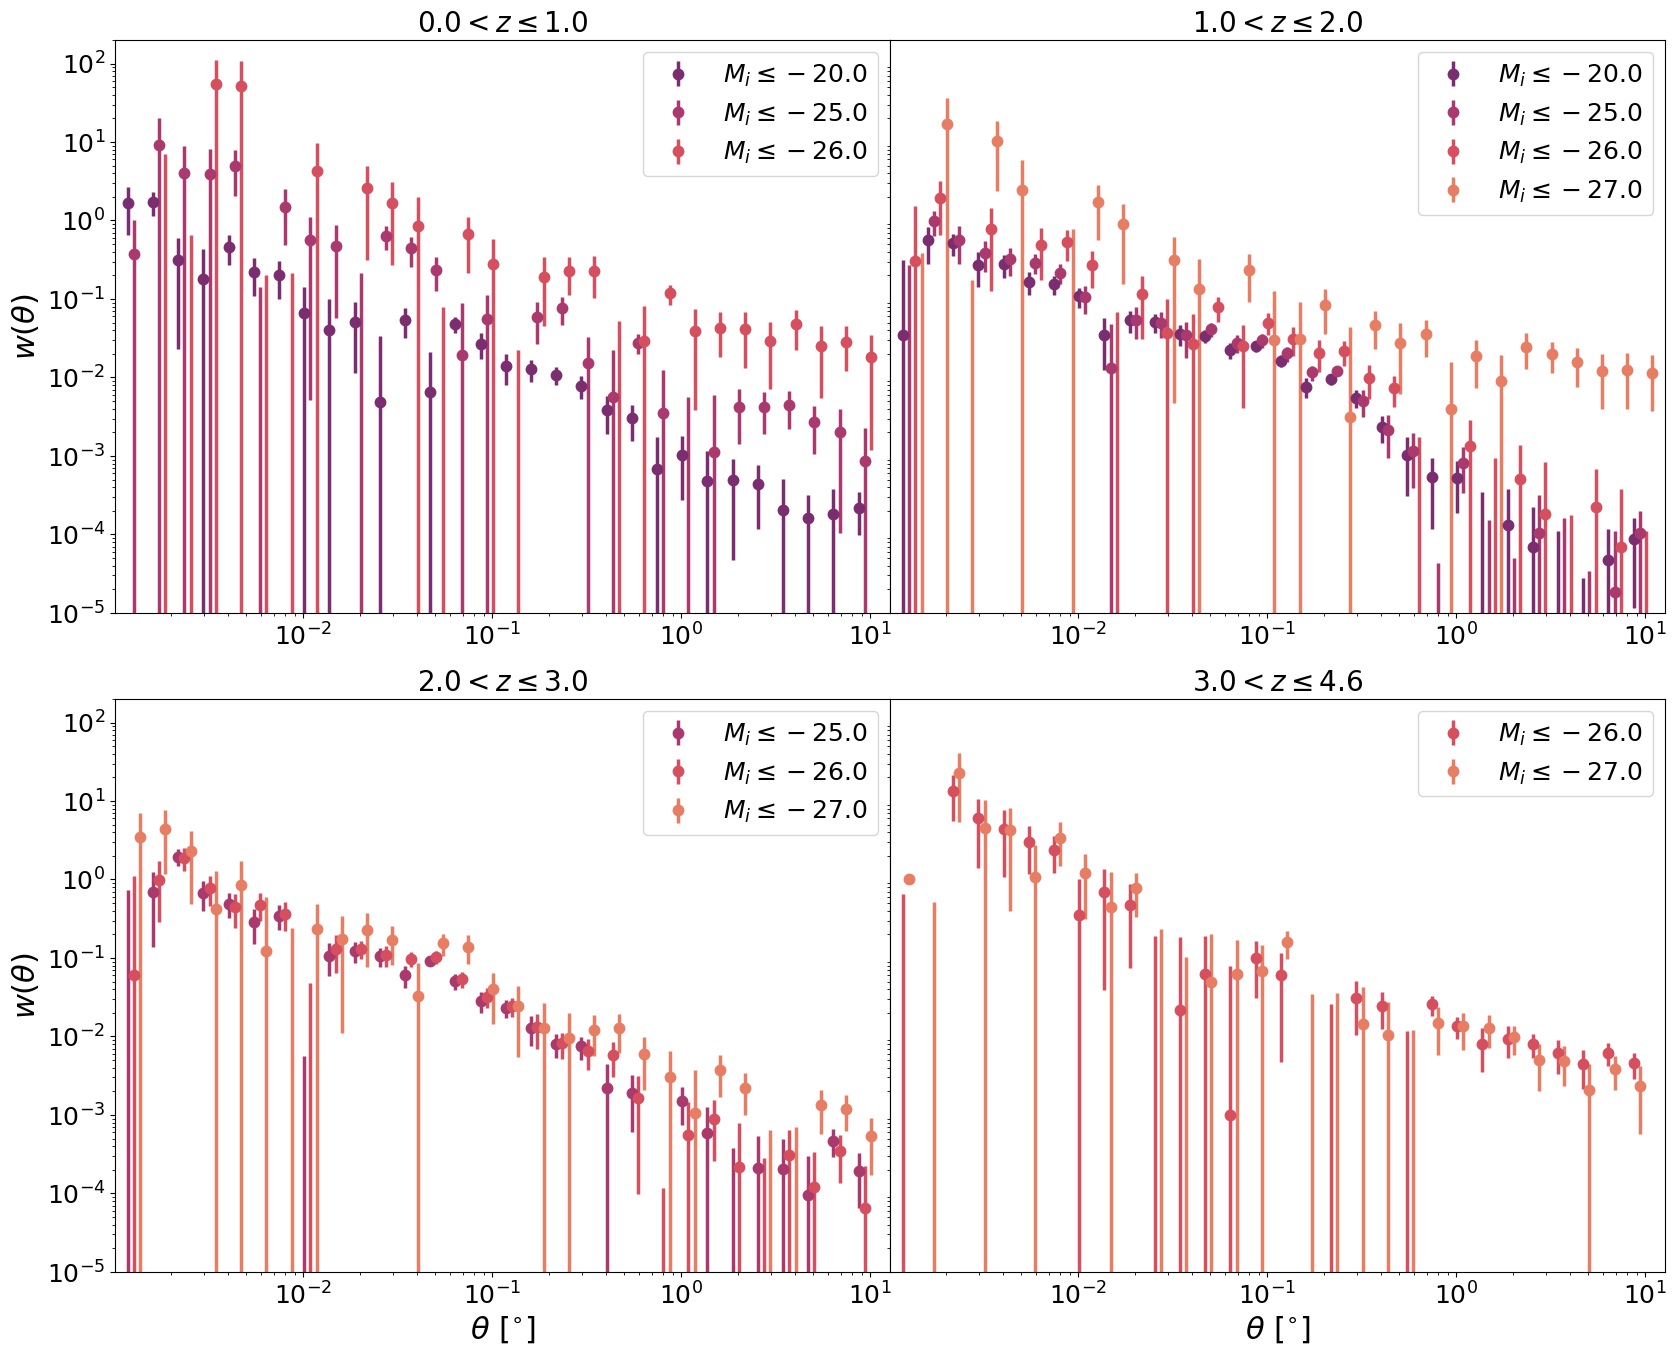

In [198]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

# remove bottom panel and just print bq somewhere
# plot!
for j in range(len(z_array)):

    ax1 = fig.add_subplot(gs[j])

    k=0
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
            
            sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
            wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
            a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            
            
            ax1.errorbar(10**(np.log10(quaia.recenter(thetabins)) + k*delta_xlim/2), wp_zbin_i, linewidth = 2.5, marker = 'o', color = cmap_theta[i],
                        yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '$M_i\leq{}$'.format(L_bins[i])) #capsize = 2.5

            ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + 5/2*delta_xlim))
            ax1.set_yscale('log')
            ax1.set_xscale('log')
            ax1.set_ylim(1e-5, 2e2)
            
            if j%2==0:
                ax1.set_ylabel(r"$w(\theta)$")
            else:
                ax1.set_yticks([])
            if j > 1:
                ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
            ax1.legend(loc = 'upper right')

            k+=1

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_27189/1720828843.py:21: SyntaxWarning: invalid escape sequence '\l'
  yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1])) #capsize = 2.5
/tmp/ipykernel_27189/1720828843.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))


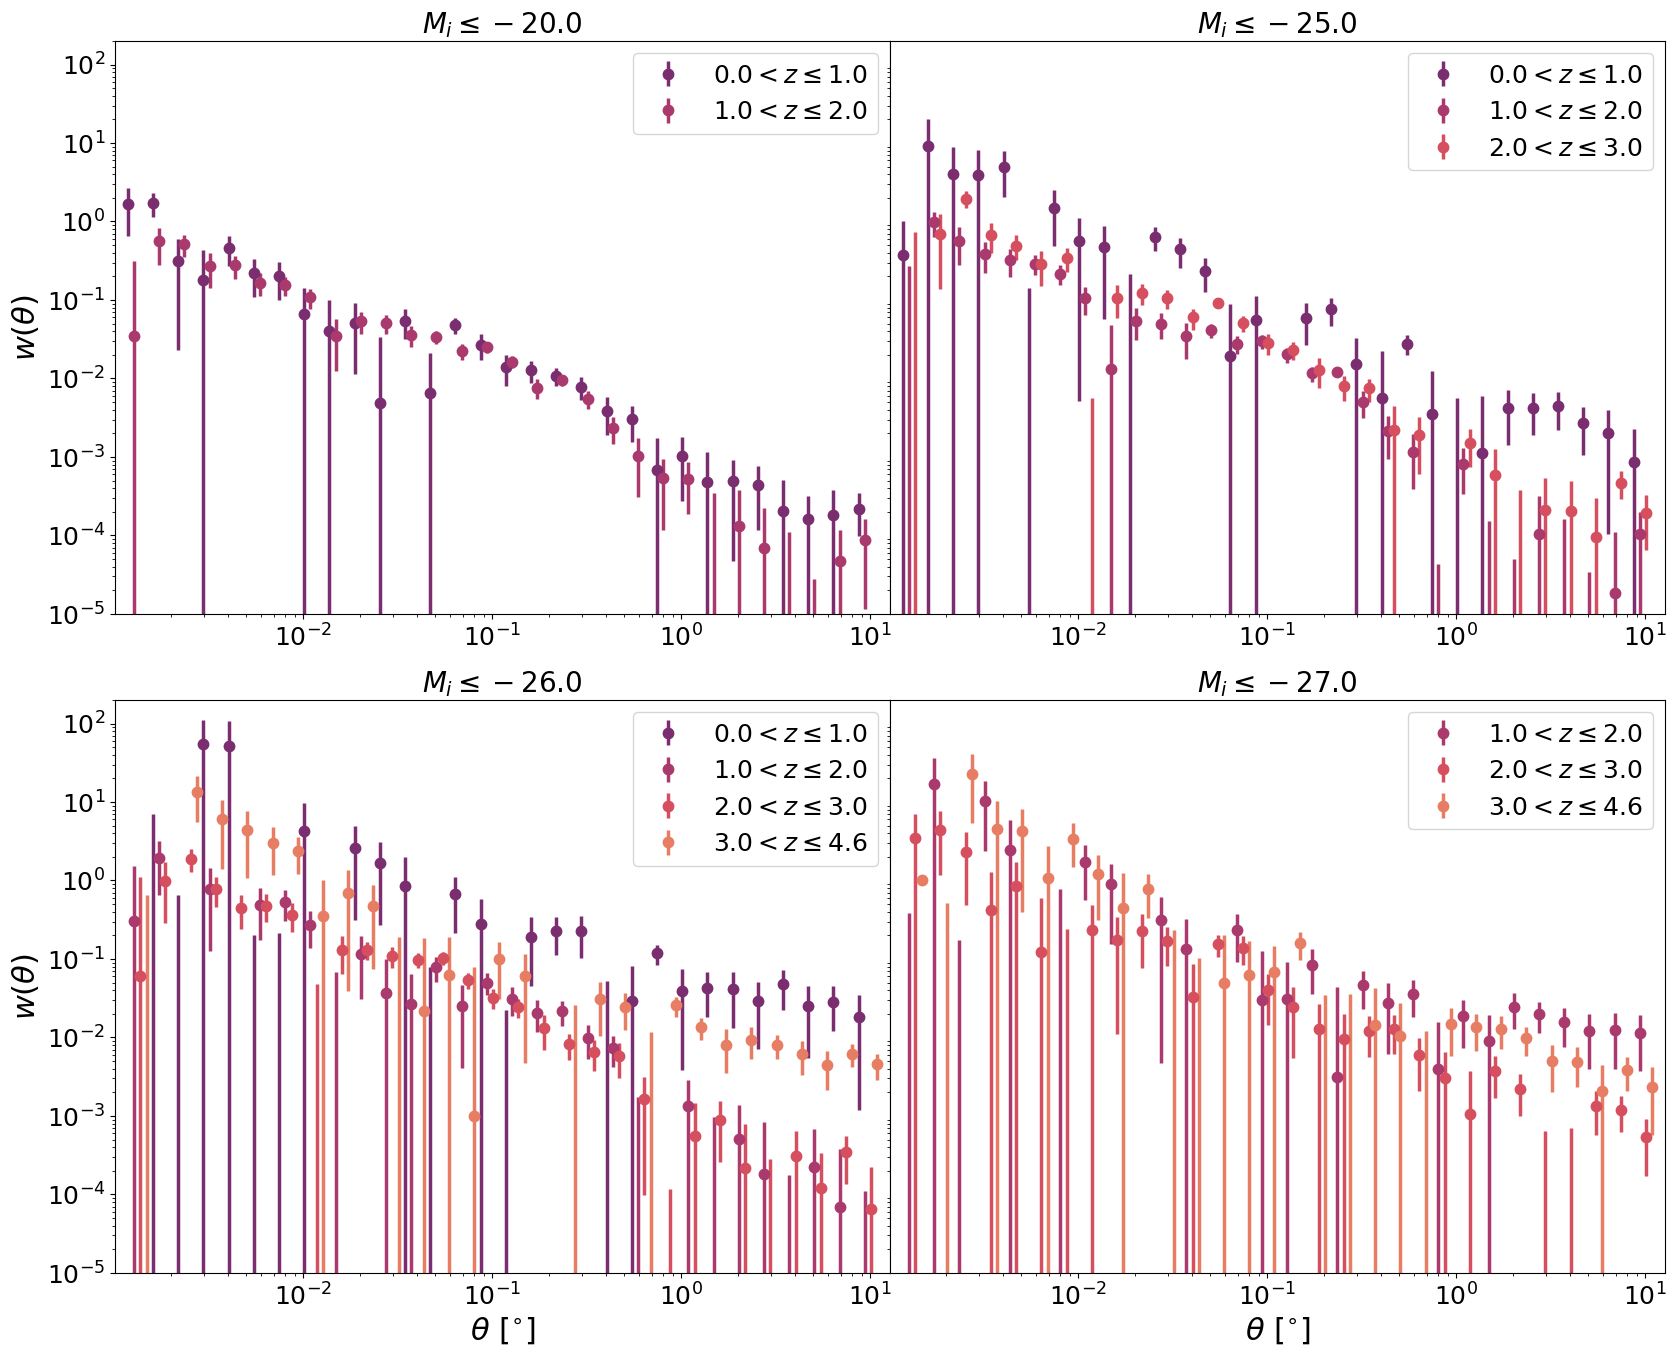

In [199]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

# remove bottom panel and just print bq somewhere
# plot!
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in range(len(z_array)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
            wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
            a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            
            
            ax1.errorbar(10**(np.log10(quaia.recenter(thetabins)) + j*delta_xlim/2), wp_zbin_i, linewidth = 2.5, marker = 'o', color = cmap_theta[j],
                        yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1])) #capsize = 2.5

            ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + 5/2*delta_xlim))
            ax1.set_yscale('log')
            ax1.set_xscale('log')
            ax1.set_ylim(1e-5, 2e2)
            
            if i%2==0:
                ax1.set_ylabel(r"$w(\theta)$")
            else:
                ax1.set_yticks([])
            if i > 1:
                ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
            ax1.legend(loc = 'upper right')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_27189/4099115089.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))


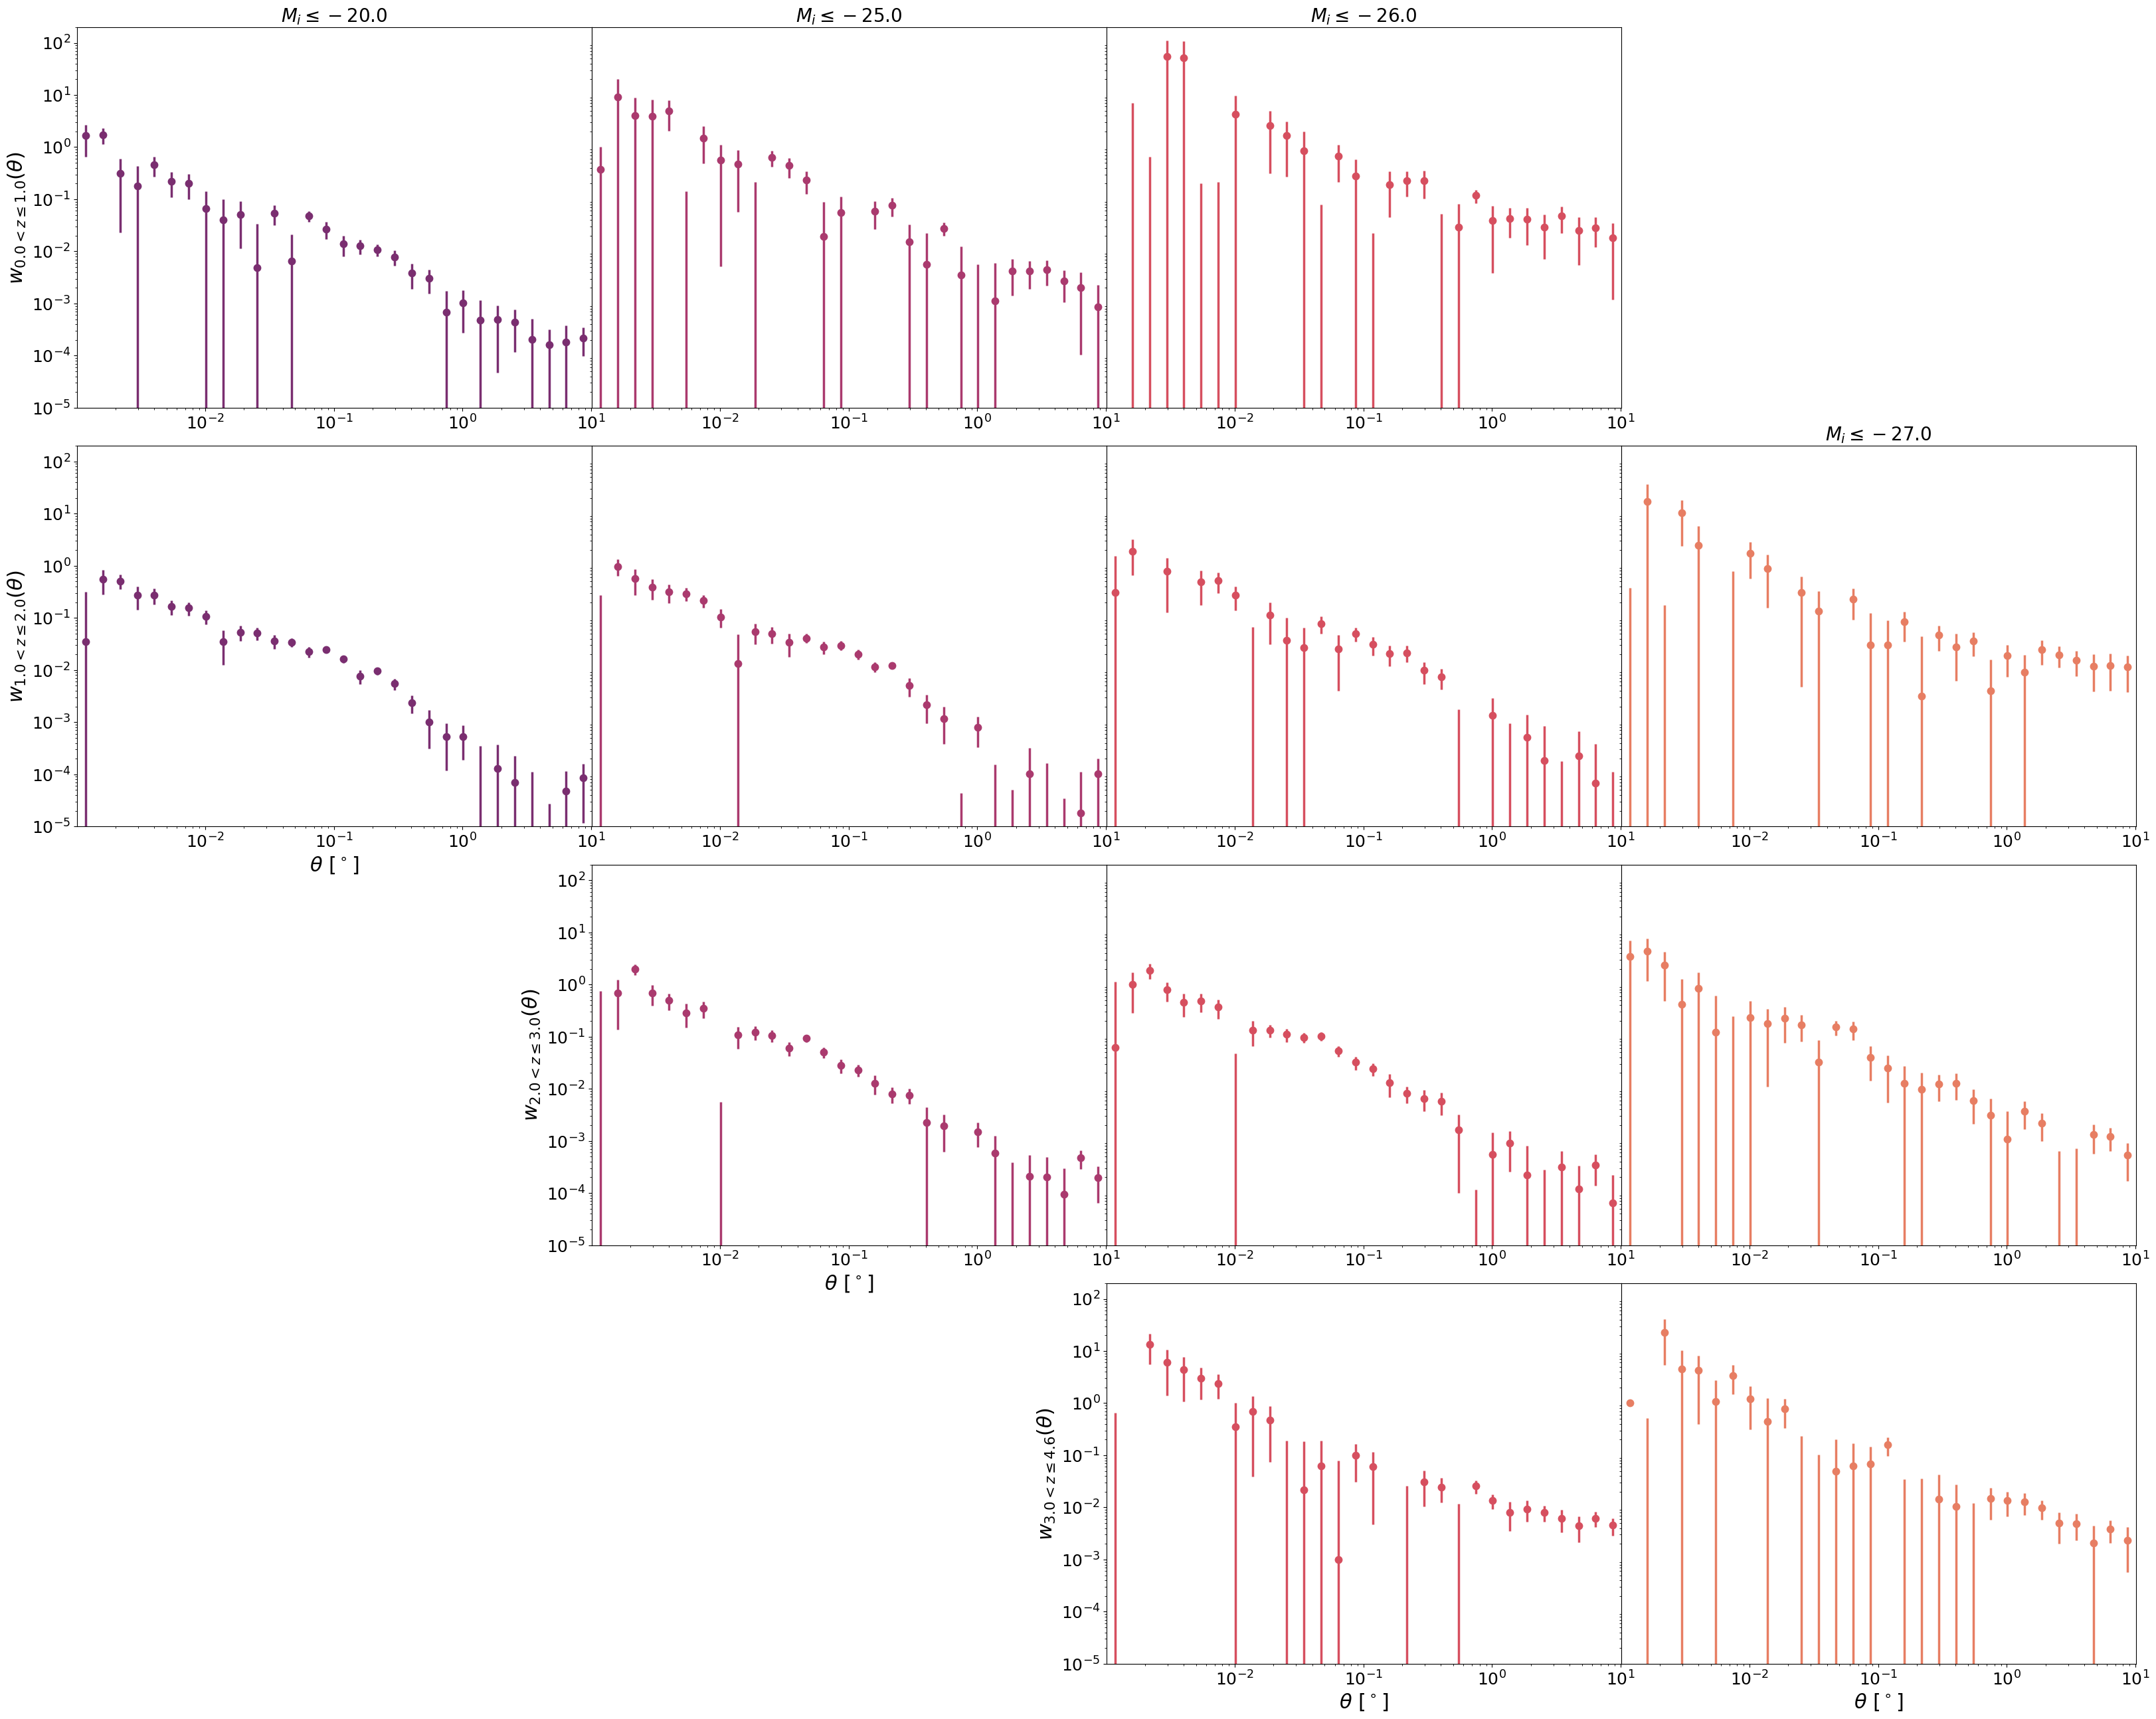

In [200]:
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
k = 3
b=30
for j in z_array:
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
                
            ax1 = fig.add_subplot(gs[j*4+i])

            if (j ==0) or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_ylim(1e-5, 2e2)
            
            if j > 2 or ((j>0) and (i <2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected
            if i==0 or ((j>1) and (i <3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
            else:
                ax1.set_yticks([])
            ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
                          
            wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
            a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            
            sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
                        
            ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, marker = 'o', markeredgewidth = 2.5,# capsize = 2.5,
                     linewidth = 2.5, color = cmap_theta[i], yerr = sigma, linestyle = 'none')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_27189/313468903.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


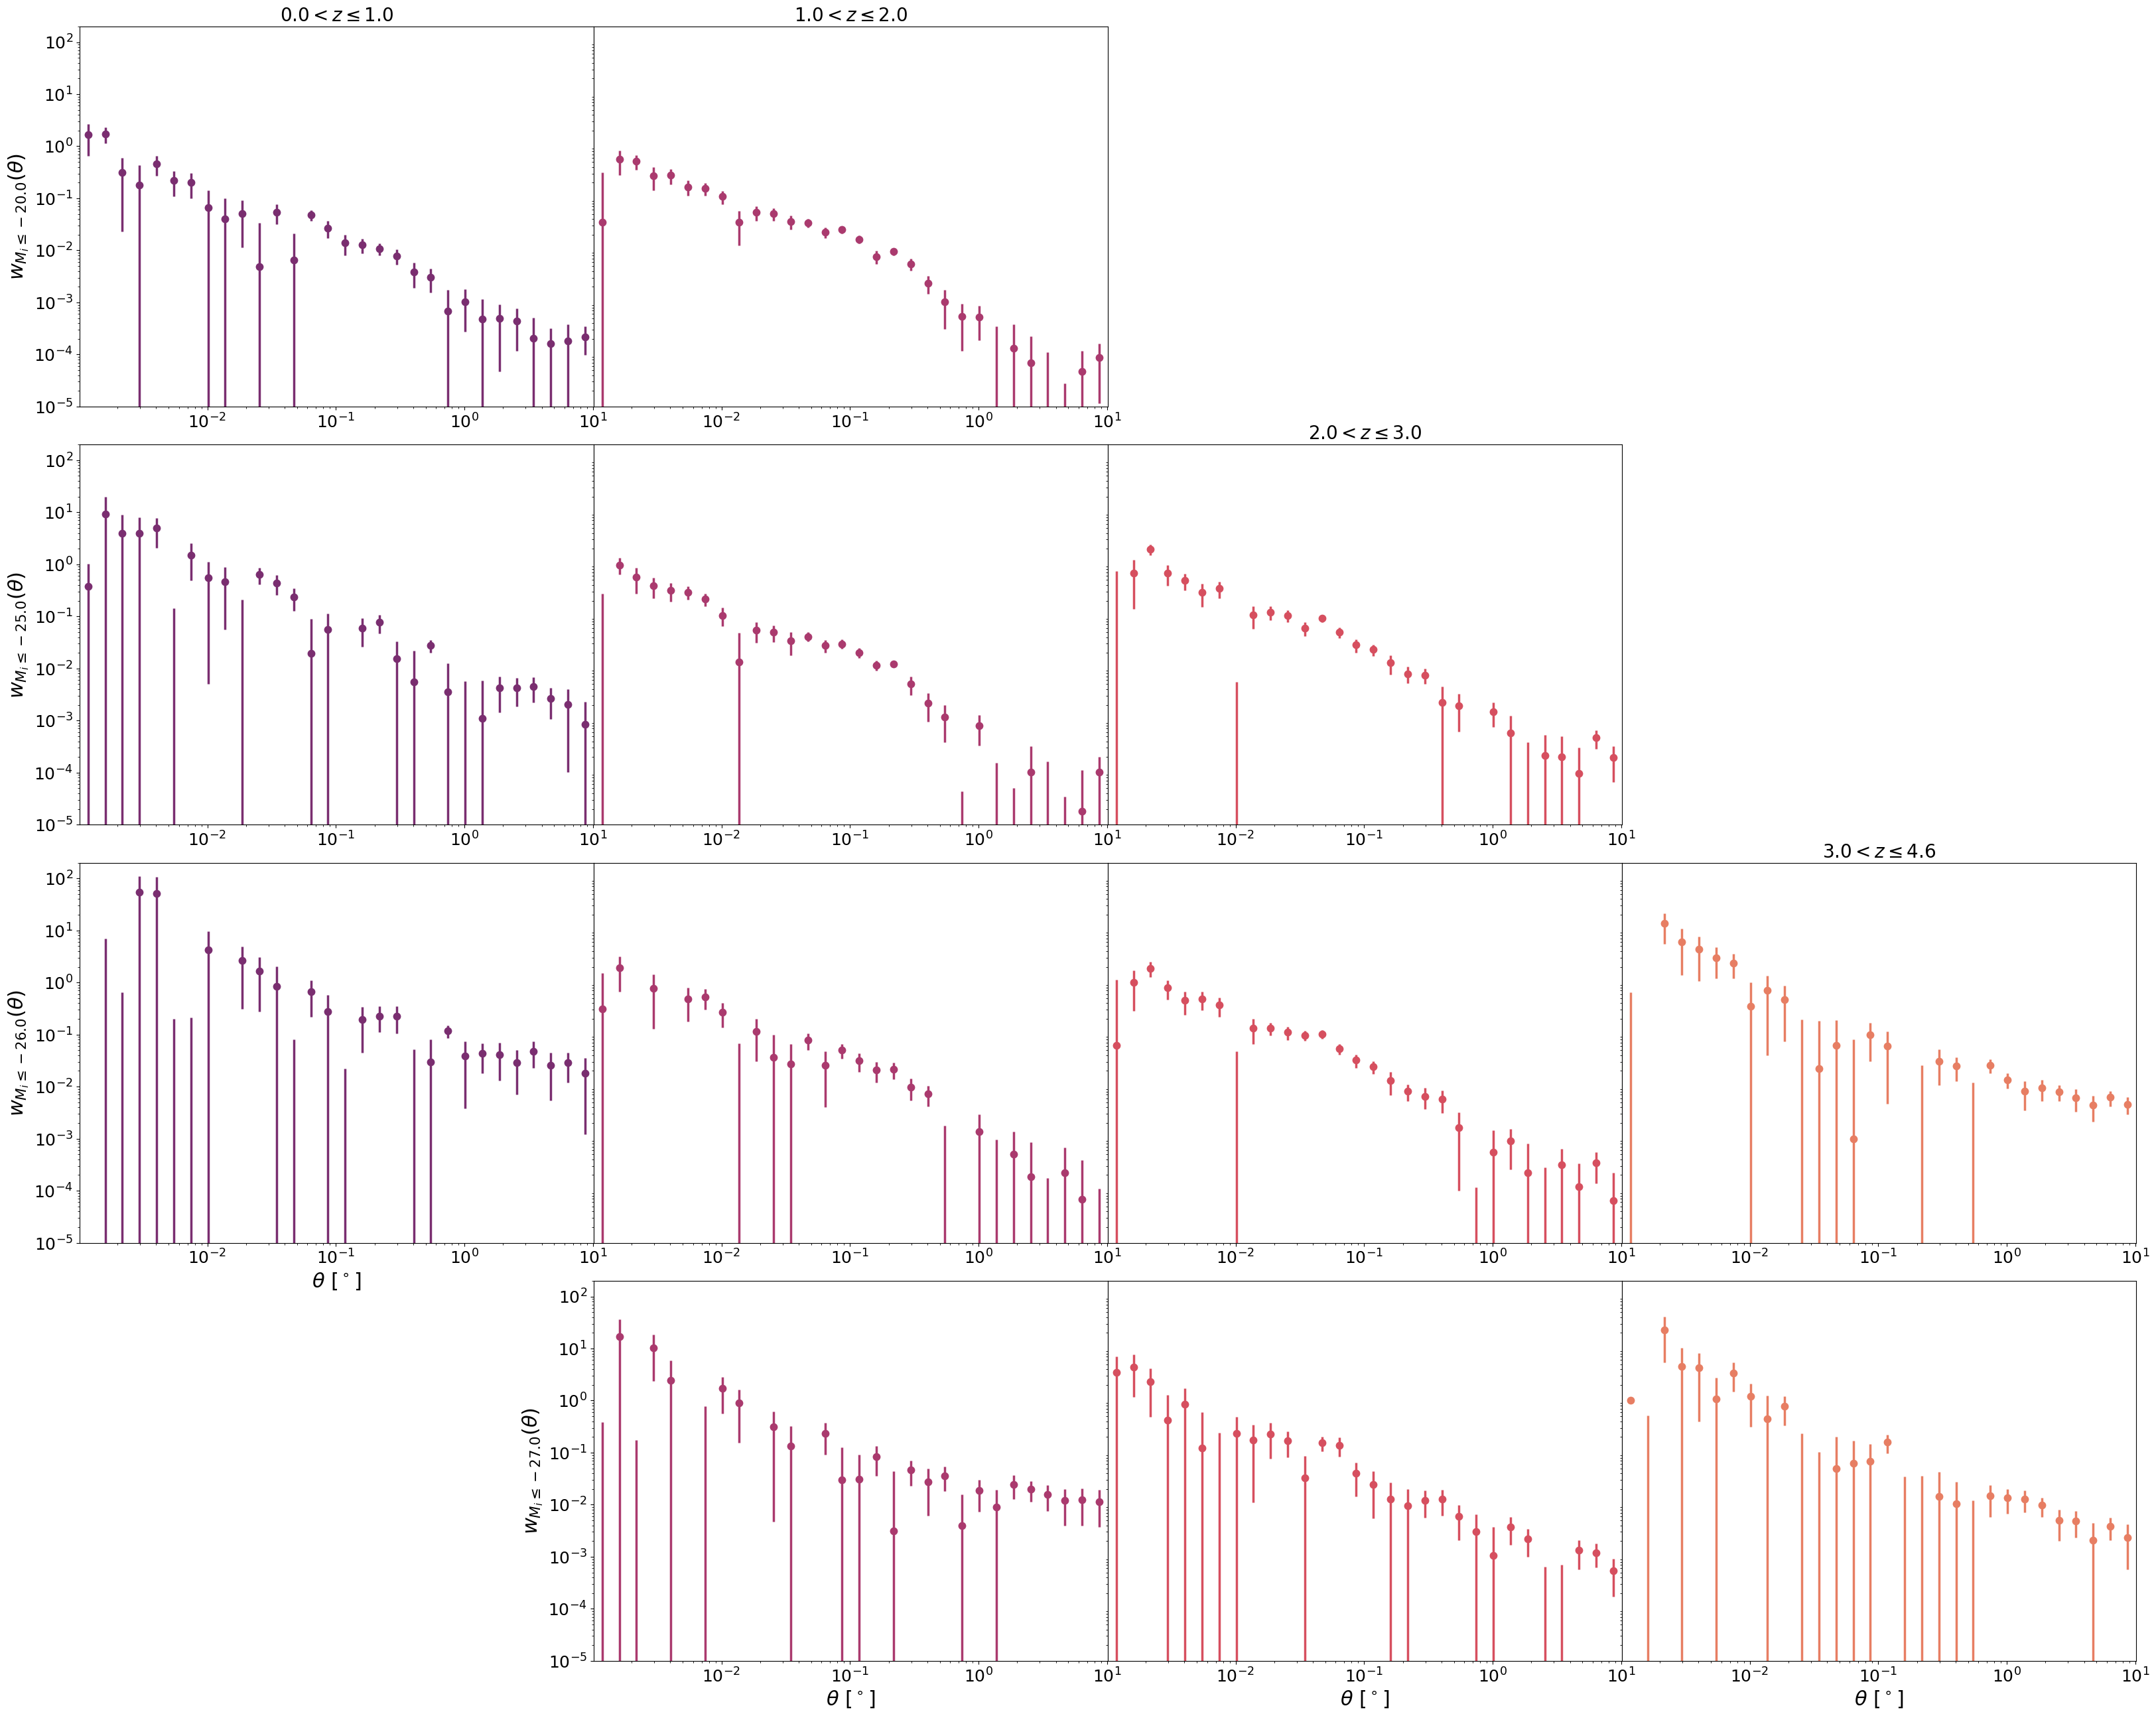

In [201]:
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
k = 3
b=30
for i in range(len(L_bins)):

    for j in z_array:
    
        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
                
            ax1 = fig.add_subplot(gs[i*4+j])

            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_ylim(1e-5, 2e2)
            
            if i > 2 or ((i ==2) and (j == 0)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_ylabel(r"$w_{{M_i\leq{}}}(\theta)$".format(L_bins[i]))
            else:
                ax1.set_yticks([])
            ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
                            
            wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
            a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            
            sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
                        
            ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, marker = 'o', markeredgewidth = 2.5,# capsize = 2.5,
                     linewidth = 2.5, color = cmap_theta[j], yerr = sigma, linestyle = 'none')

plt.show()

# Implement Limber approximation: $w(\theta)=\int d z \frac{H(z)}{c}\left(\frac{d N}{d z}\right)^2 \int \frac{d k k}{2 \pi} P_{q q} J_0[k \theta \chi(z)]=\int d z \frac{H(z)}{c}\left(\frac{d N}{d z}\right)^2 w_p(\theta \chi(z))$

In [202]:
theta_min = (rmin*u.deg).to(u.rad)
theta_max = (rmax*u.deg).to(u.rad)

zmin, zmax = 0.1, 4.6

lambda_min = theta_min*quaia.comoving_dist(zmin, units = 'Mpc')#/(1+zmin) # angular diameter distance
lambda_max = theta_max*quaia.comoving_dist(zmax, units = 'Mpc')#/(1+zmax)
print(lambda_min, lambda_max)

k_max = 2*np.pi/lambda_min
k_min = 2*np.pi/lambda_max
print(k_min, k_max)

np.log10(k_min.value), np.log10(k_max.value) 

0.007549695656720839 Mpc rad 1347.40810509432 Mpc rad
0.004663164250997107 1 / (Mpc rad) 832.243522503614 1 / (Mpc rad)


(-2.33131928708778, 2.920250423652214)

In [203]:
k_log = np.logspace(-2.5, 3) #, 1000) #-4, 2)

In [204]:
# rpbins = [(thetabins*u.deg).to(u.rad)*quaia.comoving_dist(z, units = 'Mpc') for z in dz]
# np.max(rpbins)

In [205]:
i = 0
j = 1
tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(
            G_hi, [j, i], True, ['z', 'L'], bins = [z_bins, L_bins], tab_gcat_type = 'data', method = ['minmax', 'max'], fac_rand = fac_rand, 
            n_bins = [None, None], b = b, mask_type = 'b', verbose = False)

In [206]:
dN_dz = np.sum(stats.norm.pdf(dz[None, :], loc=tab_datahi_mask_zbin0['redshift_quaia'][:, None], scale=tab_datahi_mask_zbin0['redshift_quaia_err'][:, None]), axis = 0)
norm = np.sum(stats.norm.cdf(dz[-1], loc=tab_datahi_mask_zbin0['redshift_quaia'], scale=tab_datahi_mask_zbin0['redshift_quaia_err']))

In [207]:
f_duty = 1e-2
Mmin = 12.5 #12 #13

In [208]:
bins_m = np.logspace(9, M_max, n_bins) #Mmin
n_c=N_c(bins_m, Mmin, f_duty, sigma = Sigma)

## Correct the 2-halo term: $P_{2 h}=P_m\left[\int d M \frac{d n}{d M} b_h(M, z)\left(\left\langle N_c\right\rangle+\tilde{u}\left\langle N_s\right\rangle\right)\right]^2$

In [209]:
M1 = np.log10(12*10**Mmin) #12
Alpha = 2.4 #0.2

<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/331930492.py:9: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M [M_\odot]$')
/tmp/ipykernel_27189/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


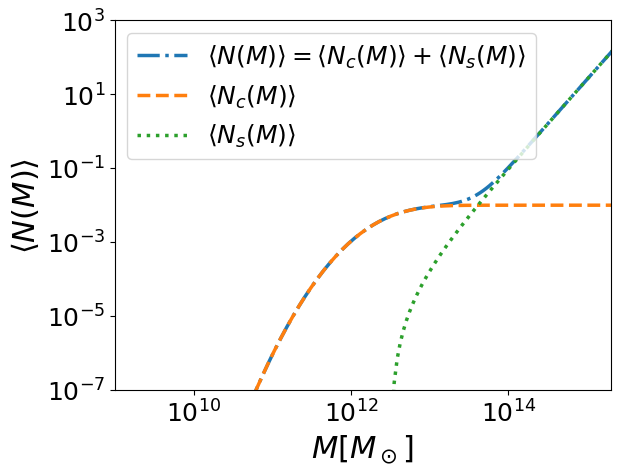

In [210]:
n_s = N_s(bins_m, f_duty, 10**Mmin, 10**M1, Alpha)
n_m = n_c+n_s

plt.plot(bins_m, n_m, linewidth = 2.5, linestyle = '-.', label = r'$\langle N(M) \rangle = \langle N_c(M) \rangle +\langle N_s(M) \rangle$')
plt.plot(bins_m, n_c, linewidth = 2.5, linestyle = '--', label = r'$\langle N_c(M) \rangle$')
plt.plot(bins_m, n_s, linewidth = 2.5, linestyle = ':', label = r'$\langle N_s(M) \rangle$')

plt.xscale('log')
plt.xlabel('$M [M_\odot]$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.yscale('log')
plt.ylim(1e-7, 1e3)
plt.xlim(1e9, 2e15)
plt.show()

In [211]:
# P_mm = [ccl.power.linear_matter_power(cosmo_planck18, k_log, 1/(1+z)) for z in dz]

In [212]:
H0_c_dN_dz = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+dz[i]))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz[i]/norm)**2 for i in range(len(dz))]

## where $\tilde{u}=f\left[\sin \kappa(\operatorname{Si}[\kappa(1+c)]-\operatorname{Si}(\kappa))+\cos \kappa(\operatorname{Ci}[\kappa(1+c)]-\operatorname{Ci}(\kappa))-\frac{\sin (\kappa c)}{\kappa(1+c)}\right]$ and $f=\frac{1} {\ln (1+c)-c /(1+c)}$

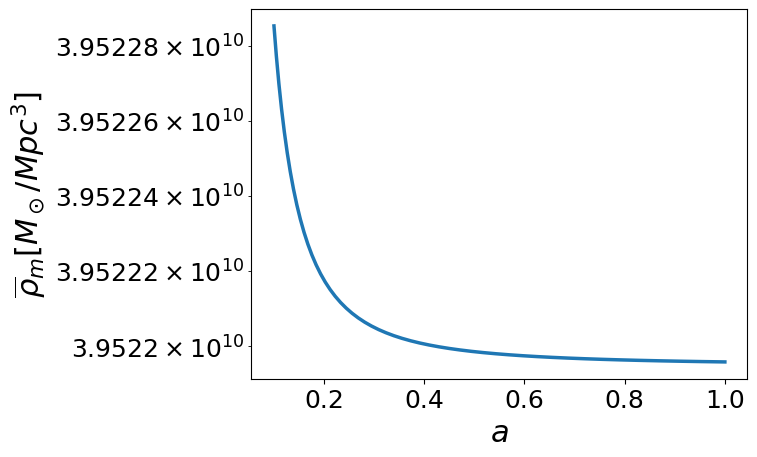

In [213]:
a_array = np.logspace(-1,0)
plt.plot(a_array, ccl.background.rho_x(cosmo_planck18, a_array, 'matter', is_comoving = True), linewidth = 2.5)
plt.yscale('log')
plt.xlabel('$a$')
plt.ylabel(r'$\overline{\rho}_m [M_\odot/Mpc^3]$')
plt.show()

### Sanity check concentration-mass relation

[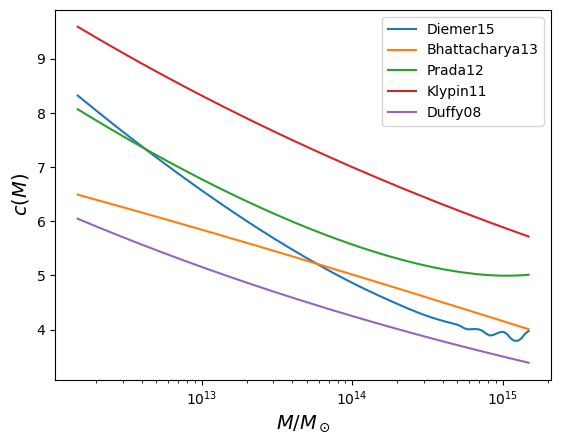](https://github.com/LSSTDESC/CCLX/blob/master/Halo-mass-function-example.ipynb)

In [214]:
# Cosmology
cosmo_lsst = ccl.Cosmology(Omega_b=0.0492, Omega_c=0.2650, h=0.6724, A_s=2.2065e-09, n_s=0.9645)

# Array of masses
m_arr = np.geomspace(1.01E12,1E15,128)/cosmo_lsst['h']

In [215]:
c_lsst = c_m(cosmo_lsst, m_arr, 1)
c = c_m(cosmo_planck18, bins, 1)

c_m_duffy = ccl.halos.concentration.duffy08.ConcentrationDuffy08()
c_duffy = c_m_duffy(cosmo_planck18, bins, 1)

c_m_bhattacharya = ccl.halos.concentration.bhattacharya13.ConcentrationBhattacharya13()
c_bhattacharya = c_m_bhattacharya(cosmo_planck18, bins, 1)

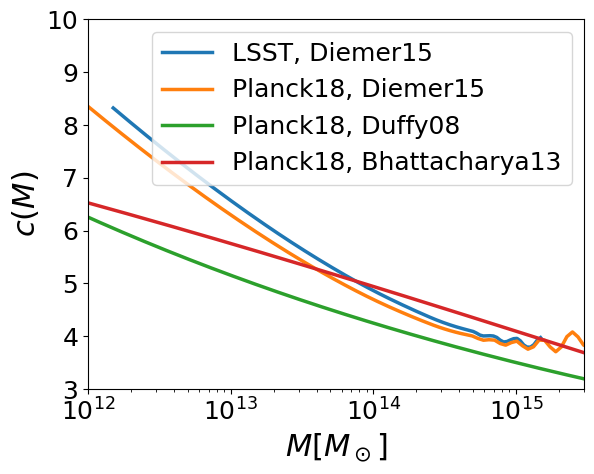

In [216]:
plt.plot(m_arr, c_lsst, linewidth = 2.5, label = 'LSST, Diemer15')
plt.plot(bins, c, linewidth = 2.5, label = 'Planck18, Diemer15')
plt.plot(bins, c_duffy, linewidth = 2.5, label = 'Planck18, Duffy08')
plt.plot(bins, c_bhattacharya, linewidth = 2.5, label = 'Planck18, Bhattacharya13')
plt.xscale('log')
plt.xlabel(r'$M [M_\odot]$')
plt.ylabel(r'$c(M)$')
plt.xlim(1e12, 3e15)
plt.ylim(3,10)
plt.legend()
plt.show()

In [217]:
def NFW(bins_m, a, k = k_log, Delta = Delta, cosmo = cosmo_planck18, c_m = c_m, mass_def = '200c'):

    c = c_m(cosmo, bins_m, a) # assumes 200c mass definition
    f = 1/(np.log(1+c)-c/(1+c))

    rho_bar = ccl.background.rho_x(cosmo, a, 'critical', is_comoving = True)  #'matter'  # Rvir = (3*bins_m*u.Msun/(4*np.pi*Delta*rho_bar))**(1/3) # Mpc
    Rvir = (3*bins_m/(4*np.pi*Delta*rho_bar))**(1/3) # Mpc
    kappa = k[:, None]*Rvir/c
    Si, Ci = sici(kappa*(1+c))
    Si_kappa, Ci_kappa = sici(kappa)
    
    u = f*(np.sin(kappa)*(Si-Si_kappa)+np.cos(kappa)*(Ci-Ci_kappa)-np.sin(kappa*c)/(kappa*(1+c)))
    u[k==0]=1
    
    return u

In [218]:
NFW_200c = ccl.halos.profiles.nfw.HaloProfileNFW(mass_def = '200c', concentration = c_m)

## Check that $\tilde{u}(k\rightarrow 0)=1$

In [219]:
NFW(bins, a, k = np.array([0]))

/tmp/ipykernel_27189/10283768.py:12: RuntimeWarning: invalid value encountered in subtract
  u = f*(np.sin(kappa)*(Si-Si_kappa)+np.cos(kappa)*(Ci-Ci_kappa)-np.sin(kappa*c)/(kappa*(1+c)))
/tmp/ipykernel_27189/10283768.py:12: RuntimeWarning: invalid value encountered in divide
  u = f*(np.sin(kappa)*(Si-Si_kappa)+np.cos(kappa)*(Ci-Ci_kappa)-np.sin(kappa*c)/(kappa*(1+c)))


array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.]])

## Sanity check $k-$space behavior 
[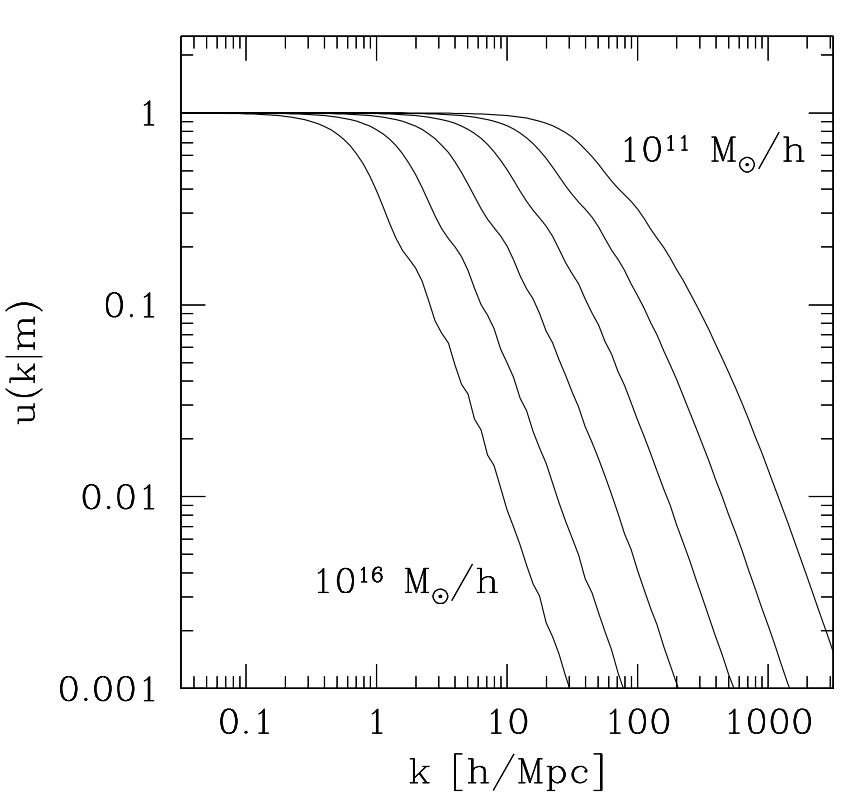](https://arxiv.org/abs/astro-ph/0206508)

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/1953439823.py:13: SyntaxWarning: invalid escape sequence '\o'
  label = '$M [M_\odot]$')


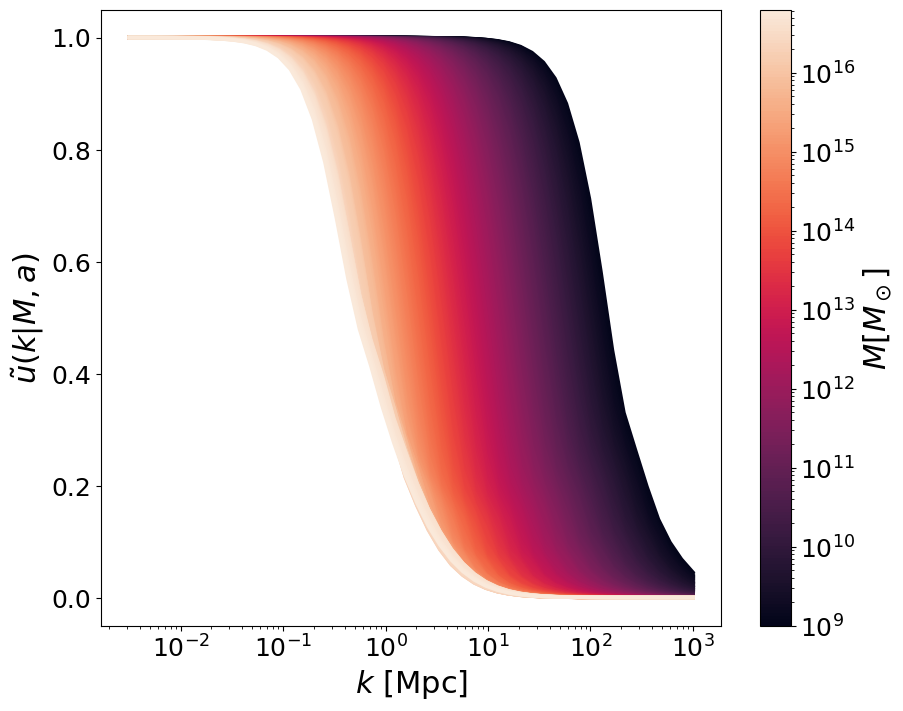

In [220]:
fig = plt.figure(figsize = (10, 8))
i, j = 0,1#3, 3
a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))   
for i in range(len(bins)):
    
    plt.plot(k_log, NFW(bins[i], a), color = cmap[i], linewidth = 2.5)
    
plt.xscale('log')
plt.ylabel(r'$\tilde{u}(k | M, a)$')
plt.xlabel('$k$ [Mpc]')

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), ax = plt.gca(),
                label = '$M [M_\odot]$')
plt.show()

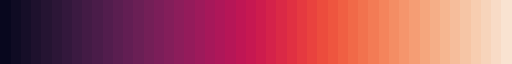

In [221]:
bins_u = np.logspace(np.log10(10**11/Planck18.h),np.log10(10**16/Planck18.h))
cmap_u = sns.color_palette("rocket", n_colors = len(bins_u))
palette_u = matplotlib.colors.ListedColormap(cmap_u)
palette_u

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/3197449368.py:15: SyntaxWarning: invalid escape sequence '\o'
  label = '$M [M_\odot]$')


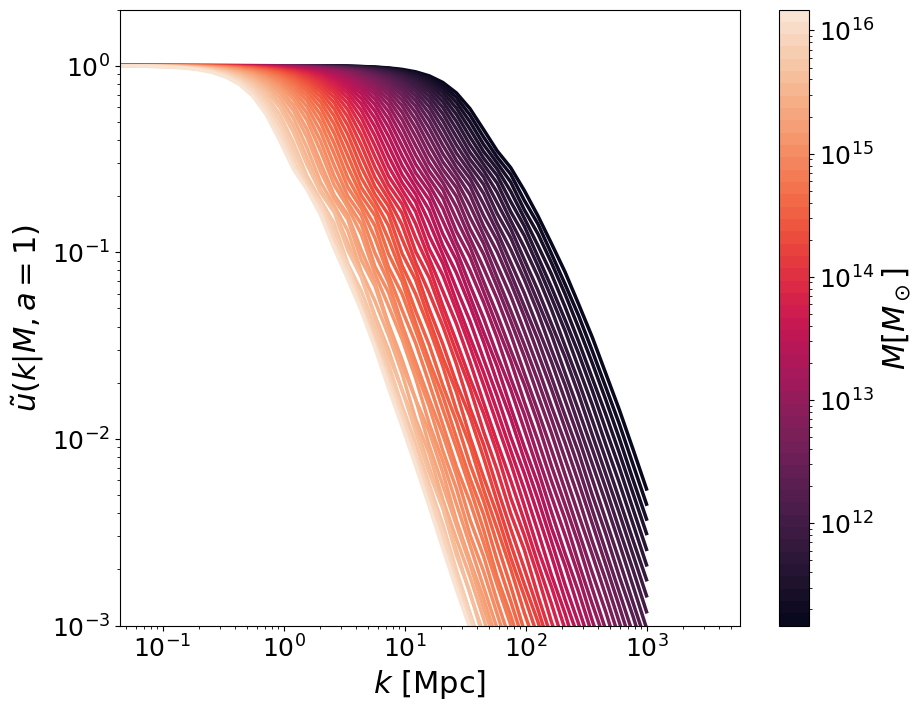

In [222]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(bins_u)):
    
    plt.plot(k_log, NFW(bins_u[i], 1), color = cmap_u[i], linewidth = 2.5)
    
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$\tilde{u}(k | M, a=1)$')
plt.xlabel('$k$ [Mpc]')
plt.ylim(1e-3, 2)
plt.xlim(3e-2/Planck18.h, 4e3/Planck18.h)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_u, norm = matplotlib.colors.LogNorm(vmin=bins_u[0], vmax = bins_u[-1])), ax = plt.gca(),
                label = '$M [M_\odot]$')
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/90288547.py:14: SyntaxWarning: invalid escape sequence '\o'
  label = '$M [M_\odot]$')


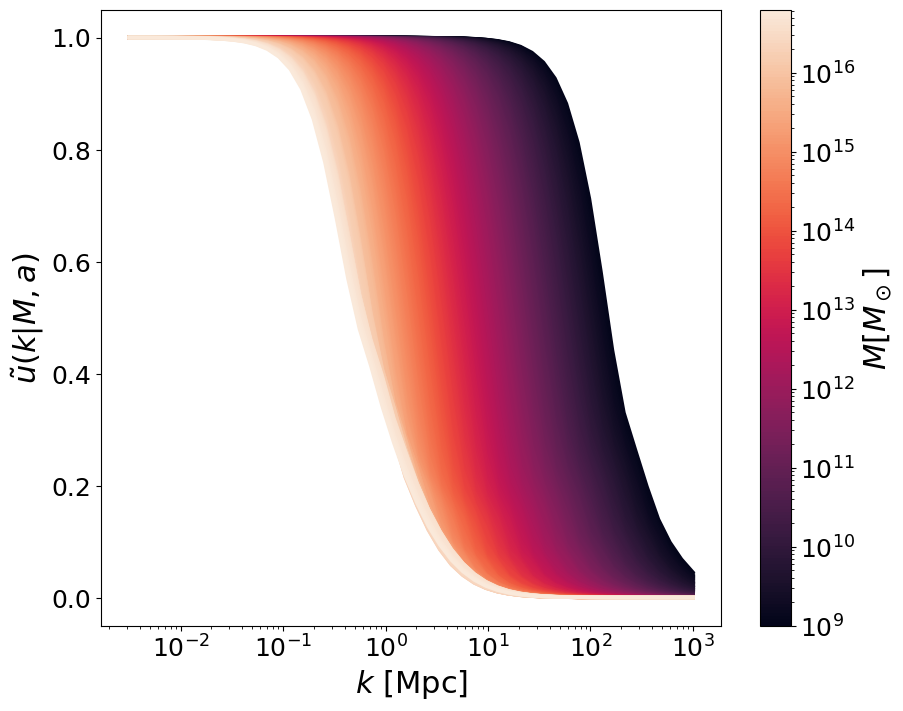

In [223]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(bins)):

    u_k = NFW_200c.fourier(cosmo_planck18, k_log, bins[i], a)/bins[i]
    
    plt.plot(k_log, u_k, color = cmap[i], linewidth = 2.5)
    
plt.xscale('log')
plt.ylabel(r'$\tilde{u}(k | M, a)$')
plt.xlabel('$k$ [Mpc]')

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), ax = plt.gca(),
                label = '$M [M_\odot]$')
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_27189/1488615138.py:17: SyntaxWarning: invalid escape sequence '\o'
  label = '$M [M_\odot]$')


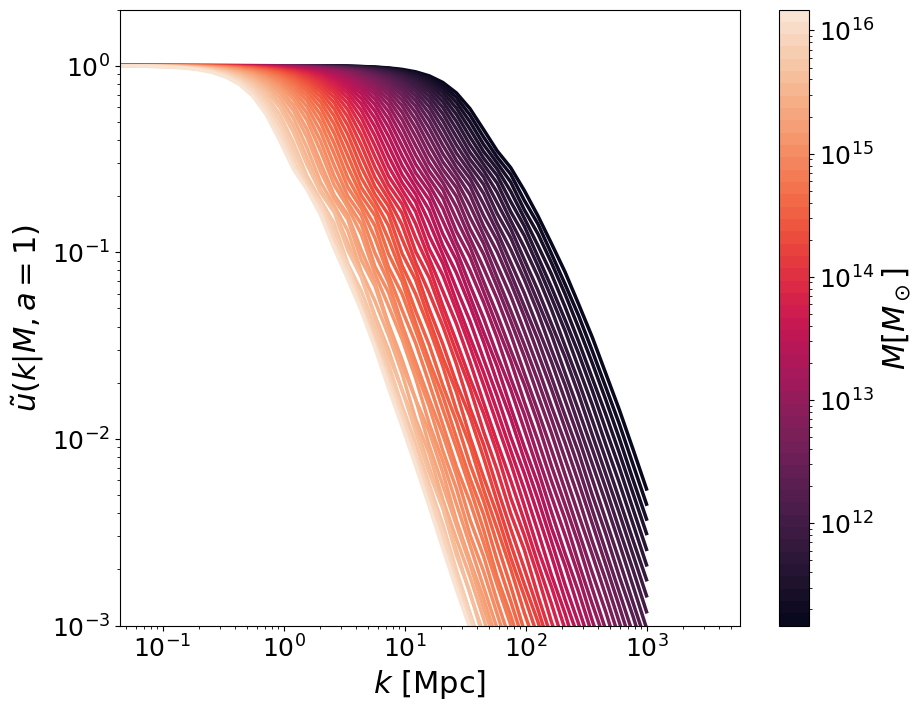

In [224]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(bins_u)):

    u_k = NFW_200c.fourier(cosmo_planck18, k_log, bins_u[i], 1)/bins_u[i]
    
    plt.plot(k_log, u_k, color = cmap_u[i], linewidth = 2.5)
    
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$\tilde{u}(k | M, a=1)$')
plt.xlabel('$k$ [Mpc]')
plt.ylim(1e-3, 2)
plt.xlim(3e-2/Planck18.h, 4e3/Planck18.h)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_u, norm = matplotlib.colors.LogNorm(vmin=bins_u[0], vmax = bins_u[-1])), ax = plt.gca(),
                label = '$M [M_\odot]$')
plt.show()

In [277]:
def HOD_2h(bins, M_min, fduty, sigma, a, M1, alpha, method = method, NFW_200c = NFW_200c, k = k_log, cosmo = cosmo_planck18): #, recenter = False):
    
    if method == 'manual':
        
        nfw = NFW(bins, a, k = k)

    else:

        nfw = NFW_200c.fourier(cosmo, k, bins, a).T/bins

    n_c = N_c(bins, M_min, 10**fduty, sigma = sigma)
    n_s = N_s(bins, 10**fduty, 10**M_min, 10**M1, alpha)
    
    return n_c+nfw*n_s, n_c, n_s #, recenter = recenter

## Model the 1-halo term: $P_{1 h}=\frac{1}{n_q^2} \int d M \frac{d n}{d M}\left[2 \tilde{u}\left\langle N_c N_s\right\rangle+\tilde{u}^2\left\langle N_s\left(N_s-1\right)\right\rangle\right]$

In [278]:
def P_1h(bins, a, n_g, params_n_m = None, params_HOD = None, k = k_log, cosmo = cosmo_planck18, recenter = False, method = method, hmf = hmf[mass_def], #n_c, n_s
         b1_E_func_tinker10 = b1_E_func_tinker10[mass_def], NFW_200c = NFW_200c, damping = False, k_star = 1e-2/Planck18.h, units = '1/Mpc^3'):

    if params_n_m is not None:
        
        n_c, n_s = params_n_m

    else:
        
        fduty, M_min, sigma, M1, alpha = params_HOD
        n_c = N_c(bins, M_min, 10**fduty, sigma = sigma)
        n_s = N_s(bins, 10**fduty, 10**M_min, 10**M1, alpha)

    if method == 'manual':
        nfw = NFW(bins, a, k = k)

    else:
        
        nfw = NFW_200c.fourier(cosmo, k, bins, a).T/bins
    
    n_m = 2*nfw*n_c*n_s+nfw**2*n_s**2 #(n_s-1) # assume poisson distribution for satellites # should i implement central satellite condition? i think no
    P_qq_1h, _ = bias(bins, n_m, a, cosmo, recenter = recenter, method = method, hmf = hmf, b1_E_func_tinker10 = b1_E_func_tinker10, 
                           b1_E_tinker = np.ones(np.shape(bins)), n_g_manual = n_g, units = units)

    if damping == True:
        P_qq_1h *= (k/k_star)**4/(1+(k/k_star)**4)

    return P_qq_1h/n_g #**2

In [279]:
def wtheta_2h_optimized(bins, H0_c_dN_dz, params_n_m = None, params_HOD = None, # P_mm = P_mm, 
                        wp = False, thetabins = thetabins, dz = dz, k = k_log, recenter = False, #n_m
                        theta_mask = False, cosmo = cosmo_planck18, # rpbins = rpbins, np.full_like(quaia.recenter(thetabins), True, dtype = bool)
                        hankel = mcfit.Hankel(k_log, lowring = True), recenter_thetabins = False, calc_bias = False, wtheta_mm = False, method = method, 
                        hmf = hmf[mass_def], b1_E_func_tinker10 = b1_E_func_tinker10[mass_def], NFW_200c = NFW_200c, one_halo = True, two_halo = True):

    # compute for each z... for statement?
    b_q, k_integral = [], []
    for z in dz:
        a = 1/(1+z)
        P_mm = ccl.power.linear_matter_power(cosmo, k, a)
        rpbins = (thetabins*u.deg).to(u.rad)*quaia.comoving_dist(z, units = 'Mpc')
        
        if params_n_m is not None:
            
            n_c, n_s = params_n_m

            if method == 'manual':
                n_m = n_c + NFW(bins, a, k = k)*n_s

            else:
                n_m = n_c + NFW_200c.fourier(cosmo, k, bins, a).T/bins*n_s
        else:
            
            fduty, M_min, sigma, M1, alpha = params_HOD
            n_m, n_c, n_s = HOD_2h(bins, M_min, fduty, sigma, a, M1, alpha, method = method, cosmo = cosmo, k = k) #, recenter = recenter)

        if wtheta_mm == True:
            b_z = 1
        else:

            _, n_g = bias(bins, n_c+n_s, a, cosmo, recenter = recenter, method = method, hmf = hmf, b1_E_func_tinker10 = b1_E_func_tinker10, 
                                   b1_E_tinker = np.ones(np.shape(bins)), units = '1/Mpc^3')
            
            b_z, _ = bias(bins, n_m, a, cosmo, recenter = recenter, method = method, hmf = hmf, b1_E_func_tinker10 = b1_E_func_tinker10, n_g_manual = n_g, units = '1/Mpc^3')
            
        if (one_halo == False) and (two_halo == True):
            
            P_qq = b_z**2*P_mm

        elif (one_halo == True) and (two_halo == False):

            P_qq = P_1h(bins, a, n_g, params_HOD = params_HOD, params_n_m = params_n_m, k = k, cosmo = cosmo, recenter = recenter, method = method, hmf = hmf, 
                                b1_E_func_tinker10 = b1_E_func_tinker10, NFW_200c = NFW_200c) #n_c, n_s
            
        else:
            
            P_qq_2h = b_z**2*P_mm*u.Mpc**3
            P_qq_1h = P_1h(bins, a, n_g, params_HOD = params_HOD, params_n_m = params_n_m, k = k, cosmo = cosmo, recenter = recenter, method = method, hmf = hmf, 
                                b1_E_func_tinker10 = b1_E_func_tinker10, NFW_200c = NFW_200c) #n_c, n_s
            P_qq = P_qq_2h + P_qq_1h
            
        rpbins_k, wp_k = hankel(P_qq/(2*np.pi))
        
        if recenter_thetabins == True:
            rp = quaia.recenter(rpbins.value)

        else:
            rp = rpbins.value

        if isinstance(theta_mask, bool):
            theta_mask = np.full_like(rp, True, dtype = bool)
        wp_z = np.interp(rp[theta_mask], rpbins_k, wp_k)
            
        k_integral.append(wp_z) # as a function of rp
        b_q.append(b_z)
        
    z_integrand = [H0_c_dN_dz[i]*k_integral[i] for i in range(len(dz))]
    if calc_bias == False:
    
        return np.trapz(z_integrand, dz, axis = 0)#, np.trapz(b_q*dN_dz, z_array) #np.trapz(b_q*np.array(n_g)*dN_dz, z_array)/np.trapz(n_g*dN_dz, z_array)

    else:
        return np.trapz(z_integrand, dz, axis = 0), np.trapz(b_q*dN_dz, dz)

In [280]:
da = 1/(1+dz)

In [229]:
P_mm = ccl.power.linear_matter_power(cosmo_planck18, k_log, da)

In [230]:
rpbins = (thetabins*u.deg).to(u.rad)[:, None]*quaia.comoving_dist(dz, units = 'Mpc')

In [275]:
def wtheta_2h_dynesty(bins, H0_c_dN_dz, params_HOD, thetabins = thetabins, k = k_log, recenter = False, theta_mask = theta_mask, cosmo = cosmo_planck18, hankel = mcfit.Hankel(k_log, lowring = True), recenter_thetabins = True, method = method, hmf = hmf[mass_def], b1_E_func_tinker10 = b1_E_func_tinker10[mass_def], 
                      NFW_200c = NFW_200c, P_mm = P_mm, da = da, rpbins = rpbins, dz = dz): #, k_integral = np.empty(np.shape(rpbins.T)), z_integrand = np.empty(np.shape(rpbins.T))):

    # compute for each z... for statement?
    b_q, P_qq = [], [] #k_integral #, []
    fduty, M_min, sigma, M1, alpha = params_HOD
    for i, a in enumerate(da):
        
        n_m, n_c, n_s = HOD_2h(bins, M_min, fduty, sigma, a, M1, alpha, method = method, cosmo = cosmo, k = k) #, recenter = recenter)
    
        n_g = bias(bins, n_c+n_s, a, cosmo, recenter = recenter, method = method, hmf = hmf, b1_E_func_tinker10 = b1_E_func_tinker10, 
                               b1_E_tinker = np.ones(np.shape(bins)), calc_bias = False, units = '1/Mpc^3')
        
        b_z, _ = bias(bins, n_m, a, cosmo, recenter = recenter, method = method, hmf = hmf, b1_E_func_tinker10 = b1_E_func_tinker10, n_g_manual = n_g, units = '1/Mpc^3')
            
        P_qq_2h = b_z**2*P_mm[i]*u.Mpc**3
        P_qq_1h = P_1h(bins, a, n_g, params_HOD = params_HOD, k = k, cosmo = cosmo, recenter = recenter, method = method, hmf = hmf, 
                            b1_E_func_tinker10 = b1_E_func_tinker10, NFW_200c = NFW_200c) #n_c, n_s
        P_qq.append(P_qq_2h + P_qq_1h)
        b_q.append(b_z)
    
    rpbins_k, wp_k = hankel(np.array(P_qq)/(2*np.pi))
    
    if recenter_thetabins == True:
        rp = quaia.recenter(rpbins.value)

    else:
        rp = rpbins.value

    if isinstance(theta_mask, bool):
        theta_mask = np.full_like(thetabins, True, dtype = bool)

    k_integral = [np.interp(rp[theta_mask][:,i], rpbins_k, wp_k[i]) for i in range(len(dz))]
    z_integrand = H0_c_dN_dz[:, None] * k_integral

    return np.trapz(z_integrand, dz, axis = 0)

In [232]:
i =0#3
j = 1#3

In [233]:
wtheta_2h_P_manual = wtheta_2h_optimized(bins_m, H0_c_dN_dz, params_n_m = [n_c, n_s]) #, cosmo = cosmo_planck18_old, hmf = hmf['200m'], b1_E_func_tinker10 = b1_E_func_tinker10['200m'], method = 'manual')

In [234]:
H0_c_dN_dz_array = np.array([H0_c_dN_dz_i.value for H0_c_dN_dz_i in H0_c_dN_dz])

In [235]:
wtheta_2h_P_scatter = wtheta_2h_dynesty(bins_m, H0_c_dN_dz_array, [np.log10(f_duty), Mmin, Sigma, M1, Alpha], recenter_thetabins = False, theta_mask = False) #wtheta_2h_optimized #params_HOD = 

/tmp/ipykernel_27189/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


In [236]:
wtheta_2h_P_1h = wtheta_2h_optimized(bins_m, H0_c_dN_dz, params_n_m = [n_c, n_s], two_halo = False) #, cosmo = cosmo_planck18_old, hmf = hmf['200m'], b1_E_func_tinker10 = b1_E_func_tinker10['200m'], method = 'manual')

In [237]:
wtheta_2h_P_2h = wtheta_2h_optimized(bins_m, H0_c_dN_dz, params_n_m = [n_c, n_s], one_halo = False) #, cosmo = cosmo_planck18_old, hmf = hmf['200m'], b1_E_func_tinker10 = b1_E_func_tinker10['200m'], method = 'manual')

In [248]:
# d_hmf = [hmf[mass_def](cosmo_planck18, bins, a) for a in da]
# d_b1 = [b1_E_func_tinker10[mass_def](cosmo_planck18, bins, a) for a in da]
# d_NFW = [NFW_200c.fourier(cosmo_planck18, k_log, bins, a).T/bins for a in da]

# ## Define functions
# def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf[mass_def], recenter = True, units = '(h/Mpc)^3', d_hmf = None):

#     if recenter == True:
#         bins = quaia.recenter(bins)
#     nm_value = d_hmf if d_hmf is not None else hmf(cosmo, bins, a)
#     if units == '(h/Mpc)^3':
#         # nm = hmf(cosmo, bins, a)/cosmo['h']**3*(cu.littleh/u.Mpc)**3
#         nm=nm_value/cosmo['h']**3*(cu.littleh/u.Mpc)**3
#     else:
#         # nm = hmf(cosmo, bins, a)*(1/u.Mpc)**3
#         nm=nm_value*(1/u.Mpc)**3
#     n_g = nm/(bins*np.log(10))*n_total
#     n_g[np.isnan(n_g)]=0
    
#     return n_g, nm # (units of Mpc/h)^3

# def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf[mass_def], #method = method,
#          b1_E_func_tinker10 = b1_E_func_tinker10[mass_def], b1_E_tinker = None, n_g_manual = None, calc_bias = True, units = '(h/Mpc)^3', d_hmf = None, d_b1 = None):

#     n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf, units = units, d_hmf = d_hmf)
#     if recenter == True:
#         print('recentering')
#         bins = quaia.recenter(bins)
        
#     if n_g_manual is None:
#         n_g = np.trapz(n_g, bins)
#         n_g_manual = n_g
        
#     if calc_bias == False:
#         return n_g

#     else:
        
#         dn_dm = nm/(bins*np.log(10))
    
#         if b1_E_tinker is None:
            
#             # b1_E_tinker = b1_E_func_tinker10(cosmo, bins, a)
#             b1_E_tinker = d_b1 if d_b1 is not None else b1_E_func_tinker10(cosmo, bins, a)
            
#         n_m[~np.isfinite(n_m)]=0 
#         integrand = dn_dm*n_m
#         integrand[np.isnan(integrand)]=0

#         return bias_function(n_g_manual, integrand, b1_E_tinker, bins, recenter = recenter), n_g

# def bias_function(n_g, integrand, b, bins, recenter = True):
    
#     if recenter == True:
#         print('recentering')
#         bins = quaia.recenter(bins)
        
#     return 1/n_g*np.trapz(integrand*b, bins)

# def HOD_scatter(bins, M_min, fduty, sigma):
    
#     return fduty/2*special.erfc(np.log(10**M_min/bins)/(np.sqrt(2)*np.log(10)*sigma))

# def N_c(bins_m, M_min, f_duty, ndim, M_max = M_max, sigma = 0):#, step = False): #, recenter = False): #bins_m

#     n_m = HOD_scatter(bins_m, M_min, f_duty, sigma)

#     if ndim == 2:

#         n_m[bins_m==10**M_min]=f_duty # step

#     else:

#         n_m[bins_m==10**M_min]=f_duty/2 # scatter
        
#     return n_m

# def N_s(bins_m, fduty, M0, M1, alpha, exp = False, step = True): #bins_m

#     if exp == False:

#         n_m = fduty*((bins_m-M0)/M1)**alpha
        
#         if step == True:
#             n_m[bins_m<M0]=0
            
#     else:

#         n_m = N_s_exp(bins_m, M1, alpha, M0, fduty)
        
#     return n_m

# def N_s_exp(M, M1, alpha, Mcut, fduty):

#     return fduty*(M/M1)**alpha*np.exp(-Mcut/M)

# def HOD_2h(bins, M_min, fduty, sigma, a, M1, alpha, ndim, NFW_200c = NFW_200c, k = k_log, cosmo = cosmo_planck18, d_NFW = None): #, recenter = False): # method = method, 

#     nfw = d_NFW if d_NFW is not None else NFW_200c.fourier(cosmo, k, bins, a).T/bins

#     n_c = N_c(bins, M_min, 10**fduty, ndim, sigma = sigma)
#     n_s = N_s(bins, 10**fduty, 10**M_min, 10**M1, alpha)
    
#     return n_c+nfw*n_s, n_c, n_s #, recenter = recenter

# def P_1h(bins, a, n_g, ndim, params_n_m = None, params_HOD = None, k = k_log, cosmo = cosmo_planck18, recenter = False, hmf = hmf[mass_def], #n_c, n_s #method = method, 
#          b1_E_func_tinker10 = b1_E_func_tinker10[mass_def], NFW_200c = NFW_200c, damping = False, k_star = 1e-2/Planck18.h, units = '1/Mpc^3', d_hmf = None, d_b1 = None, d_NFW = None): #[mass_def]

#     if params_n_m is not None:
        
#         n_c, n_s = params_n_m

#     else:
        
#         fduty, M_min, sigma, M1, alpha = params_HOD
#         n_c = N_c(bins, M_min, 10**fduty, ndim, sigma = sigma)
#         n_s = N_s(bins, 10**fduty, 10**M_min, 10**M1, alpha)

#     nfw = d_NFW if d_NFW is not None else NFW_200c.fourier(cosmo, k, bins, a).T/bins
    
#     n_m = 2*nfw*n_c*n_s+nfw**2*n_s**2 #(n_s-1) # assume poisson distribution for satellites # should i implement central satellite condition? i think no
#     P_qq_1h, _ = bias(bins, n_m, a, cosmo, recenter = recenter, hmf = hmf, b1_E_func_tinker10 = b1_E_func_tinker10, #method = method,
#                            b1_E_tinker = np.ones(np.shape(bins)), n_g_manual = n_g, units = units, d_hmf = d_hmf, d_b1 = d_b1)

#     if damping == True:
#         P_qq_1h *= (k/k_star)**4/(1+(k/k_star)**4)

#     return P_qq_1h/n_g #**2
 
# def wtheta_2h_dynesty(bins, H0_c_dN_dz, params_HOD, ndim, thetabins = thetabins, k = k_log, recenter = False, theta_mask = theta_mask, cosmo = cosmo_planck18, hankel = mcfit.Hankel(k_log, lowring = True), recenter_thetabins = True, hmf = hmf[mass_def], b1_E_func_tinker10 = b1_E_func_tinker10[mass_def], #method = method
#                       NFW_200c = NFW_200c, P_mm = P_mm, da = da, rpbins = rpbins, dz = dz, d_hmf = d_hmf, d_b1 = d_b1, d_NFW = d_NFW): #, k_integral = np.empty(np.shape(rpbins.T)), z_integrand = np.empty(np.shape(rpbins.T))):

#     # compute for each z... for statement?
#     b_q, P_qq = [], [] #k_integral #, []
#     fduty, M_min, sigma, M1, alpha = params_HOD
#     for i, a in enumerate(da):
        
#         n_m, n_c, n_s = HOD_2h(bins, M_min, fduty, sigma, a, M1, alpha, ndim, cosmo = cosmo, k = k, NFW_200c = NFW_200c, d_NFW = d_NFW[i]) #, recenter = recenter)
    
#         n_g = bias(bins, n_c+n_s, a, cosmo, recenter = recenter, hmf = hmf, b1_E_func_tinker10 = b1_E_func_tinker10, 
#                                b1_E_tinker = np.ones(np.shape(bins)), calc_bias = False, units = '1/Mpc^3', d_hmf = d_hmf[i], d_b1 = d_b1[i])
        
#         b_z, _ = bias(bins, n_m, a, cosmo, recenter = recenter, hmf = hmf, b1_E_func_tinker10 = b1_E_func_tinker10, n_g_manual = n_g, units = '1/Mpc^3', d_hmf = d_hmf[i])
            
#         P_qq_2h = b_z**2*P_mm[i]*u.Mpc**3
#         P_qq_1h = P_1h(bins, a, n_g, ndim, params_HOD = params_HOD, k = k, cosmo = cosmo, recenter = recenter, hmf = hmf, 
#                             b1_E_func_tinker10 = b1_E_func_tinker10, NFW_200c = NFW_200c, d_hmf = d_hmf[i], d_b1 = d_b1[i], d_NFW = d_NFW[i]) #n_c, n_s
#         P_qq.append(P_qq_2h + P_qq_1h)
#         b_q.append(b_z)
    
#     rpbins_k, wp_k = hankel(np.array(P_qq)/(2*np.pi))
    
#     if recenter_thetabins == True:
#         rp = quaia.recenter(rpbins.value)

#     else:
#         rp = rpbins.value

#     if isinstance(theta_mask, bool):
#         theta_mask = np.full_like(thetabins, True, dtype = bool)

#     k_integral = [np.interp(rp[theta_mask][:,i], rpbins_k, wp_k[i]) for i in range(len(dz))]
#     z_integrand = H0_c_dN_dz[:, None] * k_integral

#     return np.trapz(z_integrand, dz, axis = 0)

# wtheta_2h_P_scatter_2 = wtheta_2h_dynesty(bins_m, H0_c_dN_dz_array, [np.log10(f_duty), Mmin, Sigma, M1, Alpha], 3, recenter_thetabins = False, theta_mask = False) #wtheta_2h_optimized #params_HOD = 

/tmp/ipykernel_27189/1223723193.py:82: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_27189/2392190643.py:23: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_title('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]))


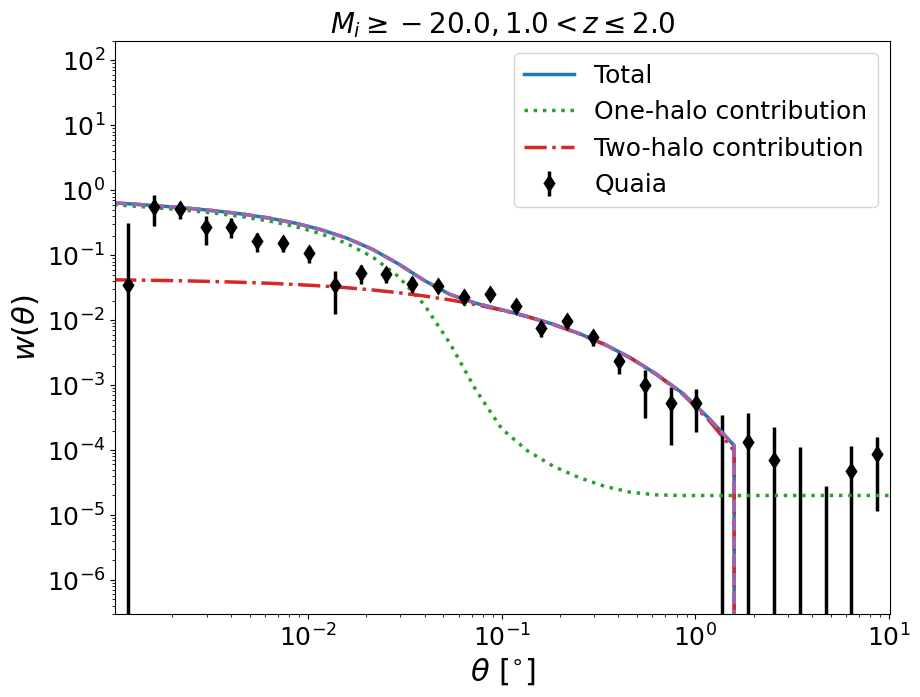

In [249]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)
# remove bottom panel and just print bq somewhere
# plot!

ax1 = fig.add_subplot(gs[0])

sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            

ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, linewidth = 2.5, marker = 'd', color = 'black',
            yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = 'Quaia') #capsize = 2.5

plt.plot(thetabins, wtheta_2h_P_manual, linewidth = 2.5, label = 'Total')
plt.plot(thetabins, wtheta_2h_P_scatter, linewidth = 2.5, linestyle = '--')
plt.plot(thetabins, wtheta_2h_P_1h, linewidth = 2.5, label = 'One-halo contribution', linestyle = ':')
plt.plot(thetabins, wtheta_2h_P_2h, linewidth = 2.5, label = 'Two-halo contribution', linestyle = '-.')
# plt.plot(thetabins, wtheta_2h_P_scatter_2, linewidth = 2.5, linestyle = '--')

ax1.set_title('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]))
ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_ylim(3e-7, 2e2)

ax1.set_ylabel(r"$w(\theta)$")
ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
ax1.legend(loc = 'upper right')

plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_27189/830572828.py:2: SyntaxWarning: invalid escape sequence '\l'
  plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$M_i\leq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), histtype = 'step', linewidth = 2.5, density = True, bins = 15)
/tmp/ipykernel_27189/830572828.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$M_i\leq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), histtype = 'step', linewidth = 2.5, bins = 15)


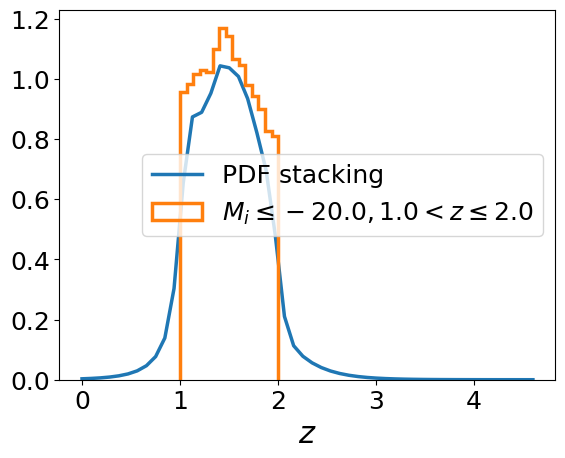

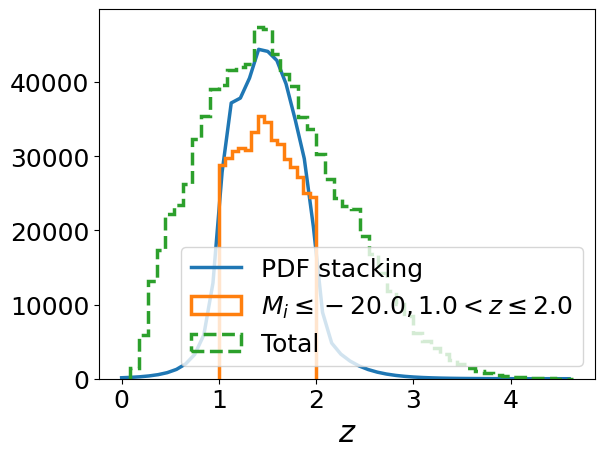

In [250]:
plt.plot(dz, dN_dz/norm, label = 'PDF stacking', linewidth = 2.5)
plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$M_i\leq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), histtype = 'step', linewidth = 2.5, density = True, bins = 15)
plt.legend()
plt.xlabel('$z$')
plt.show()

plt.plot(dz, dN_dz*np.diff(dz)[0], label = 'PDF stacking', linewidth = 2.5)
plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$M_i\leq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), histtype = 'step', linewidth = 2.5, bins = 15)
plt.hist(tab_datahi_mask['redshift_quaia'], label = 'Total', histtype = 'step', linewidth = 2.5, bins = 50, linestyle = '--')
plt.legend()
plt.xlabel('$z$')
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_27189/2347691315.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$z_\mathrm{Quaia}$', histtype = 'step', linewidth = 2.5, density = True, bins = 15, color = 'black')


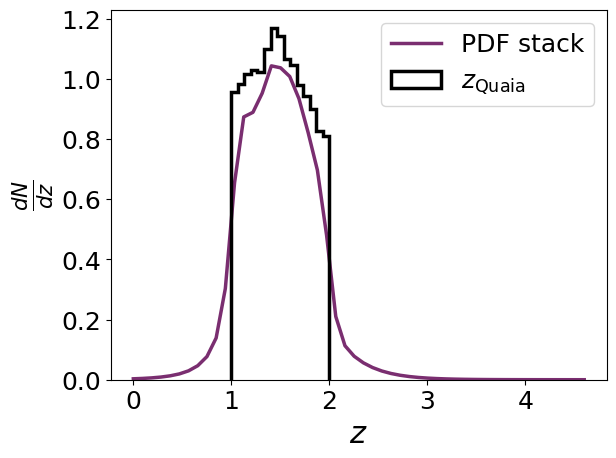

In [251]:
plt.plot(dz, dN_dz/norm, label = 'PDF stack', linewidth = 2.5, color = cmap_theta[i])
plt.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '$z_\mathrm{Quaia}$', histtype = 'step', linewidth = 2.5, density = True, bins = 15, color = 'black')
plt.legend()
plt.xlabel('$z$')
plt.ylabel(r'$\frac{dN}{dz}$')
plt.show()

## See impact of varying the redshift distribution

In [252]:
sigma_z = np.linspace(0, 4.6, 701) #-4

In [253]:
z=np.round(np.mean(tab_datahi_mask['redshift_quaia']), 1)
z

1.6

In [254]:
delta = 0.9 #8 #0.75
delta

0.9

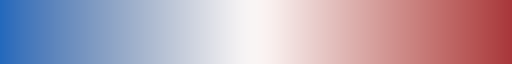

In [255]:
cmap_z = sns.color_palette("vlag", n_colors = len(sigma_z))
palette_z = matplotlib.colors.ListedColormap(cmap_z)
palette_z

In [256]:
sigma_dz_array = np.linspace(0,0.2, 151) #-4
delta_dz = 0.1

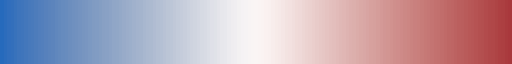

In [257]:
cmap_dz = sns.color_palette("vlag", n_colors = len(sigma_dz_array))
palette_dz = matplotlib.colors.ListedColormap(cmap_dz)
palette_dz

In [258]:
z_err = np.round(np.mean(tab_datahi_mask['redshift_quaia_err']), 1)
z_err

0.2

<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_27189/3976156535.py:17: SyntaxWarning: invalid escape sequence '\D'
  cax = fig.add_subplot(gs[0,-1]), label = '$\Delta \overline{z}$')
/tmp/ipykernel_27189/3976156535.py:31: SyntaxWarning: invalid escape sequence '\D'
  cax = fig.add_subplot(gs[1,-1]), label = '$\Delta (\delta z)$')


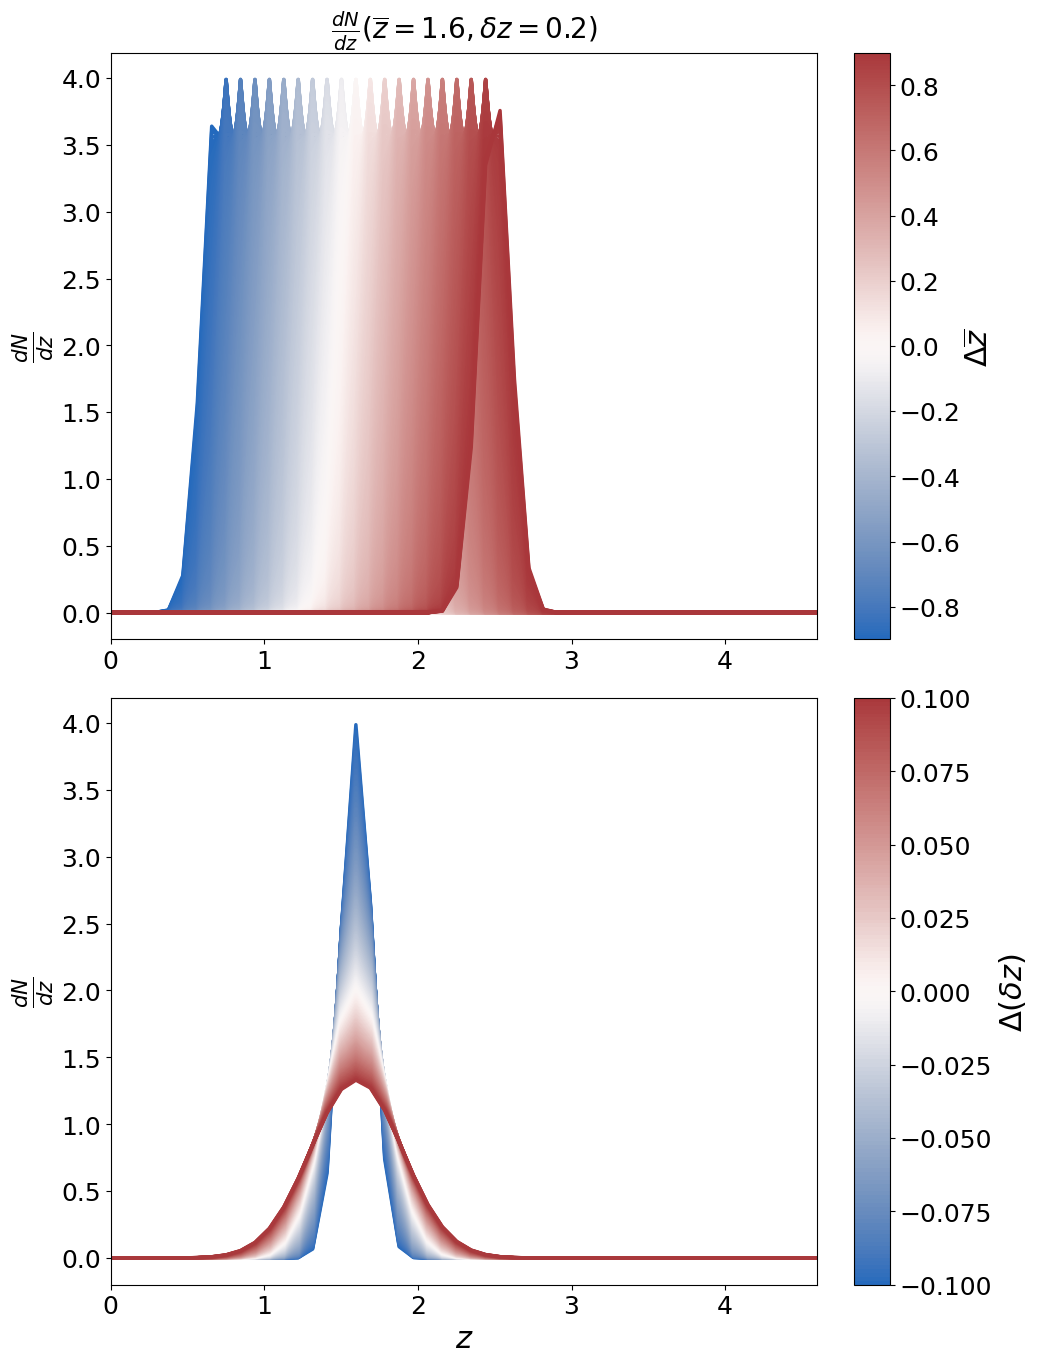

In [259]:
fig = plt.figure(figsize = (10.05, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0.1, hspace = 0.1, width_ratios = [1,0.05])
ax1 = fig.add_subplot(gs[0])

for k in range(len(sigma_z)):
    loc = z+delta*(-1+k/int(len(sigma_z)/2))
    dN_dz_norm = stats.norm.pdf(dz, loc=loc, scale=0.1)
    ax1.plot(dz, dN_dz_norm, linewidth = 2.5, color = cmap_z[k])
    
ax1.set_title(r'$\frac{{dN}}{{dz}}(\overline{{z}}={:.1f}, \delta z = {:.1f})$'.format(z, z_err))
# ax1.set_xlabel('$z$')
ax1.set_ylabel(r'$\frac{dN}{dz}$')
ax1.set_xlim(0, 4.6)
# plt.show()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_z, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), 
                    cax = fig.add_subplot(gs[0,-1]), label = '$\Delta \overline{z}$')

ax1 = fig.add_subplot(gs[2])

for k in range(len(sigma_dz_array)):
    scale = z_err+delta_dz*(-1+k/int(len(sigma_dz_array)/2))
    dN_dz_norm = stats.norm.pdf(dz, loc=z, scale=scale)
    ax1.plot(dz, dN_dz_norm, linewidth = 2.5, color = cmap_dz[k])

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'$\frac{dN}{dz}$')
ax1.set_xlim(0, 4.6)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_dz, norm = matplotlib.colors.Normalize(vmin=-delta_dz, vmax = delta_dz)), 
                    cax = fig.add_subplot(gs[1,-1]), label = '$\Delta (\delta z)$')
plt.show()


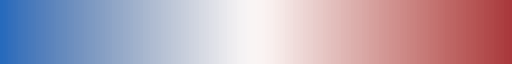

In [260]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

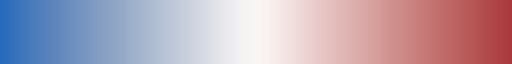

In [261]:
bins_scatter = np.logspace(9, M_max, 251)
cmap_M_min_scatter = sns.color_palette("vlag", n_colors = len(bins_scatter))
palette_M_min_scatter = matplotlib.colors.ListedColormap(cmap_M_min_scatter)
palette_M_min_scatter

In [262]:
sigma_k_array = np.linspace(0,1.4, 101)#51) #-4

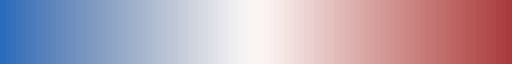

In [263]:
cmap_sigma = sns.color_palette("vlag", n_colors = len(sigma_k_array))
palette_sigma = matplotlib.colors.ListedColormap(cmap_sigma)
palette_sigma

In [264]:
alpha_k_array = np.linspace(0,3.6, 275)#301)#251)#01)#151)#101) #-4

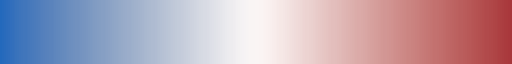

In [265]:
cmap_alpha= sns.color_palette("vlag", n_colors = len(alpha_k_array))
palette_alpha = matplotlib.colors.ListedColormap(cmap_alpha)
palette_alpha

<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:84: SyntaxWarning: invalid escape sequence '\D'
<>:123: SyntaxWarning: invalid escape sequence '\D'
<>:150: SyntaxWarning: invalid escape sequence '\D'
<>:184: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:84: SyntaxWarning: invalid escape sequence '\D'
<>:123: SyntaxWarning: invalid escape sequence '\D'
<>:150: SyntaxWarning: invalid escape sequence '\D'
<>:184: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2662/1551984210.py:59: SyntaxWarning: invalid escape sequence '\D'
  cax = fig.add_subplot(gs[0,2]), label = '$\Delta \overline{z}$')
/tmp/ipykernel_2662/1551984210.py:84: SyntaxWarning: invalid escape sequence '\D'
  cax = fig.add_subplot(gs[0,-1]), label = '$\Delta (\delta{z})$')
/tmp/ipykernel_2662/1551984210.py:123: SyntaxWarning: invalid escape sequence '\D'
  cax = fig.add_subplot(gs[1,2]), label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_2662/15

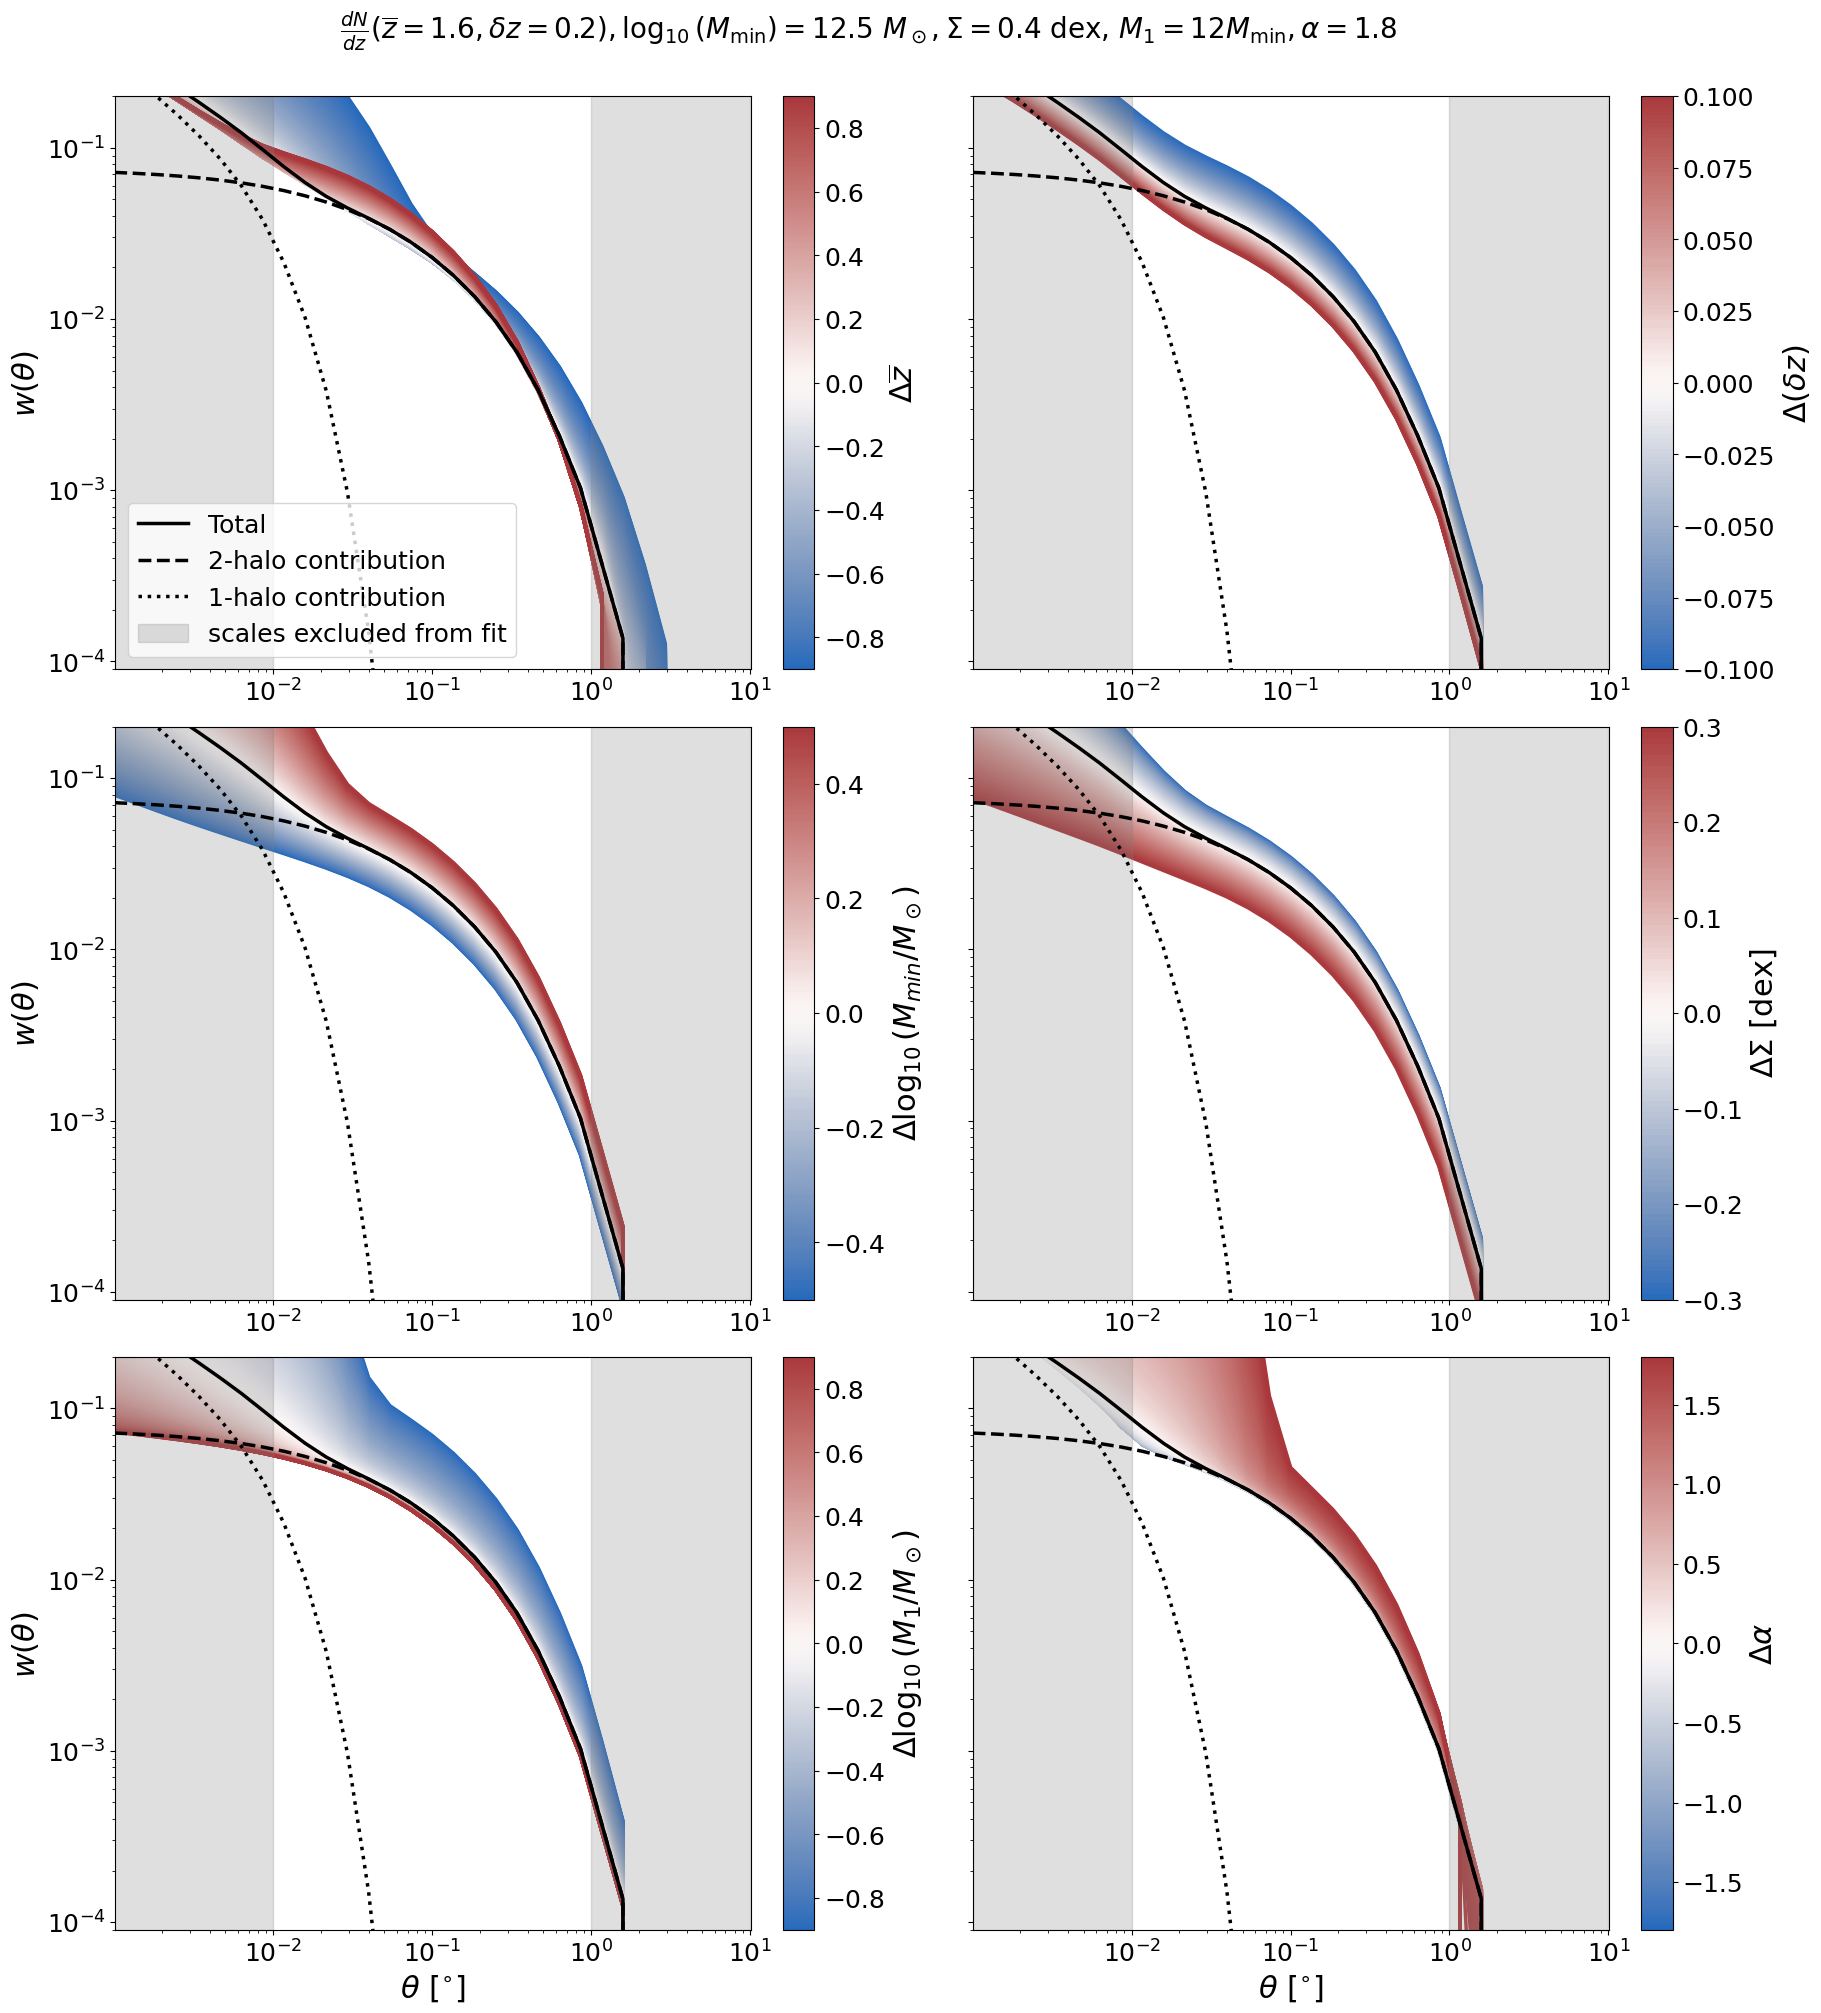

/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


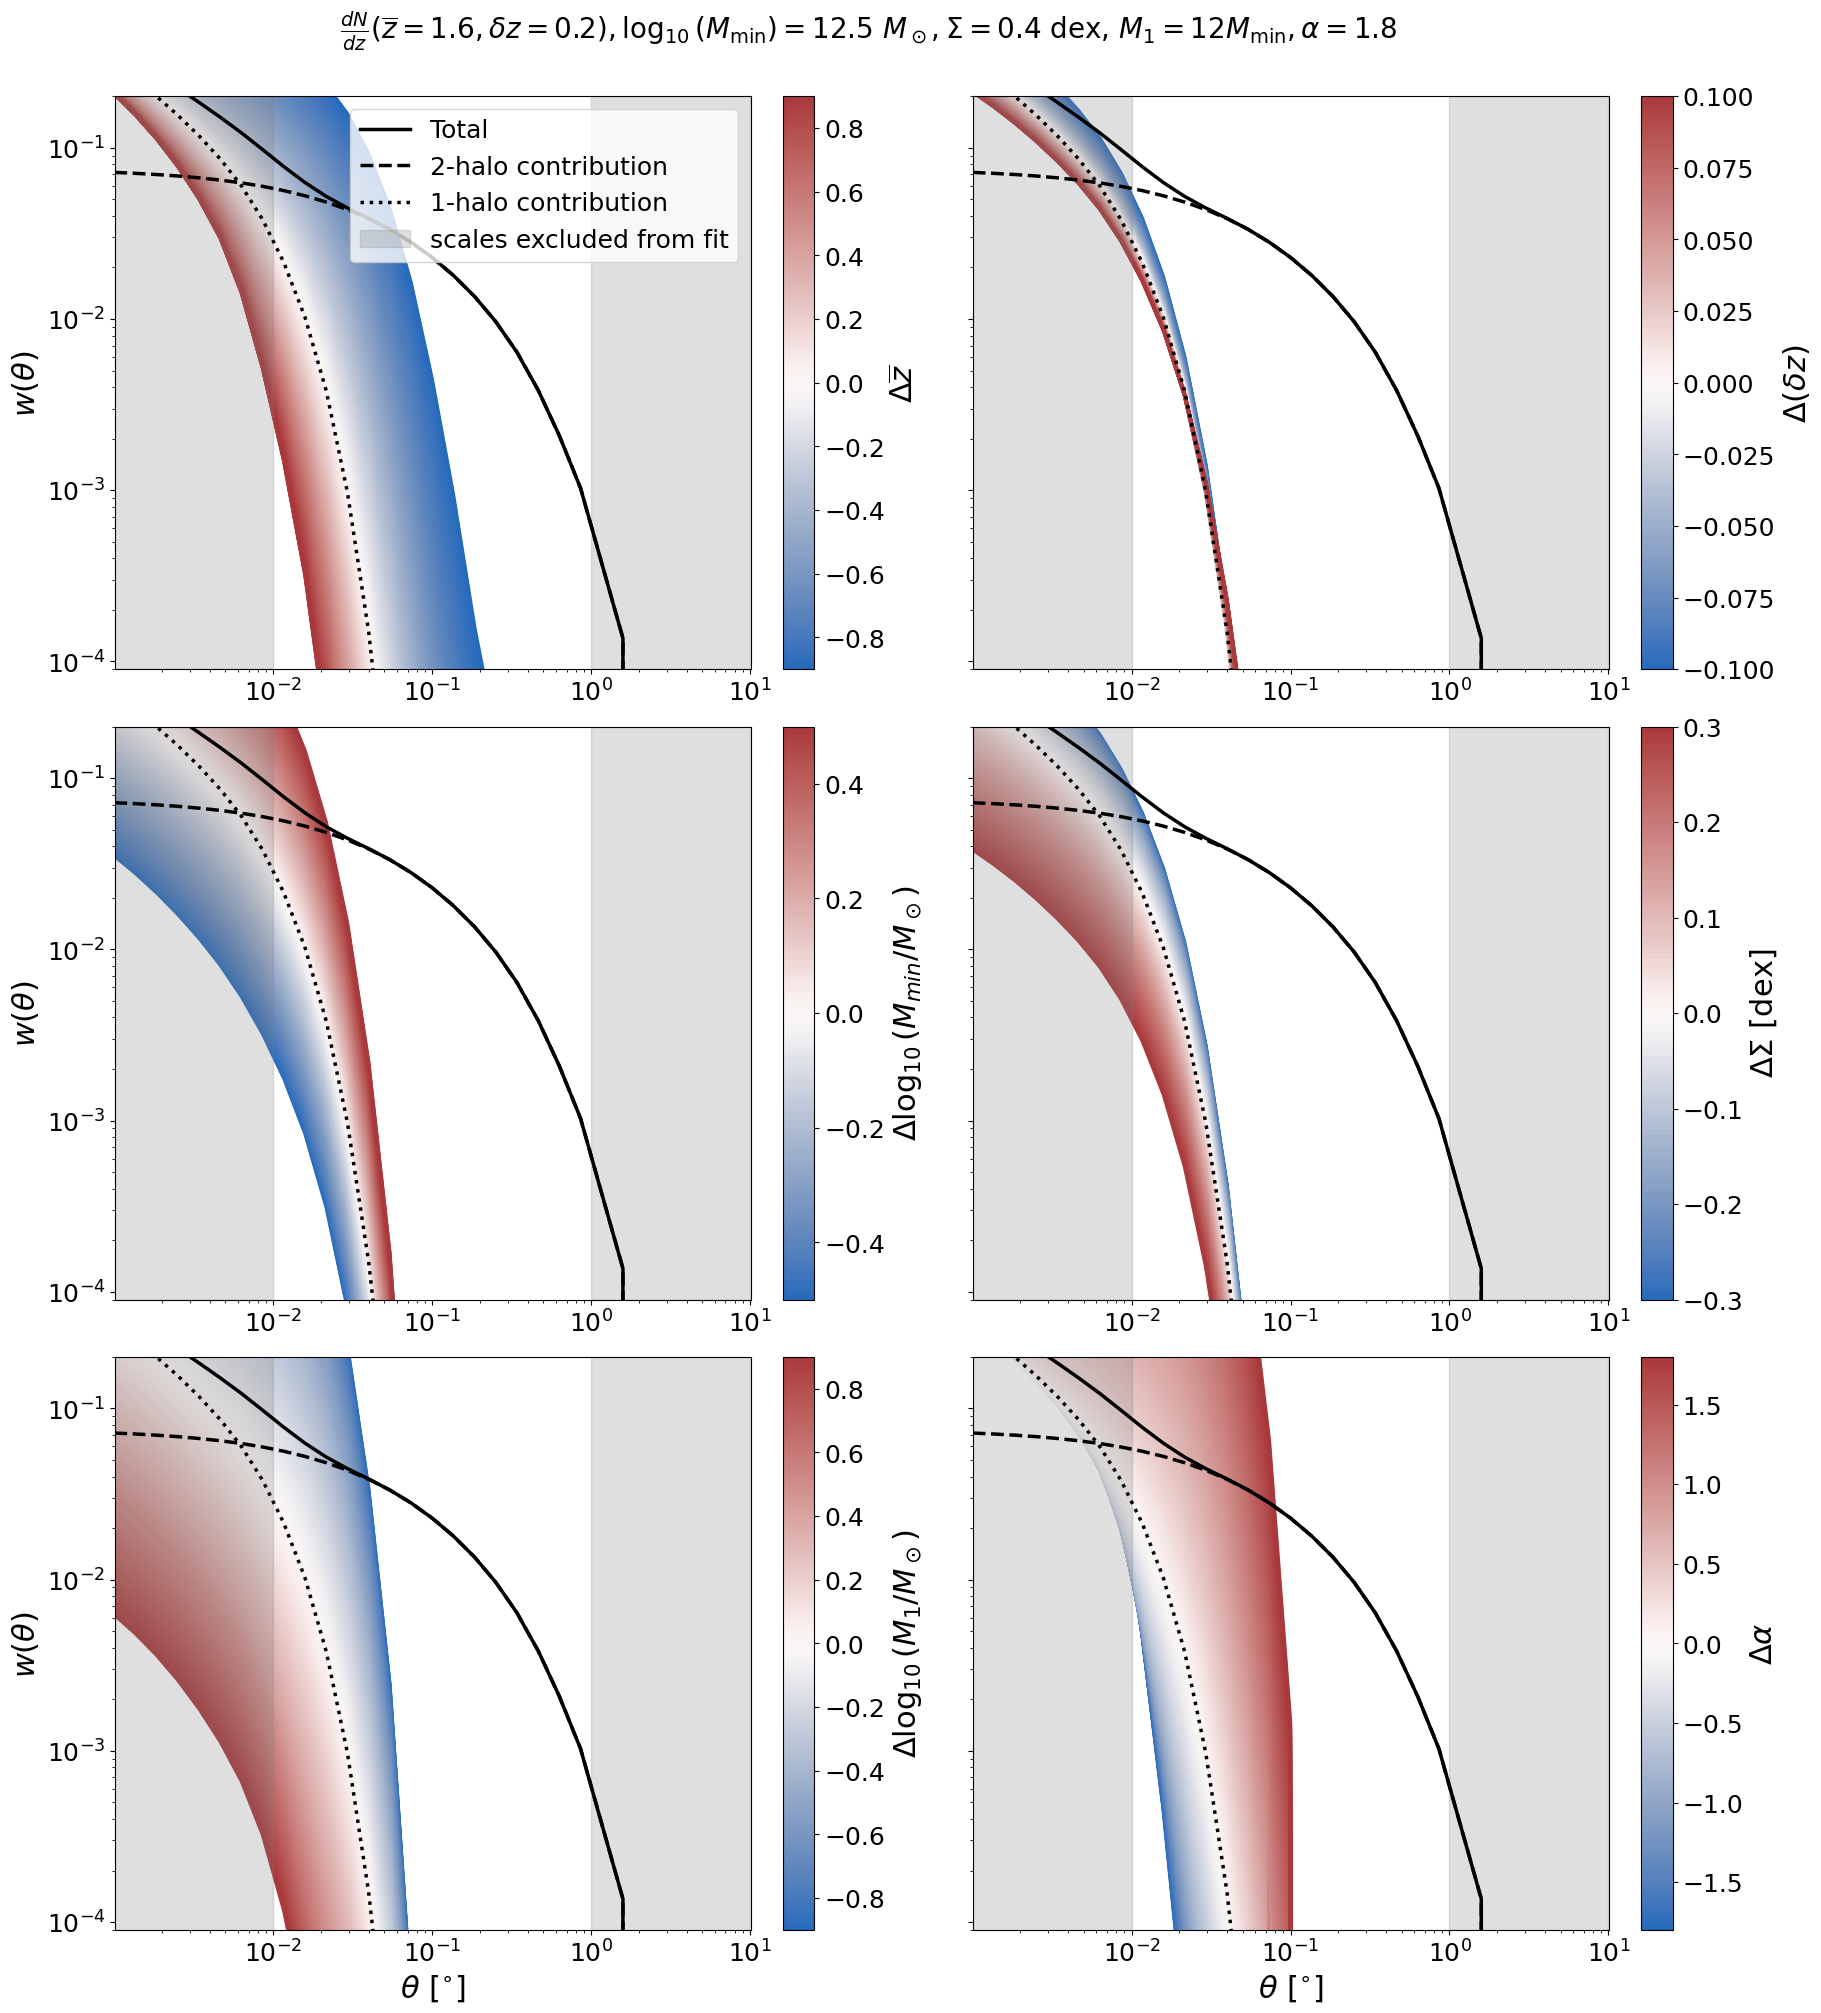

/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


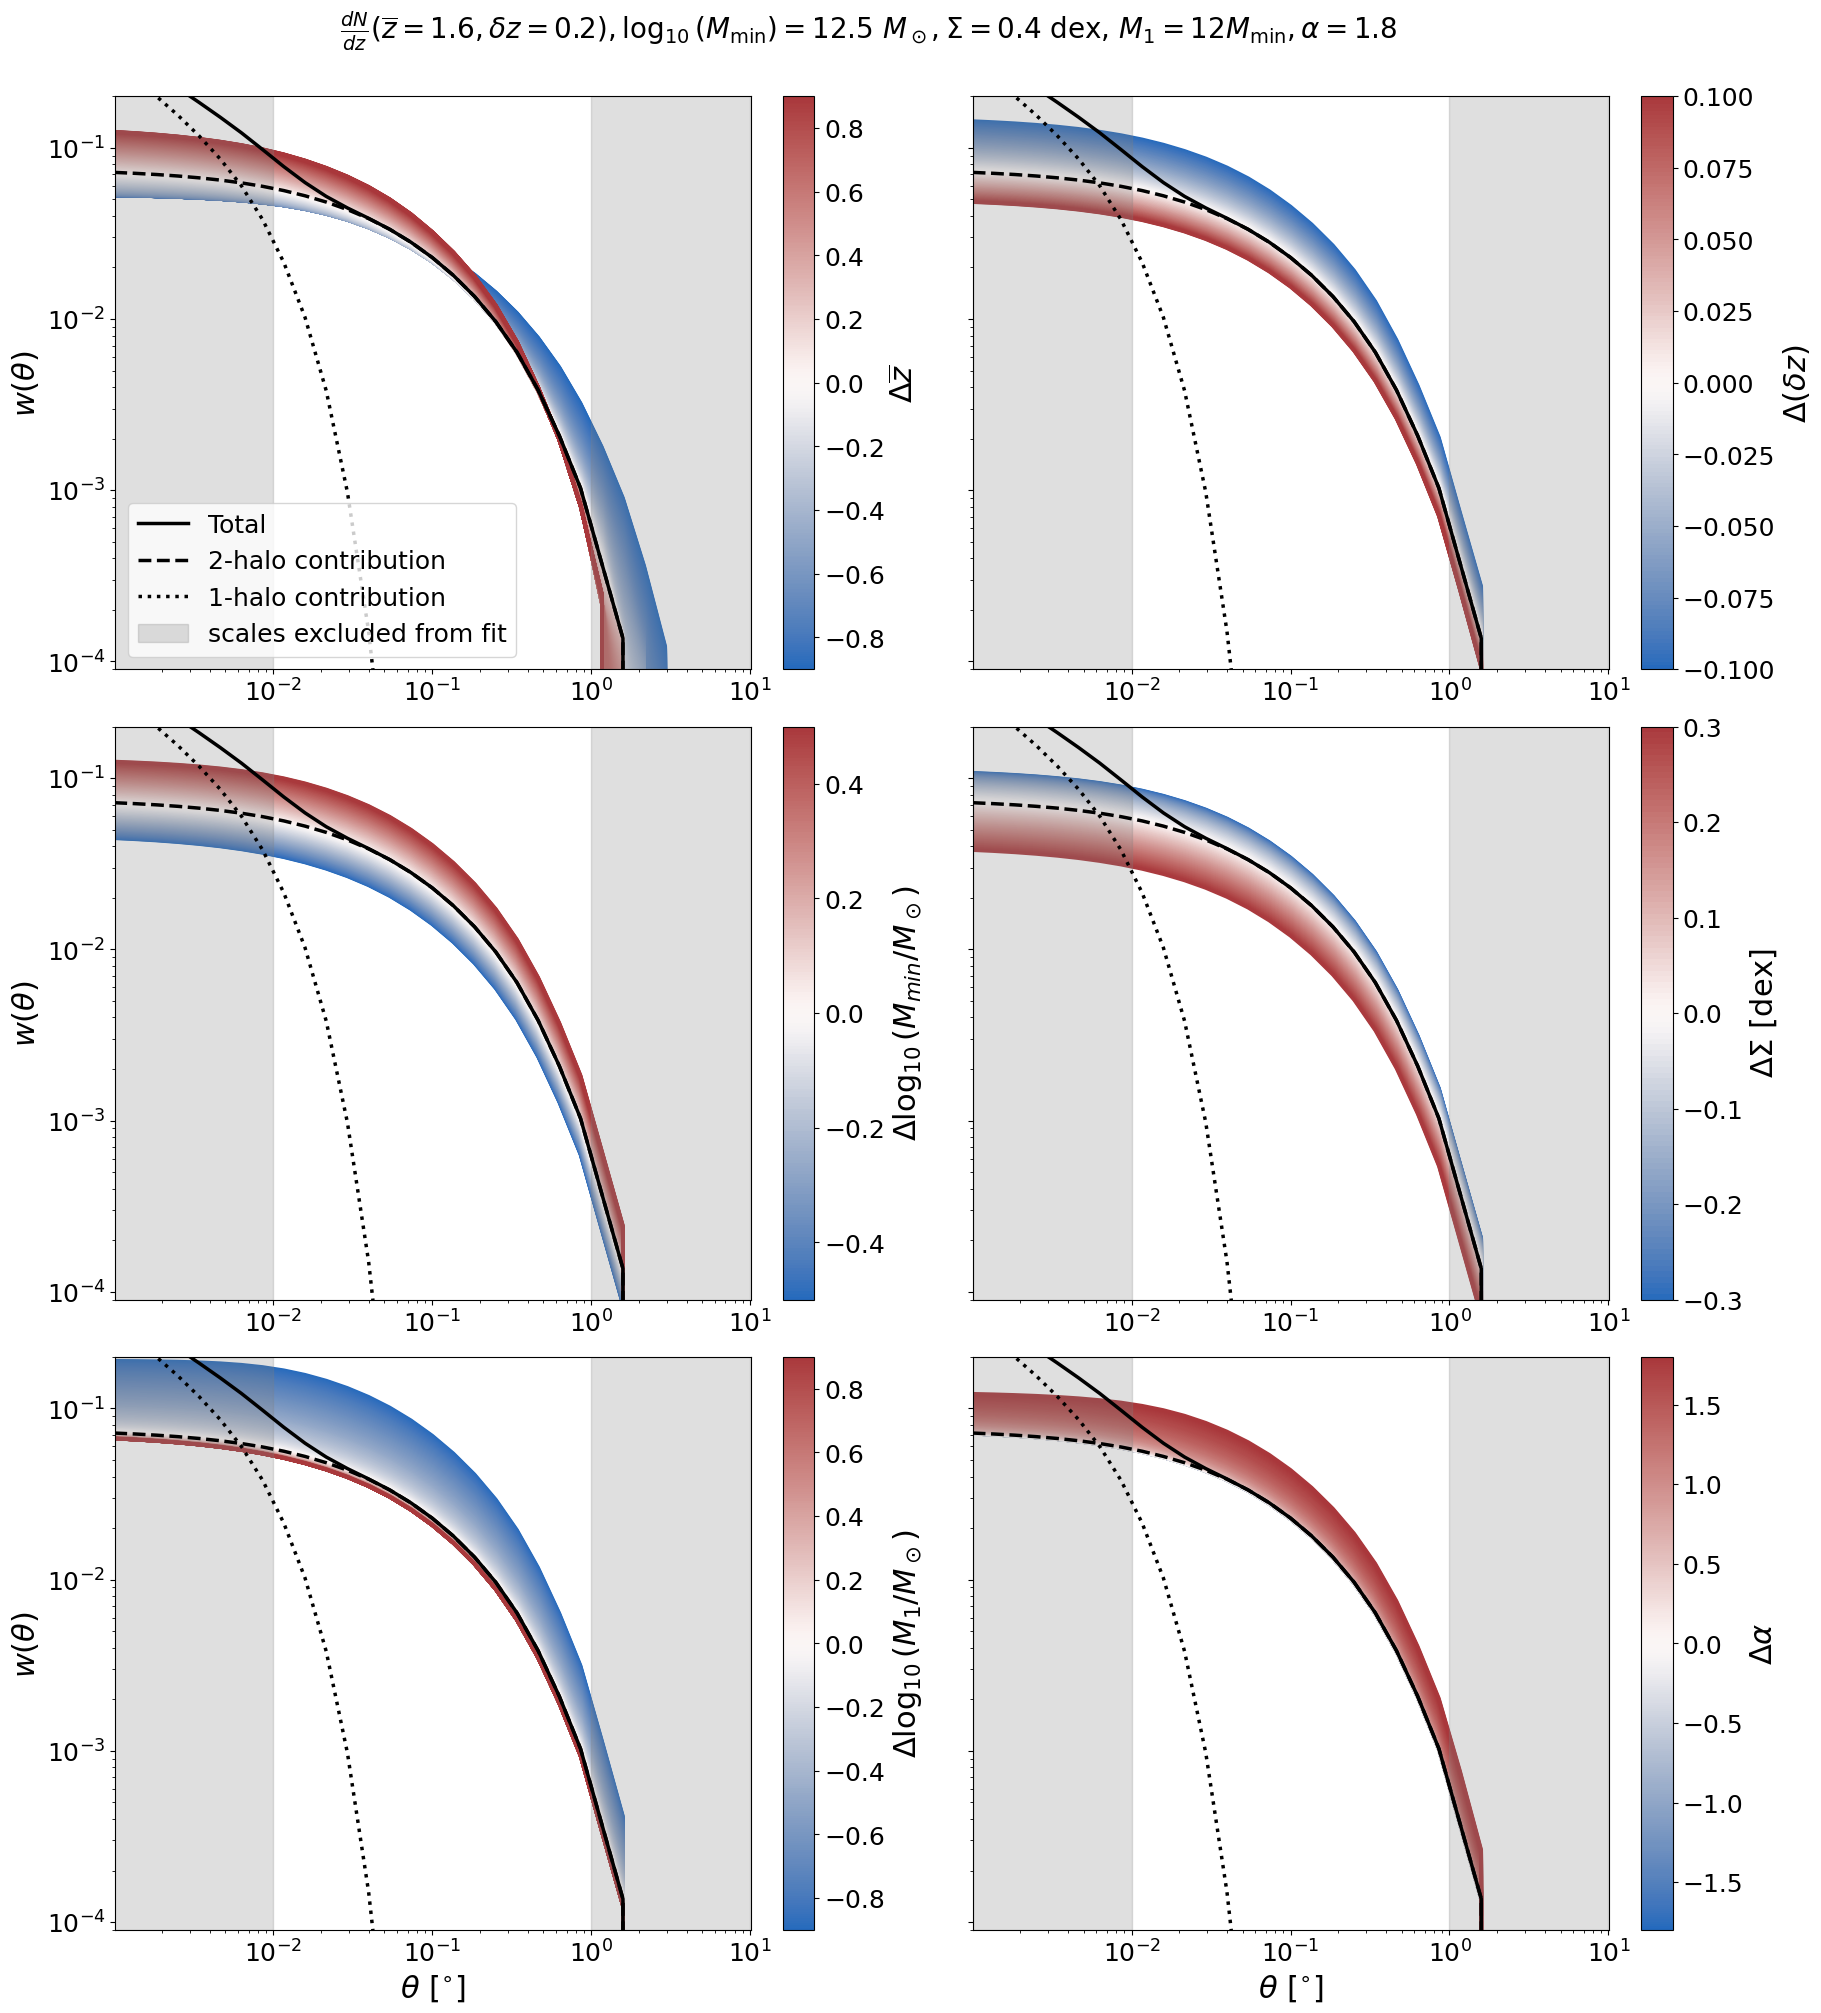

In [157]:
# remove bottom panel and just print bq somewhere
# plot!
ylim = 9e-5, 2e-1 #2e-5, 9e-1
y = np.linspace(ylim[0], ylim[-1])
alpha = 0.25
delta_Mmin = 0.5 #6
delta_M1 = 0.9 #1#.1 #1.05
log_fduty = -2
alpha_k = 1.8#9#2 #1.35
delta_alpha = alpha_k
two_halo = [True, False, True]
one_halo = [True, True, False]
delta_Sigma = 0.3

dN_dz_norm = stats.norm.pdf(dz, loc=z, scale=z_err)
H0_c_dN_dz_norm = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+z))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz_norm[k])**2 
                   for k in range(len(dz))]

wtheta_2h_P_baseline = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin, Sigma, M1, alpha_k])
wtheta_2h_P_2h_baseline = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin, Sigma, M1, alpha_k], one_halo = False)
wtheta_2h_P_1h_baseline = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin, Sigma, M1, alpha_k], two_halo = False)

for i in range(len(two_halo)):

    fig = plt.figure(figsize = (20.1, 32))
    gs = gridspec.GridSpec(4, 7, wspace = 0, hspace = 0.1, width_ratios = [1,0.05, 0.05, 0.25, 1, 0.05, 0.05])

    ax1 = fig.add_subplot(gs[0])
    
    ax1.plot(thetabins, wtheta_2h_P_baseline, linewidth = 2.5, color = 'k', zorder = 3, label = "Total")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_2h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = '--', label = "2-halo contribution")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_1h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = ':', label = "1-halo contribution")#bins_scatter

    for k in range(len(sigma_z)):
        
        loc = z+delta*(-1+k/int(len(sigma_z)/2))
        dN_dz_norm = stats.norm.pdf(dz, loc=loc, scale=z_err)
        H0_c_dN_dz_norm = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+loc))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz_norm[k])**2 
                           for k in range(len(dz))]
        
        wtheta_2h_P = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin, Sigma, M1, alpha_k], two_halo = two_halo[i], one_halo = one_halo[i])
        ax1.plot(thetabins, wtheta_2h_P, linewidth = 2.5, color = cmap_z[k], zorder = 0)#bins_scatter
    
    ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_ylim(ylim)
    
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = thetabins[0], x2 = 10**log_thetamin, color = 'grey', 
                          alpha = alpha, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = thetabins[-1], color = 'grey', 
                          alpha = alpha)
        
    ax1.set_ylabel(r"$w(\theta)$")
    ax1.legend()
    
    cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_z, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), 
                        cax = fig.add_subplot(gs[0,2]), label = '$\Delta \overline{z}$')
    
    ax1 = fig.add_subplot(gs[4])

    ax1.plot(thetabins, wtheta_2h_P_baseline, linewidth = 2.5, color = 'k', zorder = 3, label = "Total")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_2h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = '--', label = "2-halo contribution")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_1h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = ':', label = "1-halo contribution")
    
    for k in range(len(sigma_dz_array)):
        scale = z_err + delta_dz*(-1+k/int(len(sigma_dz_array)/2))
        dN_dz_norm = stats.norm.pdf(dz, loc=z, scale=scale)
        H0_c_dN_dz_norm = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+z))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz_norm[l])**2 #1/(1+loc) #k
                           for l in range(len(dz))]
    
        wtheta_2h_P = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin, Sigma, M1, alpha_k], two_halo = two_halo[i], one_halo = one_halo[i])
        
        ax1.plot(thetabins, wtheta_2h_P, linewidth = 2.5, color = cmap_dz[k], zorder=0)
    
    ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_ylim(ylim)
    ax1.set_yticklabels([])
    
    cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_dz, norm = matplotlib.colors.Normalize(vmin=-delta_dz, vmax = delta_dz)), 
                        cax = fig.add_subplot(gs[0,-1]), label = '$\Delta (\delta{z})$')
    
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = thetabins[0], x2 = 10**log_thetamin, color = 'grey', 
                          alpha = alpha, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = thetabins[-1], color = 'grey', 
                          alpha = alpha)
    
    
    ax1 = fig.add_subplot(gs[7])

    ax1.plot(thetabins, wtheta_2h_P_baseline, linewidth = 2.5, color = 'k', zorder = 3, label = "Total")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_2h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = '--', label = "2-halo contribution")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_1h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = ':', label = "1-halo contribution")
    
    for k in range(len(bins)):
        dN_dz_norm = stats.norm.pdf(dz, loc=z, scale=z_err)
        H0_c_dN_dz_norm = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+z))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz_norm[l])**2 
                           for l in range(len(dz))]
    
        Mmin_k = Mmin+delta_Mmin*(-1+k/int(len(bins)/2))
        wtheta_2h_P = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin_k, Sigma, M1, alpha_k], two_halo = two_halo[i], one_halo = one_halo[i]) #np.log10(12*10**M1)
    
        ax1.plot(thetabins, wtheta_2h_P, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) #cmap_M_min_scatter
    
    ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_ylim(ylim)
    
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = thetabins[0], x2 = 10**log_thetamin, color = 'grey', 
                          alpha = alpha, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = thetabins[-1], color = 'grey', 
                          alpha = alpha)
        
    ax1.set_ylabel(r"$w(\theta)$")
    
    cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-delta_Mmin, vmax = delta_Mmin)), 
                        cax = fig.add_subplot(gs[1,2]), label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
    
    ax1 = fig.add_subplot(gs[11])

    ax1.plot(thetabins, wtheta_2h_P_baseline, linewidth = 2.5, color = 'k', zorder = 3, label = "Total")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_2h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = '--', label = "2-halo contribution")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_1h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = ':', label = "1-halo contribution")
    
    for k in range(len(sigma_k_array)):
    
        dN_dz_norm = stats.norm.pdf(dz, loc=z, scale=z_err)
        H0_c_dN_dz_norm = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+z))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz_norm[l])**2 
                           for l in range(len(dz))]
    
        wtheta_2h_P = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin, Sigma+delta_Sigma*(-1+k/int(len(sigma_k_array)/2)), M1, 
                                                                                       alpha_k], two_halo = two_halo[i], one_halo = one_halo[i])
        
        ax1.plot(thetabins, wtheta_2h_P, linewidth = 2.5, color = cmap_sigma[k], zorder = 0)
    
    ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_ylim(ylim)
    
    ax1.set_yticklabels([])
    
    cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta_Sigma, vmax = delta_Sigma)), 
                        cax = fig.add_subplot(gs[1,-1]), label =  '$\Delta \Sigma$ [dex]')
    
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = thetabins[0], x2 = 10**log_thetamin, color = 'grey', 
                          alpha = alpha, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = thetabins[-1], color = 'grey', 
                          alpha = alpha)
    
    ax1 = fig.add_subplot(gs[14])

    ax1.plot(thetabins, wtheta_2h_P_baseline, linewidth = 2.5, color = 'k', zorder = 3, label = "Total")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_2h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = '--', label = "2-halo contribution")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_1h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = ':', label = "1-halo contribution")
    
    for k in range(len(bins_scatter)):
    
        dN_dz_norm = stats.norm.pdf(dz, loc=z, scale=z_err)
        H0_c_dN_dz_norm = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+z))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz_norm[l])**2 
                           for l in range(len(dz))]
    
        Mmin_k = M1+delta_M1*(-1+k/int(len(bins_scatter)/2))
        wtheta_2h_P = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin, Sigma, Mmin_k, alpha_k], two_halo = two_halo[i], one_halo = one_halo[i])
        
        ax1.plot(thetabins, wtheta_2h_P, linewidth = 2.5, color = cmap_M_min_scatter[k], zorder = 0)
    
    ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_ylim(ylim)
    
    ax1.set_ylabel(r"$w(\theta)$")
    ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
    
    cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min_scatter, norm = matplotlib.colors.Normalize(vmin=-delta_M1, vmax = delta_M1)), 
                        cax = fig.add_subplot(gs[2,2]), label =  '$\Delta \log_{10}(M_1/M_\odot)$')
    
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = thetabins[0], x2 = 10**log_thetamin, color = 'grey', 
                          alpha = alpha, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = thetabins[-1], color = 'grey', 
                          alpha = alpha)
        
    ax1 = fig.add_subplot(gs[18])

    ax1.plot(thetabins, wtheta_2h_P_baseline, linewidth = 2.5, color = 'k', zorder = 3, label = "Total")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_2h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = '--', label = "2-halo contribution")#bins_scatter
    ax1.plot(thetabins, wtheta_2h_P_1h_baseline, linewidth = 2.5, color = 'k', zorder = 3, linestyle = ':', label = "1-halo contribution")
    
    for k in range(len(alpha_k_array)):
    
        dN_dz_norm = stats.norm.pdf(dz, loc=z, scale=z_err)
        H0_c_dN_dz_norm = [ccl.background.h_over_h0(cosmo_planck18, 1/(1+z))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*(dN_dz_norm[l])**2 
                           for l in range(len(dz))]
    
        wtheta_2h_P = wtheta_2h_optimized(bins, H0_c_dN_dz_norm, params_HOD = [log_fduty, Mmin, Sigma, M1, alpha_k+delta_alpha*(-1+k/int(len(alpha_k_array)/2))], two_halo = two_halo[i], one_halo = one_halo[i])
        
        ax1.plot(thetabins, wtheta_2h_P, linewidth = 2.5, color = cmap_alpha[k], zorder = 0)
    
    ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_ylim(ylim)
    
    ax1.set_yticklabels([])
    ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 
    
    cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_alpha, norm = matplotlib.colors.Normalize(vmin=-delta_alpha, vmax = delta_alpha)), 
                        cax = fig.add_subplot(gs[2,-1]), label =  r'$\Delta \alpha$')
    
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = thetabins[0], x2 = 10**log_thetamin, color = 'grey', 
                          alpha = alpha, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = thetabins[-1], color = 'grey', 
                          alpha = alpha)
        
    plt.suptitle(rf'''$\frac{{dN}}{{dz}}(\overline{{z}}={z:.1f}, \delta z = {z_err:.1f}),\log_{{10}}(M_\mathrm{{min}})={Mmin:.1f}$ $M_\odot,'''
                 +rf''' \Sigma={Sigma}$ dex, $M_1=12 M_\mathrm{{min}}, \alpha = {alpha_k}$''', fontsize = 20, y = 0.907175)
    
    plt.show()
    plt.close(fig)

# Perform nested sampling with dynesty

In [266]:
# Define the dimensionality of our problem.
ndim = 3

In [267]:
diag = False #True # False

In [300]:
# create classes
class CholeskySolver:
    def __init__(self, C_factor):
        self.C_factor = C_factor
    def __call__(self, rhs):
        return linalg.cho_solve(self.C_factor, rhs)

class LUSolver:
    def __init__(self, C_factor):
        self.C_factor = C_factor
    def __call__(self, rhs):
        return linalg.lu_solve(self.C_factor, rhs)

In [302]:
# Define our 3-D correlated multivariate normal log-likelihood.
C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
if diag == True:
    C*=np.identity(len(C))
ix_grid = np.ix_(theta_mask, theta_mask)
hartlap = (N-nbins-2)/(N-1)
print(hartlap)

def log_det(C, ix_grid):  
    
    # check if cov is hermitian and positive definite
    if linalg.ishermitian(C[ix_grid]) and np.all(np.linalg.eigvals(C[ix_grid]) > 0):
        C_factor = linalg.cho_factor(C[ix_grid])
        log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
        solve = CholeskySolver(C_factor) #lambda rhs: linalg.cho_solve(C_factor, rhs)
    else:
        print('using LU decomposition')
        C_factor = linalg.lu_factor(C[ix_grid])
        log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
        # solve = lambda rhs: linalg.lu_solve(C_factor, rhs)
        solve = LUSolver(C_factor)

    return log_det_C, solve
        
log_det_C, solve = log_det(C, ix_grid)

def loglike(x, log_det_C, wp, nbins, solve, dN_dz, theta_mask = theta_mask, M_max = M_max, N = N, fduty = 0, recenter_thetabins = True, n_bins = n_bins, bins_m = bins):
    
    M_min, Alpha, sigma = x
    
    # bins_m = np.logspace(M_min, M_max, n_bins)
    
    wp_2h_zbin = wtheta_2h_dynesty(bins_m, dN_dz, params_HOD = [0, M_min, sigma, np.log10(12*10**M_min), Alpha])
    # wp_2h_zbin = wtheta_2h_optimized(bins_m, dN_dz, params_HOD = [0, M_min, sigma, np.log10(12*10**M_min), Alpha], theta_mask = theta_mask, recenter_thetabins = recenter_thetabins)

    delta = wp-wp_2h_zbin
    
    c_p = gamma(N/2)/((np.pi*(N-1))**(nbins/2)*gamma((N-nbins)/2))
    lnorm = np.log(c_p)-0.5*log_det_C  

    return -N*0.5 * np.log(1+(delta.T @ solve(delta))/(N-1)) + lnorm #- penalty

0.3673469387755102


In [270]:
np.log10(12*10**15), M_max #either do Mmin: 0,15 and M1: 1,60 (can't be 0) or Mmin=M1:9,16

(16.079181246047625, 16.8)

In [271]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 

    # Uniform from 9 to 16
    x[0] = 7 * u[0] + 9  # scale and shift to [9., 16.)

    # Uniform from 0 to 4
    x[1] = 4 * u[1]  # scale and shift to [0, 4.)

    # Uniform from 1 to 60
    x[2] = 1.4 * u[2]   # scale and shift to [0, 1.4.)

    return x

In [272]:
nlive = 1000 #500 #3000 #500
dlogz = 0.01

In [273]:
i, j = 0, 1
nbins_mask = np.sum(theta_mask)
nbins, np.sum(theta_mask), len(wp_chi2[L_bins[i]][j][theta_mask]), len(wp_chi2[L_bins[i]][j])

(30, 16, 16, 30)

In [305]:
x_test = np.array([12.0, 0.9, Sigma])  # test M_min
start = time.time()
result = loglike(x_test, log_det_C, wp_chi2[L_bins[i]][j][theta_mask], nbins_mask, solve, H0_c_dN_dz_array) #H0_c_dN_dz)
print(f"Time: {time.time()-start:.2f}s")

print(result)

/tmp/ipykernel_27189/1223723193.py:82: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


Time: 0.33s
40.593103115309724


In [306]:
from dynesty.pool import Pool

with Pool(1, loglike, ptform, logl_args=[log_det_C, wp_chi2[L_bins[i]][j][theta_mask], np.sum(theta_mask), solve, H0_c_dN_dz_array], ptform_args=[ndim]) as pool:
    print([a for a in dir(pool) if 'log' in a.lower()])

['logl_args', 'logl_kwargs', 'loglike', 'loglike_0']


In [166]:
# initialize our nested sampler
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[log_det_C, wp_chi2[L_bins[i]][j][theta_mask], np.sum(theta_mask), solve, H0_c_dN_dz_array],#dN_dz/norm], 
                        nlive = nlive, rstate=np.random.default_rng(0))#, logl_kwargs = {'theta_mask': theta_mask})

/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


In [167]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = dlogz)
results = sampler.results

0it [00:00, ?it/s]/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
3619it [3:23:58, 12.87s/it, bound: 1 | nc: 15 | ncall: 36263 | eff(%):  9.980 | loglstar:   -inf < 52.812 <    inf | logz: 49.894 +/-  0.045 | dlogz:  0.593 >  0.010] /tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
3945it [3:29:46,  1.45s/it, bound: 2 | nc: 5 | ncall: 37264 | eff(%): 10.587 | loglstar:   -inf < 52.868 <    inf | logz: 50.027 +/-  0.045 | dlogz:  0.416 >  0.010] /tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
4109it [3:35:39,  5.36s/it, bound: 3 | nc: 28 | ncall: 38275 | eff(%): 10.735 | loglstar:   -inf < 52.888 <    inf | logz: 50.077 +/-  0.045 | dlogz:  0.348 >  0.010]/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((b

In [168]:
# Print out a summary of the results.
results.summary()

Summary
nlive: 1000
niter: 7584
ncall: 55804
eff(%): 15.382
logz: 50.338 +/-  0.046


<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2662/488143463.py:3: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)


Text(0.5, 0.9, '$M_i\\geq-20.0, 1.0<z \\leq2.0$')

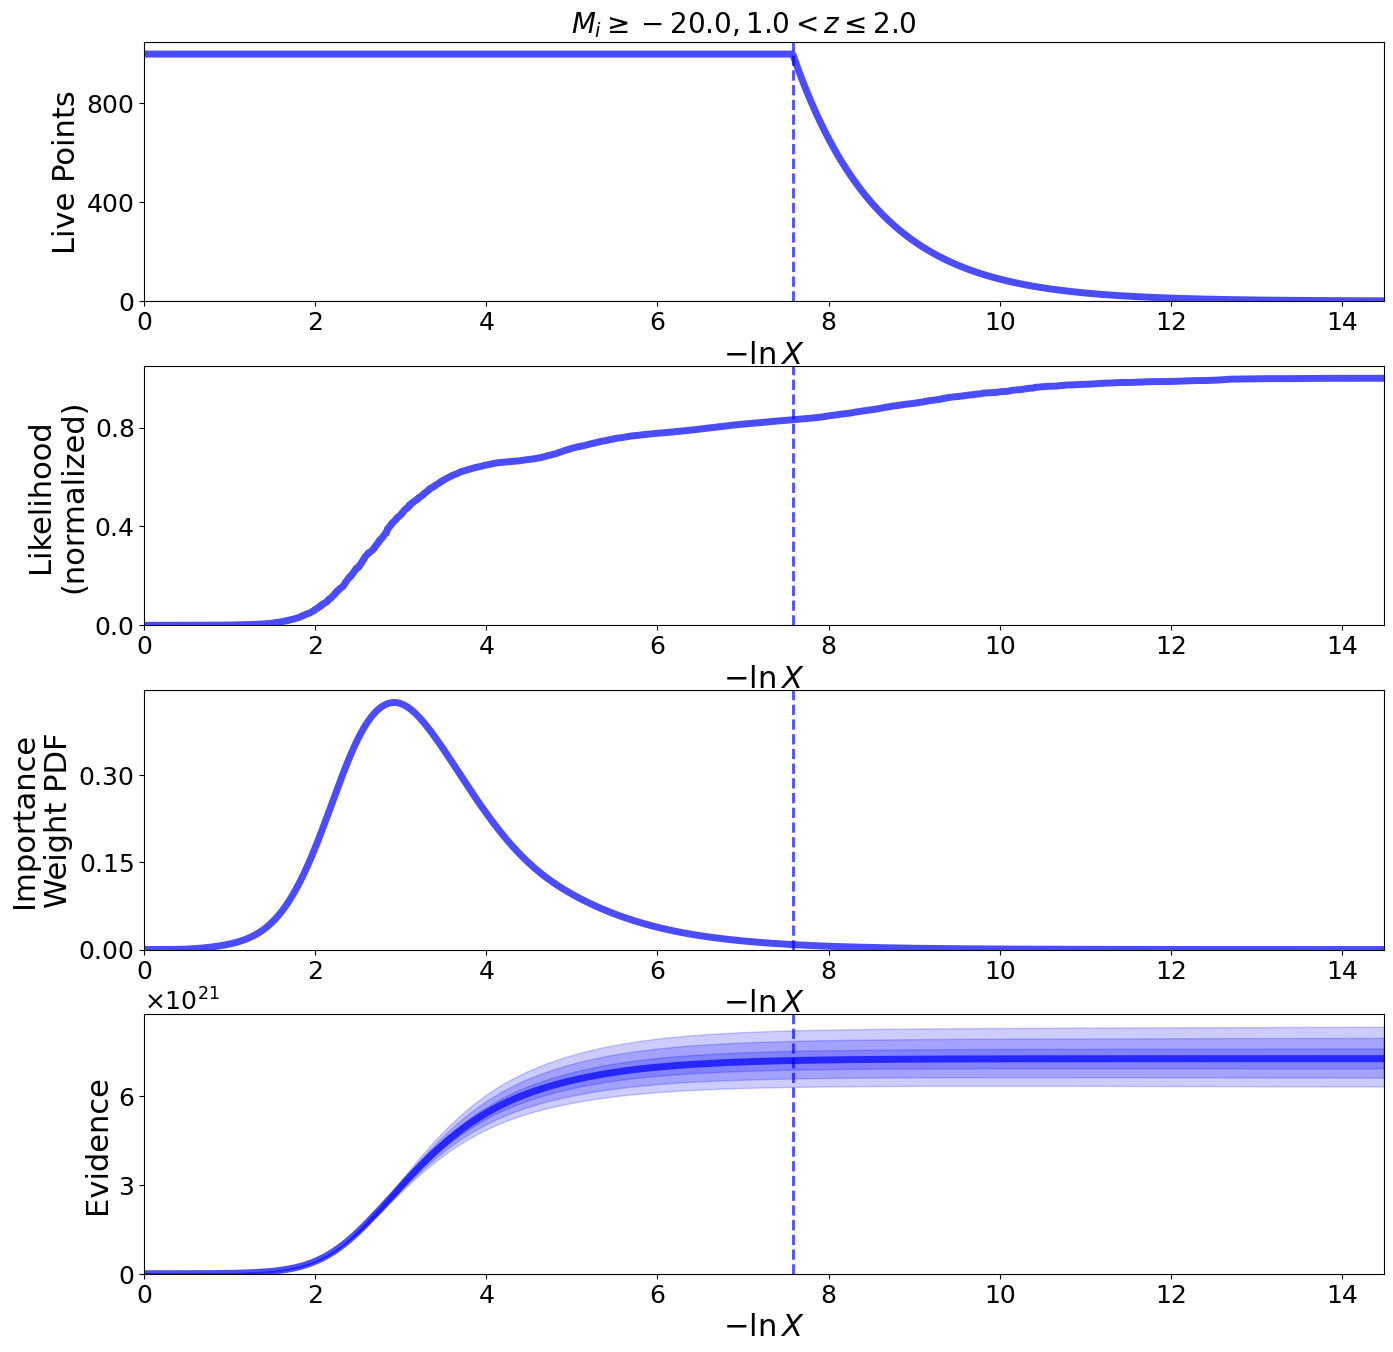

In [169]:
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)

In [170]:
quantile = [0.16, 0.5, 0.84]

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2662/1710763931.py:7: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)


Text(0.5, 1, '$M_i\\geq-20.0, 1.0<z \\leq2.0$')

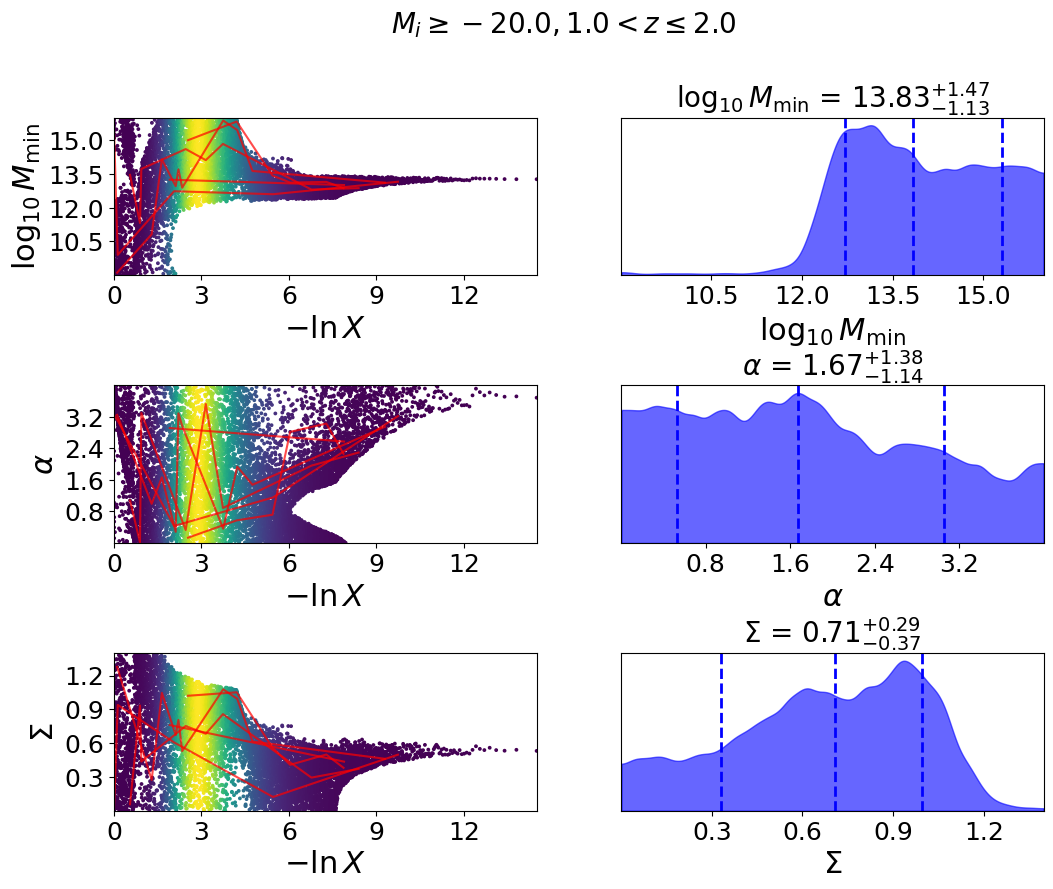

In [171]:
labels=[r'$\log_{10} M_\mathrm{min}$', r'$\alpha$', r'$\Sigma$']
fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=labels, quantiles = quantile, title_quantiles = quantile)
fig.subplots_adjust(hspace=0.7)
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2662/38536895.py:7: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.975, x = 0.575)


Text(0.575, 0.975, '$M_i\\geq-20.0, 1.0<z \\leq2.0$')

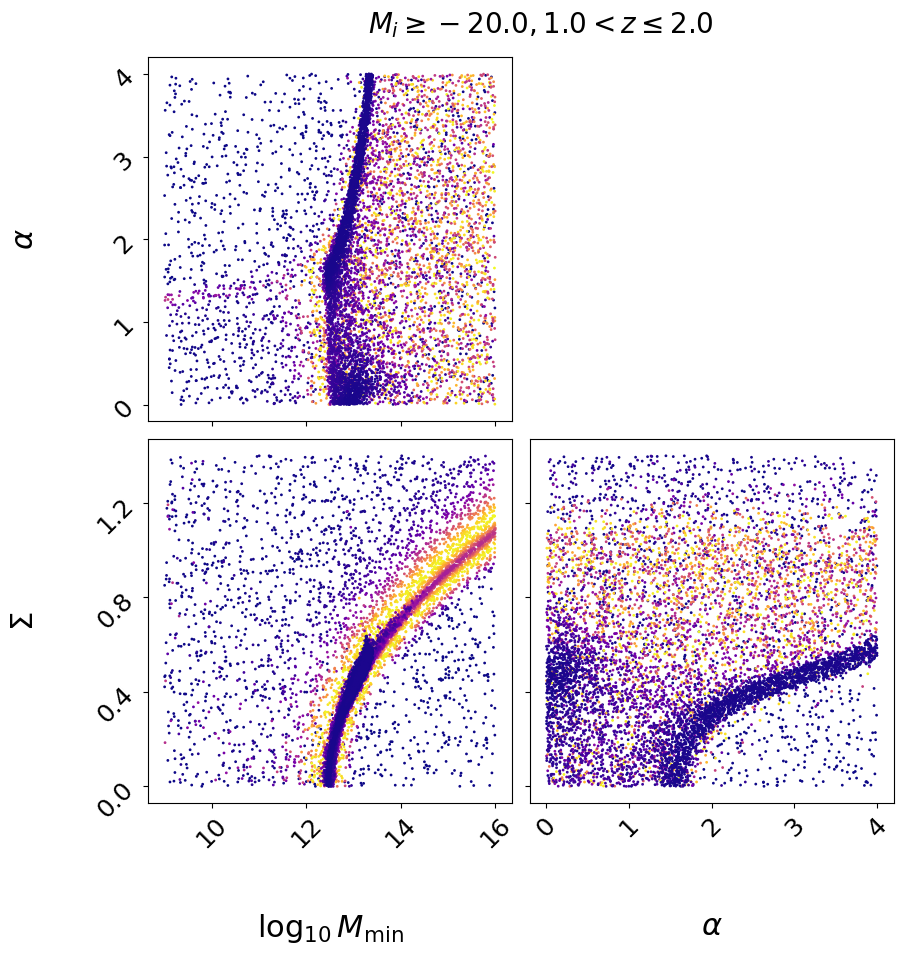

In [172]:
# initialize figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# plot initial run (res1; left)
fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                             kde=False, labels=labels, fig=(fig, axes))
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.975, x = 0.575)

In [173]:
quantile_2d = 1.0 - np.exp(-0.5 * np.array([1, 2])**2)#, 3])**2)
quantile_2d

array([0.39346934, 0.86466472])

In [174]:
def make_contour_cmap(color, n_levels, alpha_min=0, alpha_max=1.0):
    
    cmap = []
    alphas = np.linspace(0,1,n_levels+1)
    for alpha in alphas:
        rgba = np.array(mcolors.to_rgba(color))
        rgba[-1] = alpha
        cmap.append(rgba)

    return cmap

In [175]:
contourf_kwargs = {'colors': make_contour_cmap('blue', len(quantile))}

<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:8: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2662/3455366437.py:8: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)


Text(0.375, 1, '$M_i\\geq-20.0, 1.0<z \\leq2.0$')

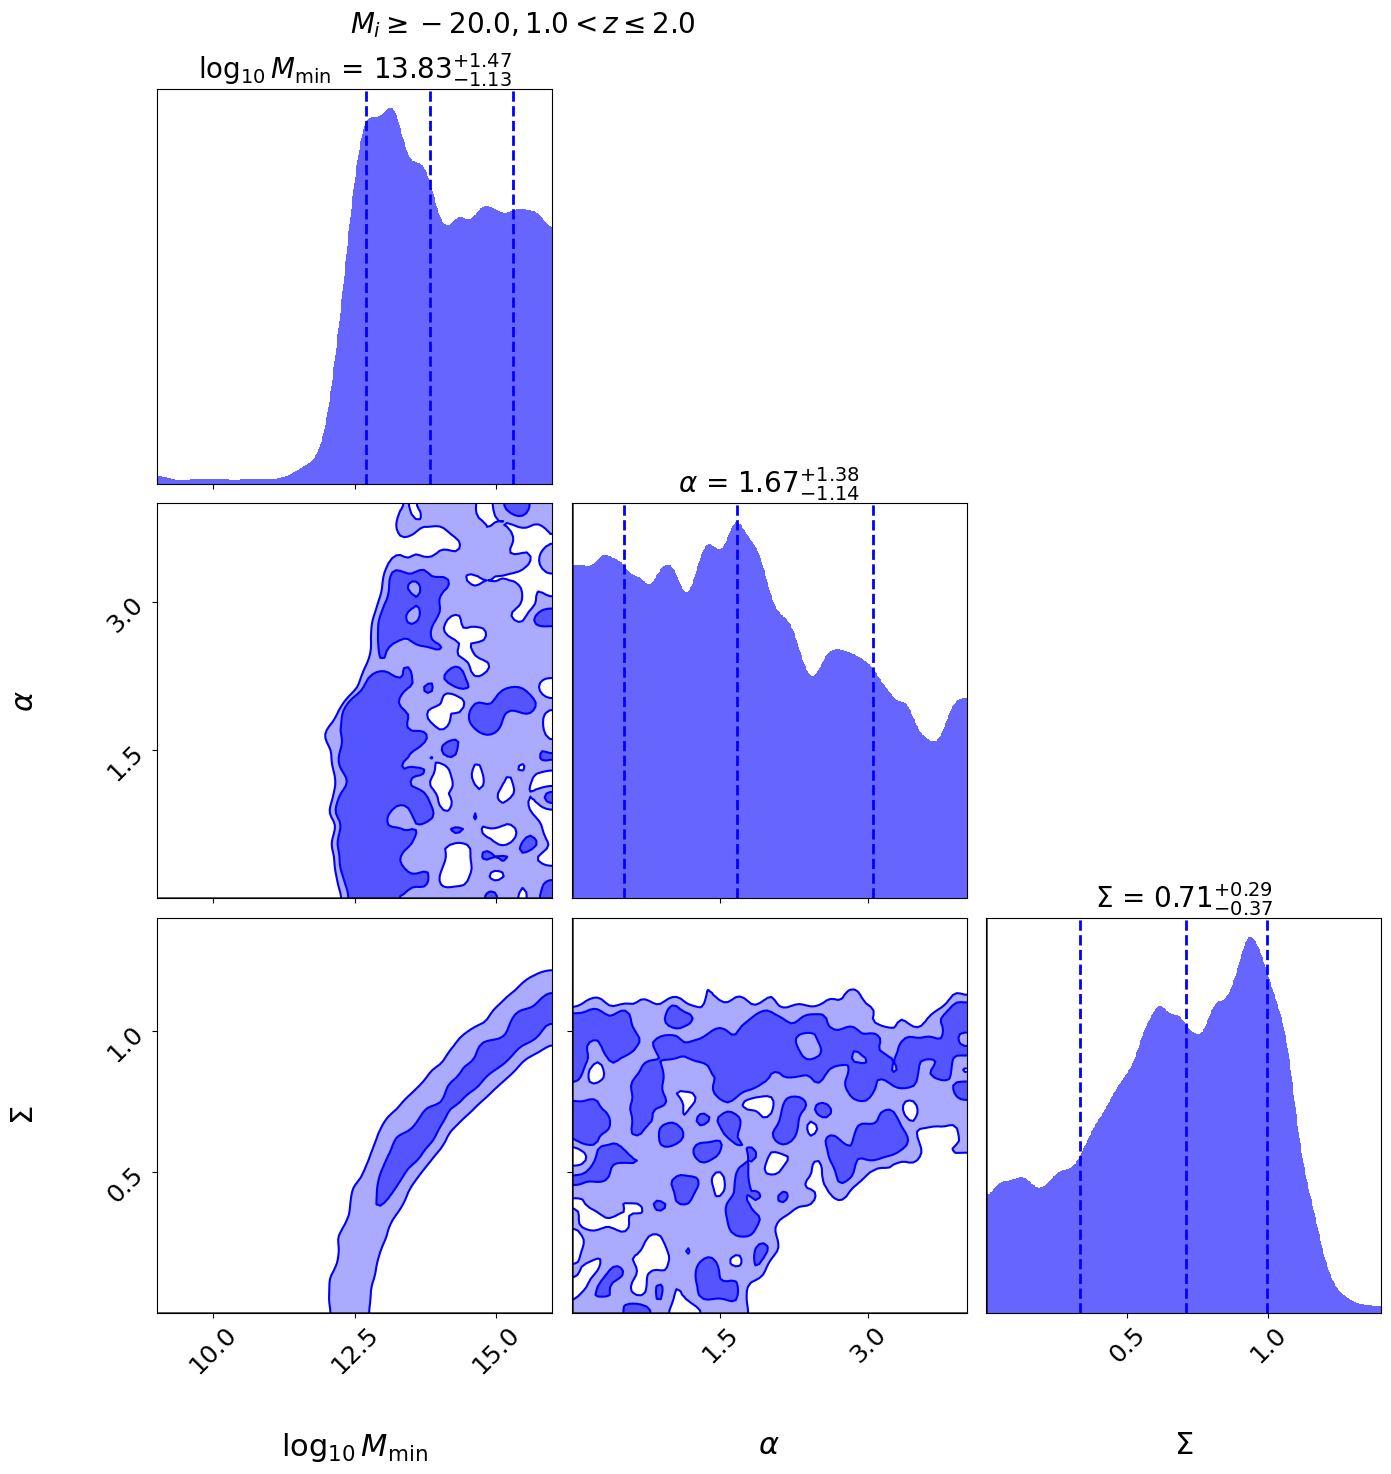

In [176]:
# # initialize figure
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim), hist2d_kwargs = {'contourf_kwargs': contourf_kwargs}, #hist2d_kwargs,
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=quantile, quantiles_2d = quantile_2d, title_quantiles = quantile, labels=labels, fig=(fig, axes[:, :3]))
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)

In [177]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

[13.93018584  1.76406051  0.67716439] [[1.38209337 0.31954051 0.31443294]
 [0.31954051 1.19887196 0.0869604 ]
 [0.31443294 0.0869604  0.09386344]]


In [178]:
# Compute weighted quantiles

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], quantile, weights=weights) 
             for i in range(samples.shape[1])]

for k, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[k]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

$\log_{10} M_\mathrm{min}$: 13.83 + 1.47/-1.13
$\alpha$: 1.67 + 1.38/-1.14
$\Sigma$: 0.71 + 0.29/-0.37


In [179]:
equal_weight_samples_i = dyfunc.resample_equal(samples, weights)

## Try fitting $f_{duty}$

In [180]:
labels_fduty = [r'$\log_{10} f_\mathrm{duty}$']

In [181]:
# bins_m = np.logspace(equal_weight_samples_i[:,0], M_max, n_bins)
i, j = 0, 1
n_dm = []
for k in range(len(equal_weight_samples_i[:,0])):

    n_c=N_c(bins, equal_weight_samples_i[:,0][k], 1, sigma = equal_weight_samples_i[:,2][k])
    n_s = N_s(bins, 1, 10**equal_weight_samples_i[:,0][k], 12*10**equal_weight_samples_i[:,0][k], equal_weight_samples_i[:,1][k])
    n_m = n_c+n_s

    n_dm.append(M(bins, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1].value) #[:,0]
    
equal_weight_samples_fduty = np.log10(n_q[L_bins[i]][j]/n_dm)

/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


In [182]:
# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
lo, mid, hi = dyfunc.quantile(equal_weight_samples_fduty, quantile) 

# for i, (lo, mid, hi) in enumerate(quantiles):
print(f"{labels_fduty[0]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

$\log_{10} f_\mathrm{duty}$: -1.32 + 1.00/-0.87


In [183]:
results_fduty = Results({
    'samples': equal_weight_samples_fduty,
    'logwt': np.zeros(len(equal_weight_samples_fduty)),#results['logwt'],          # equal weights -> uniform log weights
    'logz': np.array([0.0]),
    'logzerr': np.array([0.0]),
    'logl': results['logl'],
    'nlive': nlive,
    'samples_u': results['samples_u'],
    'samples_id': results['samples_id']
})

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2662/4037935091.py:7: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1.05, x = 0.6)


Text(0.6, 1.05, '$M_i\\geq-20.0, 1.0<z \\leq2.0$')

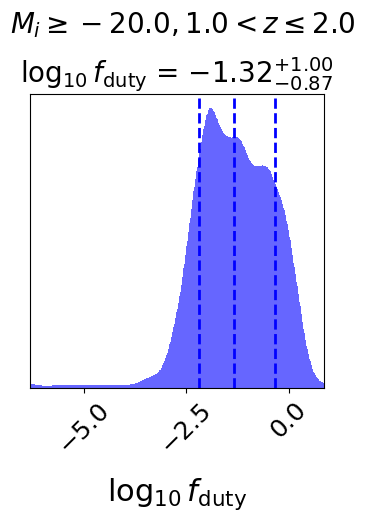

In [184]:
# # initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results_fduty, color='blue', show_titles=True, title_quantiles = quantile,
                           max_n_ticks=3, quantiles=quantile, labels=labels_fduty, fig=(fig, axes))
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1.05, x = 0.6)

In [185]:
# bins_m = np.logspace(quantiles[0][1], M_max, n_bins)
wtheta_2h_P = wtheta_2h_optimized(bins, H0_c_dN_dz_array, params_HOD = [mid, quantiles[0][1], quantiles[2][1], np.log10(12*10**quantiles[0][1]), quantiles[1][1]], theta_mask = False, recenter_thetabins = False) #wtheta_2h_optimized #params_HOD = 
wtheta_2h_P_scatter = wtheta_2h_dynesty(bins, H0_c_dN_dz_array, [mid, quantiles[0][1], quantiles[2][1], np.log10(12*10**quantiles[0][1]), quantiles[1][1]], theta_mask = False, recenter_thetabins = False) #wtheta_2h_optimized #params_HOD = 

wtheta_2h_P_2h = wtheta_2h_optimized(bins, H0_c_dN_dz_array, params_HOD = [mid, quantiles[0][1], quantiles[2][1], np.log10(12*10**quantiles[0][1]), quantiles[1][1]], one_halo = False, theta_mask = False, recenter_thetabins = False) #wtheta_2h_optimized #params_HOD = 

wtheta_2h_P_1h = wtheta_2h_optimized(bins, H0_c_dN_dz_array, params_HOD = [mid, quantiles[0][1], quantiles[2][1], np.log10(12*10**quantiles[0][1]), quantiles[1][1]], two_halo = False, theta_mask = False, recenter_thetabins = False) #wtheta_2h_optimized #params_HOD = 

/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha


<>:25: SyntaxWarning: invalid escape sequence '\g'
<>:25: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2662/1917197721.py:25: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_title('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]))


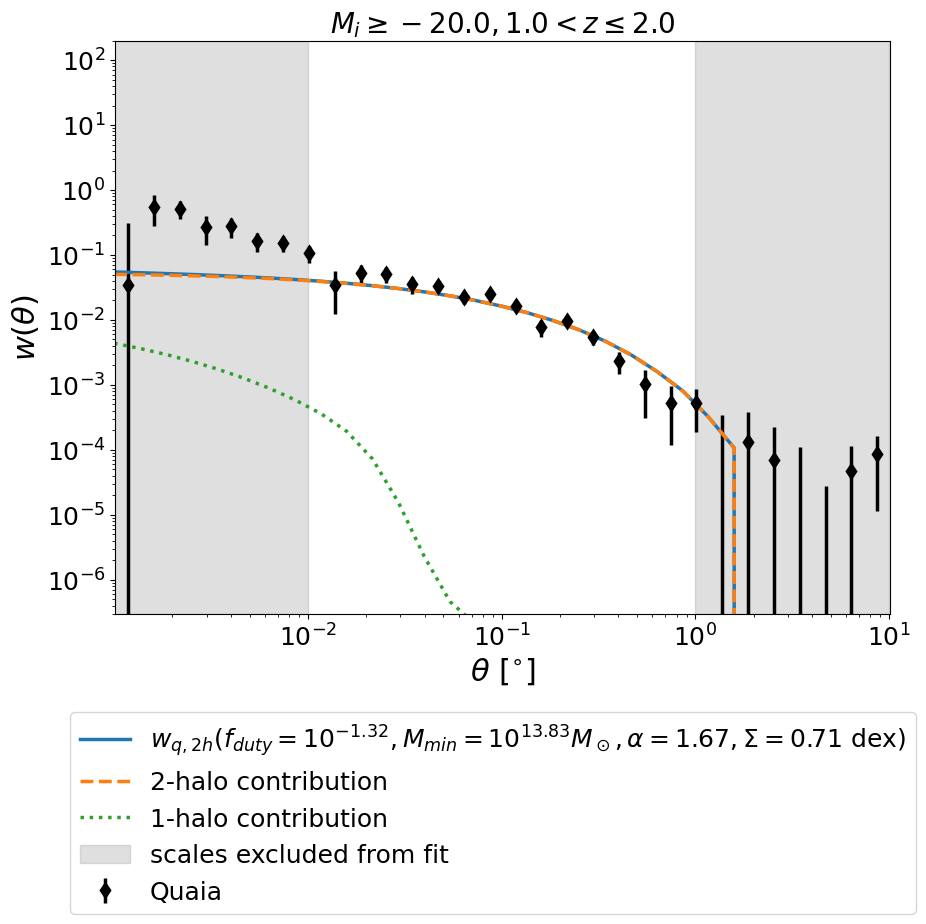

In [186]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)
# remove bottom panel and just print bq somewhere
# plot!
y = np.linspace(3e-7, 2e2)
ax1 = fig.add_subplot(gs[0])
alpha = 0.25

sigma = np.sqrt(np.diag(np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))))
wp_zbin_i = np.load('../results/wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b))
a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax{}_{}_MC_b{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[i], cosmo, b)))            

ax1.errorbar(quaia.recenter(thetabins), wp_zbin_i, linewidth = 2.5, marker = 'd', color = 'black',
            yerr = sigma, markeredgewidth = 2.5, linestyle = 'none', label = 'Quaia') #capsize = 2.5
plt.plot(thetabins, wtheta_2h_P, linewidth = 2.5, label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \alpha = {:.2f}, \Sigma={:.2f}$ dex)'.format(mid, quantiles[0][1], quantiles[1][1], quantiles[2][1]))
# plt.plot(thetabins, wtheta_2h_P_scatter, linewidth = 2.5, linestyle = '-.')
# plt.plot(thetabins, wtheta_2h_P_manual, linewidth = 2.5, label = r'$w_{{q,2h}}(M_{{min}}=10^{{{:.2f}}}M_\odot, \alpha = {:.2f}, \Sigma={:.2f}$ dex)'.format(Mmin, Alpha, Sigma))#Total')

plt.plot(thetabins, wtheta_2h_P_2h, linewidth = 2.5, linestyle = '--', label = r'2-halo contribution')

plt.plot(thetabins, wtheta_2h_P_1h, linewidth = 2.5, label = r'1-halo contribution', linestyle = ':')

ax1.set_title('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]))
ax1.set_xlim(10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim))
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_ylim(3e-7, 2e2)

ax1.set_ylabel(r"$w(\theta)$")
ax1.set_xlabel(r'$\theta$ $[^{\circ}]$') 

if quaia.recenter(thetabins)[-1] > 1:
    ax1.fill_betweenx(y, x1 = thetabins[0], x2 = 10**log_thetamin, color = 'grey', 
                      alpha = alpha, label = 'scales excluded from fit')
    ax1.fill_betweenx(y, x1 = 1, x2 = thetabins[-1], color = 'grey', 
                      alpha = alpha)
    
ax1.legend(bbox_to_anchor=(0.55, -0.65, 0.5, 0.5))

plt.show()

## Across all $z$

In [187]:
dN_dz_norm, H0_c_dN_dz_norm = {L: [] for L in L_bins}, {L: [] for L in L_bins}
for i in range(len(L_bins)):
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(
            G_hi, [j, i], True, ['z', 'L'], bins = [z_bins, L_bins], tab_gcat_type = 'data', method = ['minmax', 'max'], fac_rand = fac_rand, 
            n_bins = [None, None], b = b, mask_type = 'b', verbose = False)
        
        dN_dz = np.sum(stats.norm.pdf(dz[None, :], loc=tab_datahi_mask_zbin0['redshift_quaia'][:, None], scale=tab_datahi_mask_zbin0['redshift_quaia_err'][:, None]), axis = 0)
        dN_dz /= np.sum(stats.norm.cdf(dz[-1], loc=tab_datahi_mask_zbin0['redshift_quaia'], scale=tab_datahi_mask_zbin0['redshift_quaia_err']))
        
        dN_dz_norm[L_bins[i]].append(dN_dz)
        H0_c_dN_dz_norm[L_bins[i]].append([ccl.background.h_over_h0(cosmo_planck18, 1/(1+dz[k]))*Planck18.H0.to(1/u.s)/constants.c.to(u.Mpc/u.s)*
                                      dN_dz[k]**2 for k in range(len(dz))])

In [ ]:
err_labels = ['log10(f_duty)', 'log10(M_min)', 'alpha', 'Sigma']
err = {i: {L: [] for L in L_bins} for i in err_labels}
best_fit_params = {L: [] for L in L_bins}
equal_weight_samples = {L: [] for L in L_bins}
results_Mmin = {L: [] for L in L_bins}
rstate=np.random.default_rng(0)
sample = {err_label: {L: [] for L in L_bins} for err_label in err_labels}
median = {err_label: {L: [] for L in L_bins} for err_label in err_labels}
thetamin, thetamax = 10**log_thetamin, 10**log_thetamax
for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))

    for j in z_array:

        try:

            for k, err_label in enumerate(err_labels[1:]):
                
                sample[err_label][L_bins[i]].append(np.load('../results/erfc_samples_{}_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}_1h_ndim{}_dlogz{}_nlive{}.npy'.format(err_label,
                    G_hi, thetamin, thetamax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b, ndim, dlogz, nlive)))
                median[err_label][L_bins[i]].append(np.load('../results/erfc_median_{}_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}_1h_ndim{}_dlogz{}_nlive{}.npy'.format(err_label,
                        G_hi, thetamin, thetamax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b, ndim, dlogz, nlive)))
                err[err_label][L_bins[i]].append(np.load('../results/erfc_err_{}_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}_1h_ndim{}_dlogz{}_nlive{}.npy'.format(err_label,
                        G_hi, thetamin, thetamax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b, ndim, dlogz, nlive)))
                
            best_fit_params[L_bins[i]].append(np.load('../results/erfc_best_fit_params_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}_1h_ndim{}_dlogz{}_nlive{}.npy'.format(
                        G_hi, thetamin, thetamax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b, ndim, dlogz, nlive)))
        
        except:
            
            if (np.round(N_q[L_bins[i]][j]/1000)>1):
    
                C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
                if diag == True:
                    C*=np.identity(len(C))
        
                log_det_C, solve = log_det(C, ix_grid)
                
                # initialize our nested sampler
                H0_c_dN_dz_array = np.array([H0_c_dN_dz_i.value for H0_c_dN_dz_i in H0_c_dN_dz_norm[L_bins[i]][j]])
                sampler = NestedSampler(loglike, ptform, ndim, logl_args=[log_det_C, wp_chi2[L_bins[i]][j][theta_mask], nbins_mask, solve, 
                                                                          H0_c_dN_dz_array], nlive = nlive, rstate=np.random.default_rng(0)) #H0_c_dN_dz_norm[L_bins[i]][j]
                
                # run the sampler with checkpointing
                sampler.run_nested(dlogz = dlogz)
                results = sampler.results
                
                # Print out a summary of the results.
                results.summary()
                
                fig, axes = dyplot.runplot(results)  # summary (run) plot
                fig.subplots_adjust(hspace=0.25)
                fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)
    
                fig, axes = dyplot.traceplot(results, 
                                             show_titles=True,
                                             trace_cmap='viridis', connect=True,
                                             connect_highlight=range(5), labels=labels, quantiles = quantile, title_quantiles = quantile)
                fig.subplots_adjust(hspace=0.7)
                fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
            
                # initialize figure
                fig, axes = plt.subplots(2, 2, figsize=(10, 10))
                
                # plot initial run (res1; left)
                fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                                             kde=False, labels=labels, fig=(fig, axes))
                fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.975, x = 0.575)
    
                # # initialize figure
                fig, axes = plt.subplots(3, 3, figsize=(15, 15))
                
                # plot initial run (res1; left)
                fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim), hist2d_kwargs = {'contourf_kwargs': contourf_kwargs}, quantiles_2d = quantile_2d, title_quantiles = quantile,
                                           truth_color='black', show_titles=True,
                                           max_n_ticks=3, quantiles=quantile, labels=labels, fig=(fig, axes[:, :3]))
                fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)
    
                samples, weights = results.samples, results.importance_weights()
            
                # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
                quantiles = [dyfunc.quantile(samples[:, i], quantile, weights=weights) 
                             for i in range(samples.shape[1])]
            
                print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
                for k, (lo, mid, hi) in enumerate(quantiles):
                    print(f"{err_labels[k+1]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
                    err[err_labels[k+1]][L_bins[i]].append((lo, hi))
                print()
                
                equal_weight_samples[L_bins[i]].append(dyfunc.resample_equal(samples, weights))
                
                for k, err_label in enumerate(err_labels[1:]):
                    sample[err_label][L_bins[i]].append(equal_weight_samples[L_bins[i]][j][:,k]) #[ind]
                    median[err_label][L_bins[i]].append(quantiles[k][1])
                
                # Get the maximum likelihood sample from dynesty results
                idx_max = np.argmax(results.logl)
                best_fit_param = samples[idx_max]
            
            else:
    
                equal_weight_samples[L_bins[i]].append([np.nan]*ndim) #np.nan
    
                for k, err_label in enumerate(err_labels[1:]):
                    sample[err_label][L_bins[i]].append([np.nan]) #[np.nan]*1000
                    median[err_label][L_bins[i]].append(np.nan)
                    err[err_label][L_bins[i]].append((np.nan, np.nan))
    
                best_fit_param = [np.nan]*ndim
    
                results = np.nan
    
            for k, err_label in enumerate(err_labels[1:]):
                np.save('../results/erfc_samples_{}_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}_1h_ndim{}_dlogz{}_nlive{}.npy'.format(err_label,
                        G_hi, thetamin, thetamax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b, ndim, dlogz, nlive), sample[err_label][L_bins[i]][j])
                np.save('../results/erfc_median_{}_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}_1h_ndim{}_dlogz{}_nlive{}.npy'.format(err_label,
                        G_hi, thetamin, thetamax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b, ndim, dlogz, nlive), median[err_label][L_bins[i]][j])
                np.save('../results/erfc_err_{}_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}_1h_ndim{}_dlogz{}_nlive{}.npy'.format(err_label,
                        G_hi, thetamin, thetamax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b, ndim, dlogz, nlive), err[err_label][L_bins[i]][j])
    
            # Get the maximum likelihood sample from dynesty results
            best_fit_params[L_bins[i]].append(best_fit_param)
    
            np.save('../results/erfc_best_fit_params_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}_1h_ndim{}_dlogz{}_nlive{}.npy'.format(
                        G_hi, thetamin, thetamax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b, ndim, dlogz, nlive), best_fit_params[L_bins[i]][j])
            
            results_Mmin[L_bins[i]].append(results)

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:62: SyntaxWarning: invalid escape sequence '\g'
<>:70: SyntaxWarning: invalid escape sequence '\g'
<>:79: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:62: SyntaxWarning: invalid escape sequence '\g'
<>:70: SyntaxWarning: invalid escape sequence '\g'
<>:79: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2662/2490660868.py:55: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)
/tmp/ipykernel_2662/2490660868.py:62: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
/tmp/ipykernel_2662/2490660868.py:70: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.

M_i<=-20.0


3629it [3:57:33, 16.82s/it, bound: 1 | nc: 31 | ncall: 36369 | eff(%):  9.978 | loglstar:   -inf < 48.177 <    inf | logz: 44.298 +/-  0.055 | dlogz:  1.777 >  0.010] /tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
3900it [4:03:30,  1.14s/it, bound: 2 | nc: 3 | ncall: 37371 | eff(%): 10.436 | loglstar:   -inf < 48.440 <    inf | logz: 44.598 +/-  0.055 | dlogz:  1.329 >  0.010] /tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
4250it [4:09:16,  1.10it/s, bound: 3 | nc: 2 | ncall: 38372 | eff(%): 11.076 | loglstar:   -inf < 48.691 <    inf | logz: 44.876 +/-  0.054 | dlogz:  0.922 >  0.010] /tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
4463it [4:15:14,  1.95s/it, bound: 4 | nc: 9 | ncall: 39375 | eff(%): 11.335 | loglstar:   -inf < 48.785 <    inf | logz: 4

Summary
nlive: 1000
niter: 9026
ncall: 54736
eff(%): 18.317
logz: 45.461 +/-  0.055
0.0<z<=1.0
log10(M_min): 14.47 + 1.00/-0.99
alpha: 1.77 + 1.49/-1.16
Sigma: 0.95 + 0.20/-0.23



/tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
3606it [3:28:20,  7.53s/it, bound: 1 | nc: 22 | ncall: 36075 | eff(%):  9.996 | loglstar:   -inf < 62.378 <    inf | logz: 57.495 +/-  0.063 | dlogz:  4.608 >  0.010] /tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
3912it [3:34:08,  1.54s/it, bound: 2 | nc: 8 | ncall: 37081 | eff(%): 10.550 | loglstar:   -inf < 63.038 <    inf | logz: 58.355 +/-  0.062 | dlogz:  3.462 >  0.010] /tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alpha
4179it [3:39:58,  1.88s/it, bound: 3 | nc: 6 | ncall: 38086 | eff(%): 10.973 | loglstar:   -inf < 63.408 <    inf | logz: 58.836 +/-  0.061 | dlogz:  2.748 >  0.010] /tmp/ipykernel_2662/2869154343.py:5: RuntimeWarning: invalid value encountered in power
  n_m = fduty*((bins_m-M0)/M1)**alp

In [ ]:
cmap_purple = plt.get_cmap('Purples')(np.linspace(0.333, 0.999, len(z_array)))

In [148]:
list(L_bins).index(-20.0)

[-20.0, -25.0, -26.0, -27.0]

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (35, 35))
gs = gridspec.GridSpec(4, 4, wspace = 0.05, hspace = 0.1)

for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[j*4+i])

            # --- corner plot -> buffer -> master cell ---
            contourf_kwargs = {'colors': make_contour_cmap(cmap_theta[i], len(quantile))}
            dyplot._hist2d(sample[err_labels[1]][L_bins[i]][j], sample[err_labels[2]][L_bins[i]][j], color=cmap_theta[i], levels = quantile_2d, contourf_kwargs = contourf_kwargs)

            ax1.set_xlim(9, 16)
            ax1.set_ylim(0,1.4)
            # titles & labels
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                    ax1.set_ylabel(r"{}$_{{{:.1f}<z\leq{:.1f}}}$".format(labels[1],
                        z_bins[j], z_bins[j+1]))
            else:
                    ax1.set_yticklabels([])
            ax1.set_xlabel(labels[0])
            plt.setp(ax1.get_xticklabels(), rotation=0, ha='center')
            # ... rest of your existing sample/quantile code ...

            samples, weights = results_Mmin[L_bins[i]][j].samples, results_Mmin[L_bins[i]][j].importance_weights() # try to figure out a way to do this without results_Mmin, I think I can? its from the stuff ive already saved

            # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
            quantiles = [dyfunc.quantile(samples[:, k], quantile, weights=weights) 
                         for k in range(samples.shape[1])]
            
            legend=[]
            for k, (lo, mid, hi) in enumerate(quantiles):
                legend.append(f"{labels[k]}$={mid:.2f}^{{+{hi-mid:.2f}}}_{{-{mid-lo:.2f}}}$")

            custom_lines = [Line2D([0], [0], color = cmap_theta[i], linestyle = '-', linewidth=2.5)]
            ax1.legend(handles=custom_lines, labels=['{}, {} dex'.format(legend[0],legend[1])])
            ax1.xaxis.set_label_coords(0.5, -0.1)
            
# fig.savefig('../figures/cornerplot_Mmin_b{}_wtheta.pdf'.format(b), bbox_inches='tight')
plt.show()

In [ ]:
f_duty = {L: [] for L in L_bins}
f_duty_samples = {L: [] for L in L_bins}

for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))
    
    for j in z_array:

        if (np.round(N_q[L_bins[i]][j]/1000)>1):
        
            print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))            
            bins_m = np.logspace(equal_weight_samples[L_bins[i]][j][:,0], M_max, n_bins) #M_min_samples
            # n_m=np.ones(len(bins_m))

            # n_c=N_c(bins_m, equal_weight_samples[L_bins[i]][j][:,0], 0)
            # n_s = N_s(bins_m, equal_weight_samples[L_bins[i]][j][:,2], 10**equal_weight_samples[L_bins[i]][j][:,0], 12*10**equal_weight_samples[L_bins[i]][j][:,0], equal_weight_samples[L_bins[i]][j][:,1])
            # n_m = n_c+n_s

            n_dm = []
            for k in range(len(equal_weight_samples[L_bins[i]][:,0])):
                n_c=N_c(bins, equal_weight_samples[L_bins[i]][:,0][k], 1, sigma = equal_weight_samples[L_bins[i]][:,2][k])
                n_s = N_s(bins, 1, 10**equal_weight_samples[L_bins[i]][:,0][k], 12*10**equal_weight_samples[L_bins[i]][:,0][k], equal_weight_samples[L_bins[i]][:,1][k])
                n_m = n_c+n_s
            
                n_dm.append(M(bins, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1].value) #[:,0]
            
            # n_dm = [M(bins_m[:,k], n_m[:,k], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for k in range(len(equal_weight_samples[L_bins[i]][j][:,0]))] #[:,0]
            # n_dm = [M(bins_m[:,k], n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for k in range(len(equal_weight_samples[L_bins[i]][j]))]
            equal_weight_samples_fduty = np.log10(n_q[L_bins[i]][j]/n_dm)
            print('n_q: {:.1e} (h/Mpc)^3'.format(n_q[L_bins[i]][j]))
            print('n_dm: {:.1e} (h/Mpc)^3'.format(np.median(n_dm)))
            
            # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
            lo, mid, hi = dyfunc.quantile(equal_weight_samples_fduty, quantile) 
            
            print(f"{labels_fduty[0]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}\n")
            err[err_labels[0]][L_bins[i]].append((lo, hi)) #0

            f_duty_median = mid

            # ind = np.random.choice(range(len(equal_weight_samples_fduty)), size = 1000, replace = False)
            f_duty_sample = equal_weight_samples_fduty #[ind]

            # # Get the maximum likelihood sample from dynesty results
            bins_m = np.logspace(best_fit_params[L_bins[i]][j][0], M_max, n_bins)
            n_dm = M(bins_m, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1]
            best_fit_param = np.log10(n_q[L_bins[i]][j]/n_dm)
            
        else:

            f_duty_sample = np.nan #[np.nan]*1000
            
            f_duty_median = np.nan

            err[err_labels[0]][L_bins[i]].append((np.nan, np.nan)) #0

            best_fit_param = [np.nan]*ndim
            
        f_duty_samples[L_bins[i]].append(f_duty_sample)
        
        f_duty[L_bins[i]].append(f_duty_median)

        # Get the maximum likelihood sample from dynesty results
        best_fit_params[L_bins[i]][j]=np.append(best_fit_param, best_fit_params[L_bins[i]][j])

### Solve for $\chi_c^2=\Delta^T x$ where $Cx=\Delta$

In [ ]:
def f0_GLS_solve(x, a, C, wp, H0_c_dN_dz_norm, cosmo = cosmo_planck18, rpmask = theta_mask, hartlap = hartlap, fduty = 0, M_max = M_max, #True
                 recenter_thetabins = True, rpbins = thetabins, n_bins = n_bins) #, theta_mask = theta_mask):
    
    fduty, M_min, Alpha = x
    
    bins_m = np.logspace(M_min, M_max, n_bins)
    
    wp_2h_zbin = wtheta_2h_optimized(bins_m, H0_c_dN_dz_norm, theta_mask = rpmask, recenter_thetabins = recenter_thetabins, 
                                     params_HOD = [fduty, M_min, 0, np.log10(12*10**M_min), Alpha], one_halo = False)
    
    if isinstance(rpmask, bool):
        rpmask = [rpmask]*len(quaia.recenter(rpbins))
    delta = (wp-wp_2h_zbin)[rpmask]
    ix_grid = np.ix_(rpmask, rpmask)
    
    return delta.T @ (hartlap*np.linalg.solve(C[ix_grid], delta))

### Add a number density constraint

In [ ]:
def constraint(x, a, n_q, cosmo = cosmo_planck18, error = 0.05, M_max = M_max, fduty = 0, method = method, recenter_thetabins = True, hmf = hmf[mass_def], n_bins = n_bins):
    
    M_min, Alpha = x # fduty,
    
    bins_m = np.logspace(M_min, M_max, n_bins)
    _, n_c, n_s = HOD_2h(bins_m, M_min, fduty, 0, a, np.log10(12*10**M_min), Alpha, method = method, cosmo = cosmo)
    
    n_q_theory = M(bins_m, n_c + n_s, a = a, cosmo = cosmo, recenter = recenter_thetabins, hmf= hmf)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [ ]:
chi2_L_z = []
for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))

    chi2_z=[]
    
    for j in z_array:

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
        
            print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
            x = [median[err_label][L_bins[i][j]] for err_label in err_labels[1:]] #[M_min[L_bins[i]][j]]
            
            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            if diag == True:
                C*=np.identity(len(C))
            chi2 = f0_GLS_solve(x, a_zbin[L_bins[i]][j], C, wp_chi2[L_bins[i]][j], H0_c_dN_dz_norm[L_bins[i]][j], fduty = f_duty[L_bins[i]][j]) #rpmask = theta_mask
            df = nbins_mask-len(x) #-1
        
            print('           chi^2: {:.2f}'.format(chi2))
            print('   reduced chi^2: {:.2f}'.format(chi2/df))
            print('         delta n: {:.2e}'.format(constraint(x, a_zbin[L_bins[i]][j], n_q[L_bins[i]][j]))) #, fduty = f_duty[L_bins[i]][j])))
            try:
                print('condition number: {:.2f}'.format(np.linalg.cond(C[ix_grid])))
            except Exception as e:
                print(e)
            print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

        else:
            chi2=np.nan

        chi2_z.append(chi2)
        
    chi2_L_z.append(chi2_z)

## Null test

In [ ]:
f_duty_null = {L: [] for L in L_bins}
f_duty_samples_null = {L: [] for L in L_bins}
err_null = copy.deepcopy(err)
best_fit_params_null = copy.deepcopy(best_fit_params)

for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))
    
    for j in z_array:

        if (np.round(N_q[L_bins[i]][j]/1000)>1):
        
            print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))            
            bins_m = np.logspace(equal_weight_samples[L_bins[0]][j][:,0], M_max, n_bins) #M_min_samples
            # n_m=np.ones(len(bins_m))
            # print('test')

            # n_c=N_c(bins_m, equal_weight_samples[L_bins[0]][j][:,0], 0)
            # n_s = N_s(bins_m, equal_weight_samples[L_bins[0]][j][:,2], 10**equal_weight_samples[L_bins[0]][j][:,0], 12*10**equal_weight_samples[L_bins[0]][j][:,0], equal_weight_samples[L_bins[0]][j][:,1])
            # n_m = n_c+n_s

            n_dm = []
            for k in range(len(equal_weight_samples[L_bins[0]][:,0])):
                n_c=N_c(bins, equal_weight_samples[L_bins[0]][:,0][k], 1, sigma = equal_weight_samples[L_bins[0]][:,2][k])
                n_s = N_s(bins, 1, 10**equal_weight_samples[L_bins[0]][:,0][k], 12*10**equal_weight_samples[L_bins[0]][:,0][k], equal_weight_samples[L_bins[0]][:,1][k])
                n_m = n_c+n_s
            
                n_dm.append(M(bins, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1].value) #[:,0]
                
            # n_dm = [M(bins_m[:,k], n_m[:,k], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for k in range(len(equal_weight_samples[L_bins[i]][j][:,0]))] #[:,0]
            # n_dm = [M(bins_m[:,k], n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for k in range(len(equal_weight_samples[L_bins[0]][j]))]
            equal_weight_samples_fduty = np.log10(n_q[L_bins[i]][j]/n_dm)
            print('n_q: {:.1e} (h/Mpc)^3'.format(n_q[L_bins[i]][j]))
            print('n_dm: {:.1e} (h/Mpc)^3'.format(np.median(n_dm)))
            
            # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
            lo, mid, hi = dyfunc.quantile(equal_weight_samples_fduty, quantile) 
            
            print(f"{labels_fduty[0]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}\n")
            err_null[err_labels[0][L_bins[i]].append((lo, hi)) #0

            f_duty_median = mid

            # ind = np.random.choice(range(len(equal_weight_samples_fduty)), size = 1000, replace = False)
            f_duty_sample = equal_weight_samples_fduty #[ind]

            # # Get the maximum likelihood sample from dynesty results
            bins_m = np.logspace(best_fit_params_null[L_bins[0]][j][1], M_max, n_bins)
            n_dm = M(bins_m, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1]
            best_fit_param = np.log10(n_q[L_bins[i]][j]/n_dm)
            
        else:

            f_duty_sample = [np.nan] #*1000
            
            f_duty_median = np.nan

            err_null[err_labels[0]][L_bins[i]].append((np.nan, np.nan)) #0

            best_fit_param = np.nan
            
        f_duty_samples_null[L_bins[i]].append(f_duty_sample)
        
        f_duty_null[L_bins[i]].append(f_duty_median)

        # Get the maximum likelihood sample from dynesty results
        # print(best_fit_param)
        best_fit_params_null[L_bins[i]][j][0]=best_fit_param

In [ ]:
chi2_null = []

for i in range(len(L_bins)):

    chi2_z=[]
    
    print('M_i<={}'.format(L_bins[i]))

    for j in z_array:

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
        
            print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
            x = [median[err_label][L_bins[i][j]] for err_label in err_label[1:] #[M_min[L_bins[i]][j]]
            
            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            if diag == True:
                C*=np.identity(len(C))
            chi2 = f0_GLS_solve(x, a_zbin[L_bins[i]][j], C, wp_chi2[L_bins[i]][j], H0_c_dN_dz_norm[L_bins[i]][j], fduty = f_duty_null[L_bins[i]][j]) #rpmask = theta_mask, 
            df = nbins_mask #-len(x)-1
        
            print('           chi^2: {:.2f}'.format(chi2))
            print('   reduced chi^2: {:.2f}'.format(chi2/df))
            print('         delta n: {:.2e}'.format(constraint(x, a_zbin[L_bins[i]][j], n_q[L_bins[i]][j], fduty = f_duty_null[L_bins[i]][j])))
            try:
                print('condition number: {:.2f}'.format(np.linalg.cond(C[ix_grid])))
            except Exception as e:
                print(e)
            print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

        else:
            chi2=np.nan

        chi2_z.append(chi2)
        
    chi2_null.append(chi2_z)

In [ ]:
cmap_chi2 = sns.color_palette("vlag", as_cmap=True)

In [ ]:
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0])

chi2_delta = chi2_null-np.array(chi2_L_z)
image = plt.pcolormesh(chi2_delta)

fig.colorbar(image, label = '$\Delta\chi^2$')
# ax1.set_xticks(np.arange(len(z_array)) + 0.5)
# ax1.set_xticklabels(['{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]) for j in z_array], rotation = -45)
ax1.set_xticks(range(len(z_bins)), labels = z_bins)
ax1.set_yticks(quaia.recenter(np.array(range(len(L_array)))), labels = L_bins)
ax1.set_xlabel('$z$')
ax1.set_ylabel('$M_{i,\mathrm{max}}$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0])
df_L_z = nbins_mask-ndim #-1
df_null = nbins_mask#-ndim #-1

p_value = stats.chi2.sf(chi2_null, df_null)
n_sigma_null = stats.norm.ppf(1 - p_value)

p_value = stats.chi2.sf(chi2_L_z, df_L_z)
n_sigma_L_z = stats.norm.ppf(1 - p_value)
image = plt.pcolormesh(n_sigma_null-n_sigma_L_z)

fig.colorbar(image, label = '$\Delta N\sigma$')
ax1.set_xticks(range(len(z_bins)), labels = z_bins)
ax1.set_yticks(quaia.recenter(np.array(range(len(L_array)))), labels = L_bins)
ax1.set_xlabel('$z$')
ax1.set_ylabel('$M_{i,\mathrm{max}}$')
plt.show()

In [ ]:
cmap_chi2.set_bad('lightgray')

In [ ]:
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0])

p_value = stats.chi2.sf(chi2_delta, df_null-df_L_z)
n_sigma_delta = stats.norm.isf(p_value)

vlim = max(np.max(n_sigma_delta[np.isfinite(n_sigma_delta)]), np.min(np.abs(n_sigma_delta[np.isfinite(n_sigma_delta)])))
image = ax1.pcolormesh(n_sigma_delta, vmin = -vlim, vmax = vlim, cmap = cmap_chi2)

nan_overlay = np.where(np.isnan(n_sigma_delta), 1.0, np.nan)
ax1.pcolormesh(nan_overlay, cmap=plt.cm.colors.ListedColormap(['black']), vmin=0, vmax=1)

fig.colorbar(image, label = '$N\sigma$')
ax1.set_xticks(range(len(z_bins)), labels = z_bins)
ax1.set_yticks(quaia.recenter(np.array(range(len(L_array)))), labels = L_bins)
ax1.set_xlabel('$z$')
ax1.set_ylabel('$M_{i,\mathrm{max}}$')
ax1.set_title('Is adding a free $M_{min}$ parameter worth it?')
custom_lines = [mpatches.Patch(color=cmap_M_min[-1]), mpatches.Patch(color=cmap_M_min[0]), mpatches.Patch(color='lightgray'), 
                mpatches.Patch(color='black')]
first_legend = plt.legend(custom_lines, [r'yes', 'no', 'identical to null model', 
                                         'bins excluded from analysis'], bbox_to_anchor=(0.5, -0.6, 0.5, 0.5), ncol =2)
fig.add_artist(first_legend)

# plt.savefig('../figures/null_test.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1)
ax1 = fig.add_subplot(gs[0])

n_sigma_ratio = n_sigma_null/n_sigma_L_z
vlim = max(np.max(n_sigma_ratio[np.isfinite(n_sigma_ratio)]), np.min(np.abs(n_sigma_ratio[np.isfinite(n_sigma_ratio)])))
image = ax1.pcolormesh(n_sigma_ratio, vmin = -vlim, vmax = vlim, cmap = cmap_chi2)

nan_overlay = np.where(np.isnan(n_sigma_delta), 1.0, np.nan)
ax1.pcolormesh(nan_overlay, cmap=plt.cm.colors.ListedColormap(['black']), vmin=0, vmax=1)

fig.colorbar(image, label = '$N\sigma_\mathrm{null}/N\sigma_\mathrm{free}$')
ax1.set_xticks(range(len(z_bins)), labels = z_bins)
ax1.set_yticks(quaia.recenter(np.array(range(len(L_array)))), labels = L_bins)
ax1.set_xlabel('$z$')
ax1.set_ylabel('$M_{i,\mathrm{max}}$')

# custom_lines = [mpatches.Patch(color=cmap_M_min[-1]), mpatches.Patch(color=cmap_M_min[0]), mpatches.Patch(color='lightgray'), 
#                 mpatches.Patch(color='black')]
# first_legend = plt.legend(custom_lines, [r'preference for free $M_{min}$', 'preference for null test', 'no preference', 
#                                          'bins excluded from analysis'], bbox_to_anchor=(0.8, 0.7, 0.5, 0.5), ncol =2)
# fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 3, wspace = 0.1, width_ratios = [1,1,0.05])
ax1 = fig.add_subplot(gs[0])

cmin = min(np.nanmin(n_sigma_null), np.nanmin(n_sigma_L_z))
cmax = max(np.nanmax(n_sigma_null), np.nanmax(n_sigma_L_z))
vmin = -max(np.abs(cmin), cmax)
vmax = max(np.abs(cmin), cmax)

image = ax1.pcolormesh(n_sigma_null, vmin = vmin, vmax = vmax, cmap = cmap_chi2)
# fig.colorbar(image, label = '$N\sigma$')
ax1.set_xticks(range(len(z_bins)), labels = z_bins)
ax1.set_yticks(quaia.recenter(np.array(range(len(L_array)))), labels = L_bins)
ax1.set_xlabel('$z$')
ax1.set_ylabel('$M_{i,\mathrm{max}}$')
ax1.set_title('$M_{min}(M_{i,\mathrm{max}}=-20.0)$')

ax1 = fig.add_subplot(gs[1])
image = ax1.pcolormesh(n_sigma_L_z, vmin = vmin, vmax = vmax, cmap = cmap_chi2)
ax1.set_xticks(range(len(z_bins)), labels = z_bins)
ax1.set_yticks(quaia.recenter(np.array(range(len(L_array)))), labels = [])
ax1.set_xlabel('$z$')
ax1.set_title('$M_{min}(M_{i,\mathrm{max}})$')
# ax1.set_ylabel('$M_{i,\mathrm{max}}$')

ax1 = fig.add_subplot(gs[2])
fig.colorbar(image, label = '$N\sigma$', cax = ax1)

plt.show()

## Plot results

In [ ]:
z_eff = [0.5, 1.5, 2.5, 3.5]

In [ ]:
M_min_err_hi = [0.04, 0.02, 0.03, 0.1]
M_min_err_lo = [0.05, 0.02, 0.03, 0.12]

In [ ]:
cmap_grey = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(L_bins)))

In [ ]:
M_min_array_old = [12.86, 12.74, 12.79, 12.82]

In [ ]:
zmin, zmax = [], []
for i in range(len(L_bins)):
    
    zmin.append(np.min(1/np.array(a_zbin[L_bins[i]])-1))
    zmax.append(np.max(1/np.array(a_zbin[L_bins[i]])-1))

zmin = np.max(zmin)
zmax = np.min(zmax)
zmin, zmax

In [ ]:
cmap_green = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))

In [ ]:
blue = np.mean(cmap_blue, axis = 0)
green = np.mean(cmap_green, axis = 0)
purple = np.mean(cmap_purple, axis = 0)
orange = np.mean(cmap_orange, axis = 0)

In [ ]:
fig = plt.figure(figsize = (10, 8))
err_L_z = copy.deepcopy(err)
for i in range(len(L_bins)):

    # M_min_err = np.array(err['log10(M_min)'][L_bins[i]])
    # M_min_L_z=np.array(M_min[L_bins[i]])

    err_L_z['log10(M_min)'][L_bins[i]] = np.array(err_L_z['log10(M_min)'][L_bins[i]])
    err_L_z['log10(f_duty)'][L_bins[i]] = np.array(err_L_z['log10(f_duty)'][L_bins[i]])
    
    for j in z_array:

        if not ((((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1)):

            # print(i,j)
            # M_min_err[j,:]=np.nan
            # M_min_L_z[j]=np.nan

            err_L_z['log10(M_min)'][L_bins[i]][j,:] = np.nan
            err_L_z['log10(f_duty)'][L_bins[i]][j,:] = np.nan

    # M_min_lo, M_min_hi = M_min_err[:,0], M_min_err[:,1]
    
for i in range(len(L_bins)):
    
    # M_min_lo, M_min_hi = np.array(err['log10(M_min)'][L_bins[i]])[:,0], np.array(err['log10(M_min)'][L_bins[i]])[:,1]
    M_min_lo, M_min_hi = err_L_z['log10(M_min)'][L_bins[i]][:,0], err_L_z['log10(M_min)'][L_bins[i]][:,1]
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    plt.plot(zbin, M_min[L_bins[i]], color = cmap_purple[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)', zorder = 0)
    plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = cmap_purple[::-1][i])

    # plt.plot(zbin, np.array(best_fit_params[L_bins[i]]).T[1], color = cmap_orange[::-1][i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
    
plt.title(r'$w(\theta)$')#, N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = cmap_red[-1], linewidth = 2.5, linestyle = '--', zorder = 3)
plt.fill_between(z_eff, M_min_array+np.array(M_min_array)/M_min_array_old*M_min_err_hi, 
                 M_min_array-np.array(M_min_array)/M_min_array_old*M_min_err_lo, alpha = 0.5, color = cmap_red[-1])
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)
# plt.ylim(9,15)

custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = cmap_red[-1], linestyle = '--', linewidth = 2.5)]
                # Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025'],
                           # , 'max chi$^2$'], 
                           loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_purple[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))

# for i in range(len(L_bins)):
i = 0
    
M_min_lo, M_min_hi = np.array(err['log10(M_min)'][L_bins[i]])[:,0], np.array(err['log10(M_min)'][L_bins[i]])[:,1]
zbin = 1/np.array(a_zbin[L_bins[i]])-1
plt.plot(zbin, M_min[L_bins[i]], color = cmap_purple[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)', zorder = 0)
plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = cmap_purple[::-1][i])
    
plt.title(r'$w(\theta)$')#, N_{{jk}}={}$, step-function, sellentin'.format(N))
# plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = cmap_red[-1], linewidth = 2.5, linestyle = '--', zorder = 3)
# plt.fill_between(z_eff, M_min_array+np.array(M_min_array)/M_min_array_old*M_min_err_hi, 
#                  M_min_array-np.array(M_min_array)/M_min_array_old*M_min_err_lo, alpha = 0.5, color = cmap_red[-1])
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)

# custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
#                 Line2D([0], [0], color = cmap_red[-1], linestyle = '--', linewidth = 2.5)]
# second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
#                                           'Giner Mascarell et al. 2025'],
#                            loc = 'lower left')
# fig.add_artist(second_legend)

# custom_lines = [mpatches.Patch(color=cmap_purple[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
# first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
# fig.add_artist(first_legend)

plt.show()

In [ ]:
z_sigma = {L: [] for L in L_bins}

for i in range(len(L_bins)):

    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(
            G_hi, [j, i], True, ['z', 'L'], bins = [z_bins, L_bins], tab_gcat_type = 'data', method = ['minmax', 'max'], fac_rand = fac_rand, 
            n_bins = [None, None], b = b, mask_type = 'b', verbose = False)

        z_sigma[L_bins[i]].append(np.percentile(tab_datahi_mask_zbin0['redshift_quaia'], [16, 84]))

In [ ]:
red = np.mean(cmap_red, axis = 0)

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in z_array:
    
    M_min_lo, M_min_hi = [np.array(err['log10(M_min)'][L])[:,0][i] for L in L_bins], [np.array(err['log10(M_min)'][L])[:,1][i] for L in L_bins]
    plt.plot(L_bins, [M_min[L][i] for L in L_bins], color = cmap_purple[i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(L_bins, M_min_lo, M_min_hi, alpha = 0.5, color = cmap_purple[i])
    plt.axhline(M_min_array[i], label = 'Giner Mascarell et al. 2025', color = cmap_red[i], linewidth = 2.5, linestyle = '--')
    plt.fill_between(L_bins, [M_min_array[i]+(np.array(M_min_array)/M_min_array_old*M_min_err_hi)[i]]*len(L_bins), [M_min_array[i]-(np.array(M_min_array)/M_min_array_old*M_min_err_lo)[i]]*len(L_bins), alpha = 0.5, color = cmap_red[i])
    plt.plot(L_bins, [best_fit_params[L][i][1] for L in L_bins], color = cmap_orange[i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
    
plt.title(r'$w(\theta), N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$M_i$')
plt.xlim(L_bins[0], L_bins[-1])
plt.ylim(10.95,14.75)

custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = red, linestyle = '--', linewidth = 2.5),
                Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025', 'max chi$^2$'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[i], alpha = 0.5) for i in range(len(z_array))]
first_legend = plt.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fduty_old = [0.018, 0.022, 0.056, 0.071]

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(L_bins)):
    
    f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'][L_bins[i]])[:,0], np.array(err['log10(f_duty)'][L_bins[i]])[:,1]
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    plt.plot(zbin, f_duty[L_bins[i]], color = cmap_purple[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_purple[::-1][i])
    plt.plot(zbin, np.array(best_fit_params[L_bins[i]]).T[0], color = cmap_orange[::-1][i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
   
plt.title(r'$w(\theta)$')#, N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = cmap_red[-1], linewidth = 2.5, linestyle = '--')
plt.fill_between(z_eff, np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi), 
                 np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo), alpha = 0.5, color = cmap_red[-1])
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)
plt.ylim(-6,0)

custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = cmap_red[-1], linestyle = '--', linewidth = 2.5),
                Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025', 'max chi$^2$'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))

i = 0
# for i in range(len(L_bins)):
    
f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'][L_bins[i]])[:,0], np.array(err['log10(f_duty)'][L_bins[i]])[:,1]
zbin = 1/np.array(a_zbin[L_bins[i]])-1
plt.plot(zbin, f_duty[L_bins[i]], color = cmap_purple[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_purple[::-1][i])
    # plt.plot(zbin, np.array(best_fit_params[L_bins[i]]).T[0], color = cmap_orange[::-1][i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
   
plt.title(r'$w(\theta)$')#, N_{{jk}}={}$, step-function, sellentin'.format(N))
# plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = cmap_red[-1], linewidth = 2.5, linestyle = '--')
# plt.fill_between(z_eff, np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi), 
#                  np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo), alpha = 0.5, color = cmap_red[-1])
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)
plt.ylim(-6,0)

# custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
#                 Line2D([0], [0], color = cmap_red[-1], linestyle = '--', linewidth = 2.5),
#                 Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
# second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
#                                           'Giner Mascarell et al. 2025', 'max chi$^2$'], loc = 'lower left')
# fig.add_artist(second_legend)

# custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
# first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
# fig.add_artist(first_legend)

plt.show()

In [ ]:
z_centers_eft    = [2.50, 2.29, 2.51, 3.02, 2.50, 2.50, 2.50][:4]
z_err_lo_eft     = [0.30, 0.09, 0.13, 0.38, 0.30, 0.30, 0.30][:4]
z_err_hi_eft     = [0.30, 0.09, 0.13, 0.38, 0.30, 0.30, 0.30][:4]

fduty_eft        = np.log10([0.00734, 0.0162, 0.0061, 0.00145, 0.0019, 0.0023, 0.0044])[:4]
fduty_err_hi_eft = np.log10(10**fduty_eft+[0.0014,  0.0031, 0.0016, 0.0003,  0.0004, 0.0006, 0.0015][:4])-fduty_eft
fduty_err_lo_eft = fduty_eft-np.log10(10**fduty_eft-[0.0011,  0.0025, 0.0014, 0.0002,  0.0003, 0.0004, 0.0008][:4]) #table 7 https://arxiv.org/pdf/1507.08380

In [ ]:
Mmin_eft        = np.log10(np.array([0.93, 1.39, 0.82, 0.35, 1.03, 0.92, 1.26])*1e12/Planck18.h)[:4]
Mmin_err_hi_eft = np.log10(np.add([0.11, 0.16, 0.15, 0.04, 0.12, 0.12, 0.26],[0.93, 1.39, 0.82, 0.35, 1.03, 0.92, 1.26])[:4]*1e12/Planck18.h)-Mmin_eft
Mmin_err_lo_eft = Mmin_eft-np.log10(np.subtract([0.93, 1.39, 0.82, 0.35, 1.03, 0.92, 1.26], [0.09, 0.15, 0.14, 0.07, 0.10, 0.16, 0.15])[:4]*1e12/Planck18.h) #table 7 https://arxiv.org/pdf/1507.08380

In [ ]:
z_centers_2    = [1.05, 1.35, 1.65, 2.00, 1.55][:-1]
z_err_lo_2     = [0.15, 0.15, 0.15, 0.20, 0.65][:-1]
z_err_hi_2     = [0.15, 0.15, 0.15, 0.20, 0.65][:-1]

fduty_2        = np.log10([0.0091, 0.0183, 0.0355, 0.0422, 0.0292])[:-1]
fduty_err_hi_2 = np.log10(10**fduty_2+[0.0027, 0.0028, 0.0133, 0.0077, 0.0048][:-1])-fduty_2
fduty_err_lo_2 = fduty_2-np.log10(10**fduty_2-[0.0027, 0.0028, 0.0133, 0.0077, 0.0048][:-1])

Mmin_2         = np.log10(np.array([1.99, 2.24, 2.51, 1.99, 2.51])*1e12/Planck18.h)[:-1]
Mmin_err_hi_2  = np.log10(np.add([0.52, 0.27, 0.65, 0.24, 0.31], [1.99, 2.24, 2.51, 1.99, 2.51])[:-1]*1e12/Planck18.h)-Mmin_2
Mmin_err_lo_2  = Mmin_2-np.log10(np.subtract([1.99, 2.24, 2.51, 1.99, 2.51],[0.41, 0.24, 0.27, 0.41, 0.27])[:-1]*1e12/Planck18.h) # table 4 https://arxiv.org/pdf/1705.04718

In [ ]:
z_shen = [3.2, 4.6]
z_err_shen = [0.3, 0.8]

fduty_shen = (np.log10(0.05)+np.log10(0.004))/2, (np.log10(0.6)+np.log10(0.03))/2
fduty_err_lo_shen = fduty_shen - np.log10([0.004, 0.03])
fduty_err_hi_shen = np.log10([0.05, 0.6]) - fduty_shen

Mmin_shen = np.log10([(2.26e12+3.11e12)/2, (3.83e12+5.76e12)/2]/Planck18.h) # https://arxiv.org/abs/astro-ph/0702214 table 6
Mmin_err_lo_shen = Mmin_shen-np.log10([2.26e12, 3.83e12]/Planck18.h)
Mmin_err_hi_shen = np.log10([3.11e12, 5.76e12]/Planck18.h)-Mmin_shen

In [ ]:
z_charles = [2.143, 2.479, 3.264]
z_err_charles = np.array([[2,2.3], [2.3,2.7], [3.1,3.5]])
z_err_lo_charles = z_charles - z_err_charles[:,0]
z_err_hi_charles = z_err_charles[:,1] - z_charles

fduty_charles = np.log10([0.0243, 0.0207, 0.0142])
fduty_err_charles = np.array([0.0008, 0.0008, 0.0016])
fduty_err_lo_charles = fduty_charles-np.log10(10**fduty_charles-fduty_err_charles)
fduty_err_hi_charles = np.log10(10**fduty_charles+fduty_err_charles)-fduty_charles

In [ ]:
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.15, hspace = 0.15)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for i in range(len(L_bins)):

    M_min_lo, M_min_hi = err_L_z['log10(M_min)'][L_bins[i]][:,0], err_L_z['log10(M_min)'][L_bins[i]][:,1]

    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    xerr = [zbin-np.array(z_sigma[L_bins[i]])[:,0], np.array(z_sigma[L_bins[i]])[:,1]-zbin]

    ax1.errorbar(zbin, M_min[L_bins[i]], yerr = [M_min[L_bins[i]]-M_min_lo, M_min_hi-M_min[L_bins[i]]], 
                 xerr = xerr, linestyle = 'none', marker = 'o', 
                 color = cmap_theta[i], linewidth = 2.5, markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)#, 

    f_duty_lo, f_duty_hi = err_L_z['log10(f_duty)'][L_bins[i]][:,0], err_L_z['log10(f_duty)'][L_bins[i]][:,1]
    ax2.errorbar(zbin, f_duty[L_bins[i]], yerr = [f_duty[L_bins[i]]-f_duty_lo, f_duty_hi-f_duty[L_bins[i]]], linestyle = 'none', xerr = xerr, 
                 marker = 'o', color = cmap_theta[i], linewidth = 2.5, markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)

ax1.errorbar(z_shen, Mmin_shen, yerr = [Mmin_err_lo_shen, Mmin_err_hi_shen], linestyle = 'none', xerr = z_err_shen, 
             marker = 'o', color = 'green', linewidth = 2.5, label = 'Shen et al. 2007') #https://arxiv.org/abs/2403.07986 p13
ax2.errorbar(z_shen, fduty_shen, yerr = [fduty_err_lo_shen, fduty_err_hi_shen], linestyle = 'none', xerr = z_err_shen, 
             marker = 'o', color = 'green', linewidth = 2.5, label = 'Shen et al. 2007')

ax1.errorbar(z_centers_eft, Mmin_eft, yerr = [Mmin_err_lo_eft, Mmin_err_hi_eft], linestyle = 'none', xerr = [z_err_lo_eft, z_err_hi_eft], 
             marker = 'o', color = 'gold', linewidth = 2.5, label = 'Eftekharzadeh et al. 2015')
ax2.errorbar(z_centers_eft, fduty_eft, yerr = [fduty_err_lo_eft, fduty_err_hi_eft], linestyle = 'none', xerr = [z_err_lo_eft, z_err_hi_eft], 
             marker = 'o', color = 'gold', linewidth = 2.5, label = 'Eftekharzadeh et al. 2015')

ax1.errorbar(z_centers_2, Mmin_2, yerr = [Mmin_err_lo_2, Mmin_err_hi_2], linestyle = 'none', xerr = [z_err_lo_2, z_err_hi_2], 
             marker = 'o', color = 'blue', linewidth = 2.5, label = 'Laurent et al. 2017')
ax2.errorbar(z_centers_2, fduty_2, yerr = [fduty_err_lo_2, fduty_err_hi_2], linestyle = 'none', xerr = [z_err_lo_2, z_err_hi_2], 
             marker = 'o', color = 'blue', linewidth = 2.5, label = 'Laurent et al. 2017')

ax1.errorbar(6.25, 12.43, yerr = [[0.15], [0.13]], linestyle = 'none', xerr = 0.3, 
             marker = 'o', color = 'darkblue', linewidth = 2.5, label = 'Eilers et al. 2024') #https://arxiv.org/abs/2403.07986 p13
ax2.errorbar(6.25, np.log10(0.4/100), yerr = [[np.log10(0.4/100)-np.log10((0.4-0.3)/100)], [np.log10((1.2+0.4)/100)-np.log10(0.4/100)]], linestyle = 'none', xerr = 0.3, 
             marker = 'o', color = 'darkblue', linewidth = 2.5, label = 'Eilers et al. 2024')

ax1.errorbar(7.25, 11.6, yerr = [[0.7], [0.6]], linestyle = 'none', xerr = 0.25, 
             marker = 'o', color = 'black', linewidth = 2.5, label = 'Schindler et al. 2025') #https://arxiv.org/abs/2510.08455 abstract
ax2.errorbar(7.25, -3.36, yerr = [[1.95], [2.4]], linestyle = 'none', xerr = 0.25, 
             marker = 'o', color = 'black', linewidth = 2.5, label = 'Schindler et al. 2025') #https://arxiv.org/abs/2510.08455 sec. 4.4

ax2.errorbar(z_charles, fduty_charles, yerr = [fduty_err_lo_charles, fduty_err_hi_charles], linestyle = 'none', xerr = [z_err_lo_charles, z_err_hi_charles], 
             marker = 'o', color = 'red', linewidth = 2.5, label = 'Charles et al. 2026') #https://arxiv.org/abs/2606.27115 table 2
ax2.legend(ncol=3, bbox_to_anchor = (0.25, 0.7, 0.5, 0.5)) #1.4

ax1.set_ylabel('$\log_{10}(M_{min}/M_\odot)$')
ax1.set_xlabel('$z$')

ax2.set_ylabel('$\log_{10}(f_{duty})$')
ax2.set_xlabel('$z$')

custom_lines = [mpatches.Patch(color=cmap_theta[i]) for i in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])#, title = 'Shiferaw et al. 2026 (this work)',
                          # title_fontsize = 20)
fig.add_artist(first_legend)

z_linspace = np.linspace(0,8)
d=1
start = 12
for i, t in enumerate([1e2,1e3,1e4,1e5, 1e6, 1e7, 1e8, 1e9, 1e10]):
    fduty_linspace = t*u.yr/(1/Planck18.H(z_linspace)).to('yr')
    ax2.plot(z_linspace, np.log10(fduty_linspace), color = 'grey', alpha = 0.5, linestyle = '--')

    if (t>1e2) and (t<1e10):
        ax2.text(z_linspace[start:][::d][i], np.log10(fduty_linspace)[start:][::d][i]-0.2, 
                    r'$t_{\rm QSO} = 10^{%d}$ yr' % int(np.log10(t)), color='grey', fontsize = 12, rotation = 5,)

ax1.set_xlim(0, 8)
ax2.set_xlim(0, 8)
ax2.set_ylim(-7,0)

# plt.savefig('../figures/Mmin_fduty_wtheta.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.15, hspace = 0.15)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for i in range(len(L_bins)):

    M_min_lo, M_min_hi = err_L_z['log10(M_min)'][L_bins[i]][:,0], err_L_z['log10(M_min)'][L_bins[i]][:,1]

    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    xerr = [zbin-np.array(z_sigma[L_bins[i]])[:,0], np.array(z_sigma[L_bins[i]])[:,1]-zbin]

    ax1.errorbar(zbin, M_min[L_bins[i]], yerr = [M_min[L_bins[i]]-M_min_lo, M_min_hi-M_min[L_bins[i]]], 
                 xerr = xerr, linestyle = 'none', marker = 'o', 
                 color = cmap_theta[i], linewidth = 2.5, markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)#, 

    f_duty_lo, f_duty_hi = err_L_z['log10(f_duty)'][L_bins[i]][:,0], err_L_z['log10(f_duty)'][L_bins[i]][:,1]
    ax2.errorbar(zbin, f_duty[L_bins[i]], yerr = [f_duty[L_bins[i]]-f_duty_lo, f_duty_hi-f_duty[L_bins[i]]], linestyle = 'none', xerr = xerr, 
                 marker = 'o', color = cmap_theta[i], linewidth = 2.5, markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)

ax1.set_ylabel('$\log_{10}(M_{min}/M_\odot)$')
ax1.set_xlabel('$z$')

ax2.set_ylabel('$\log_{10}(f_{duty})$')
ax2.set_xlabel('$z$')

custom_lines = [mpatches.Patch(color=cmap_theta[i]) for i in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])#, title = 'Shiferaw et al. 2026 (this work)',
                          # title_fontsize = 20)
fig.add_artist(first_legend)

d = 1
start = 12
for i, t in enumerate([1e2,1e3,1e4,1e5, 1e6, 1e7, 1e8, 1e9, 1e10]):
    fduty_linspace = t*u.yr/(1/Planck18.H(z_linspace)).to('yr')
    ax2.plot(z_linspace, np.log10(fduty_linspace), color = 'grey', alpha = 0.5, linestyle = '--')

    if (t>1e2) and (t<1e10):
        ax2.text(z_linspace[start:][::d][i], np.log10(fduty_linspace)[start:][::d][i]-0.2, 
                    r'$t_{\rm QSO} = 10^{%d}$ yr' % int(np.log10(t)), color='grey', fontsize = 12, rotation = 5,)

ax1.set_xlim(0, 4)
ax2.set_xlim(0, 4)
ax2.set_ylim(-7,0)
ax1.set_ylim(9,15)

# plt.savefig('../figures/Mmin_fduty_wtheta.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
i = 3
np.isfinite(err_L_z['log10(M_min)'][L_bins[i]][:,0]).all()

In [ ]:
for k in range(len(L_bins)):
    
    fig = plt.figure(figsize = (20, 8))
    gs = gridspec.GridSpec(1, 2, wspace = 0.15, hspace = 0.15)
    
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    
    for i in range(len(L_bins)-k):

        M_min_lo, M_min_hi = err_L_z['log10(M_min)'][L_bins[i]][:,0], err_L_z['log10(M_min)'][L_bins[i]][:,1]

        zbin = 1/np.array(a_zbin[L_bins[i]])-1
        xerr = [zbin-np.array(z_sigma[L_bins[i]])[:,0], np.array(z_sigma[L_bins[i]])[:,1]-zbin]

        M_min_finite = [M_min[L_bins[i]][j] if np.isfinite(M_min_lo[j]) else np.nan for j in range(len(zbin))]
        ax1.errorbar(zbin, M_min_finite, yerr = [M_min[L_bins[i]]-M_min_lo, M_min_hi-M_min[L_bins[i]]], 
                     xerr = xerr, linestyle = 'none', marker = 'o', 
                     color = cmap_theta[i], linewidth = 2.5, markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10, label = r'$M_i\leq{}$'.format(L_bins[i]))#, 
    
        f_duty_lo, f_duty_hi = err_L_z['log10(f_duty)'][L_bins[i]][:,0], err_L_z['log10(f_duty)'][L_bins[i]][:,1]
        f_duty_finite = [f_duty[L_bins[i]][j] if np.isfinite(f_duty_lo[j]) else np.nan for j in range(len(zbin))]
        ax2.errorbar(zbin, f_duty_finite, yerr = [f_duty[L_bins[i]]-f_duty_lo, f_duty_hi-f_duty[L_bins[i]]], linestyle = 'none', xerr = xerr, 
                     marker = 'o', color = cmap_theta[i], linewidth = 2.5, markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)
    
    ax1.set_ylabel('$\log_{10}(M_{min}/M_\odot)$')
    ax1.set_xlabel('$z$')
    
    ax2.set_ylabel('$\log_{10}(f_{duty})$')
    ax2.set_xlabel('$z$')
    
    d = 1
    start = 12
    for i, t in enumerate([1e2,1e3,1e4,1e5, 1e6, 1e7, 1e8, 1e9, 1e10]):
        fduty_linspace = t*u.yr/(1/Planck18.H(z_linspace)).to('yr')
        ax2.plot(z_linspace, np.log10(fduty_linspace), color = 'grey', alpha = 0.5, linestyle = '--')
    
        if (t>1e2) and (t<1e10):
            ax2.text(z_linspace[start:][::d][i], np.log10(fduty_linspace)[start:][::d][i]-0.2, 
                        r'$t_{\rm QSO} = 10^{%d}$ yr' % int(np.log10(t)), color='grey', fontsize = 12, rotation = 5,)
    
    ax1.set_xlim(0, 4)
    ax2.set_xlim(0, 4)
    ax2.set_ylim(-7,0)
    ax1.set_ylim(9,15)
    ax1.legend()
    
    plt.show()

In [ ]:
t*u.yr/(1/Planck18.H(z_linspace)).to('yr')

In [ ]:
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.15, hspace = 0.15)

i = 0
ax1 = fig.add_subplot(gs[0])

M_min_lo, M_min_hi = np.array(err['log10(M_min)'][L_bins[i]])[:,0], np.array(err['log10(M_min)'][L_bins[i]])[:,1]
zbin = 1/np.array(a_zbin[L_bins[i]])-1
xerr = [zbin-np.array(z_sigma[L_bins[i]])[:,0], np.array(z_sigma[L_bins[i]])[:,1]-zbin]

ax1.errorbar(zbin, M_min[L_bins[i]], yerr = [M_min[L_bins[i]]-M_min_lo, M_min_hi-M_min[L_bins[i]]], 
             xerr = xerr, linestyle = 'none', marker = 'o', 
             color = cmap_theta[i], linewidth = 2.5, 
             label = 'Shiferaw et al. 2026 (this work)', zorder = 0, markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)

ax1.set_ylabel('$\log_{10}(M_{min}/M_\odot)$')
ax1.set_xlabel('$z$')
ax1.set_ylim(9.5, 13.5)
ax1.set_xlim(0, 8)

ax1.errorbar(z_shen, Mmin_shen, yerr = [Mmin_err_lo_shen, Mmin_err_hi_shen], linestyle = 'none', xerr = z_err_shen, 
             marker = 'o', color = 'green', linewidth = 2.5, label = 'Shen et al. 2007') #https://arxiv.org/abs/2403.07986 p13
ax1.errorbar(z_centers_eft, Mmin_eft, yerr = [Mmin_err_lo_eft, Mmin_err_hi_eft], linestyle = 'none', xerr = [z_err_lo_eft, z_err_hi_eft], 
             marker = 'o', color = 'gold', linewidth = 2.5, label = 'Eftekharzadeh et al. 2015')
ax1.errorbar(z_centers_2, Mmin_2, yerr = [Mmin_err_lo_2, Mmin_err_hi_2], linestyle = 'none', xerr = [z_err_lo_2, z_err_hi_2], 
             marker = 'o', color = 'blue', linewidth = 2.5, label = 'Laurent et al. 2017')
ax1.errorbar(6.25, 12.43, yerr = [[0.15], [0.13]], linestyle = 'none', xerr = 0.3, 
             marker = 'o', color = 'darkblue', linewidth = 2.5, label = 'Eilers et al. 2024')
ax1.errorbar(7.25, 11.6, yerr = [[0.7], [0.6]], linestyle = 'none', xerr = 0.25, 
             marker = 'o', color = 'black', linewidth = 2.5, label = 'Schindler et al. 2025') #https://arxiv.org/abs/2510.08455 abstract

ax1 = fig.add_subplot(gs[1])

f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'][L_bins[i]])[:,0], np.array(err['log10(f_duty)'][L_bins[i]])[:,1]
ax1.errorbar(zbin, f_duty[L_bins[i]], yerr = [f_duty[L_bins[i]]-f_duty_lo, f_duty_hi-f_duty[L_bins[i]]], linestyle = 'none', xerr = xerr, 
             marker = 'o', color = cmap_theta[i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)', markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)

ax1.set_ylabel('$\log_{10}(f_{duty})$')
ax1.set_xlabel('$z$')
# plt.xlim(zmin, zmax)
ax1.set_ylim(-7,0)

ax1.errorbar(z_shen, fduty_shen, yerr = [fduty_err_lo_shen, fduty_err_hi_shen], linestyle = 'none', xerr = z_err_shen, 
             marker = 'o', color = 'green', linewidth = 2.5, label = 'Shen et al. 2007')
ax1.errorbar(z_centers_eft, fduty_eft, yerr = [fduty_err_lo_eft, fduty_err_hi_eft], linestyle = 'none', xerr = [z_err_lo_eft, z_err_hi_eft], 
             marker = 'o', color = 'gold', linewidth = 2.5, label = 'Eftekharzadeh et al. 2015')
ax1.errorbar(z_centers_2, fduty_2, yerr = [fduty_err_lo_2, fduty_err_hi_2], linestyle = 'none', xerr = [z_err_lo_2, z_err_hi_2], 
             marker = 'o', color = 'blue', linewidth = 2.5, label = 'Laurent et al. 2017')
ax1.errorbar(6.25, np.log10(0.4/100), yerr = [[np.log10(0.4/100)-np.log10((0.4-0.3)/100)], [np.log10((1.2+0.4)/100)-np.log10(0.4/100)]], linestyle = 'none', xerr = 0.3, 
             marker = 'o', color = 'darkblue', linewidth = 2.5, label = 'Eilers et al. 2024') #https://arxiv.org/abs/2403.07986 p13
ax1.errorbar(7.25, -3.36, yerr = [[1.95], [2.4]], linestyle = 'none', xerr = 0.25, 
             marker = 'o', color = 'black', linewidth = 2.5, label = 'Schindler et al. 2025') #https://arxiv.org/abs/2510.08455 sec. 4.4
ax1.errorbar(z_charles, fduty_charles, yerr = [fduty_err_lo_charles, fduty_err_hi_charles], linestyle = 'none', xerr = [z_err_lo_charles, z_err_hi_charles], 
             marker = 'o', color = 'red', linewidth = 2.5, label = 'Charles et al. 2026') #https://arxiv.org/abs/2606.27115 table 2
d = 3
start = 15
z_linspace = np.linspace(0,8)
for i, t in enumerate([1e2,1e3,1e4,1e5, 1e6, 1e7, 1e8, 1e9, 1e10]):
    fduty_linspace = t*u.yr/(1/Planck18.H(z_linspace)).to('yr')
    ax1.plot(z_linspace, np.log10(fduty_linspace), color = 'grey', alpha = 0.5, linestyle = '--')

    if (t>1e2) and (t<1e10):
        ax1.text(z_linspace[start:][::d][i], np.log10(fduty_linspace)[start:][::d][i]-0.2, 
                    r'$t_{\rm QSO} = 10^{%d}$ yr' % int(np.log10(t)), color='grey', fontsize = 12, rotation = 5,)

ax1.legend(ncol=4, bbox_to_anchor = (0.025, 0.7, 1, 0.5))
ax1.set_xlim(0, 8)

plt.savefig('../figures/Mmin_fduty_wtheta_comparison.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.15, hspace = 0.15)

# fig = plt.figure(figsize = (10, 8))

# for i in range(len(L_bins)):
i = 0
ax1 = fig.add_subplot(gs[0])

M_min_lo, M_min_hi = np.array(err['log10(M_min)'][L_bins[i]])[:,0], np.array(err['log10(M_min)'][L_bins[i]])[:,1]
zbin = 1/np.array(a_zbin[L_bins[i]])-1
xerr = [zbin-np.array(z_sigma[L_bins[i]])[:,0], np.array(z_sigma[L_bins[i]])[:,1]-zbin]

ax1.errorbar(zbin, M_min[L_bins[i]], yerr = [M_min[L_bins[i]]-M_min_lo, M_min_hi-M_min[L_bins[i]]], 
             xerr = xerr, linestyle = 'none', marker = 'o', 
             color = cmap_theta[i], linewidth = 2.5, 
             label = 'Shiferaw et al. 2026 (this work)', zorder = 0, markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)
# plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = cmap_purple[::-1][i])
    
# ax1.set_title(r'$w(\theta)$')
ax1.set_ylabel('$\log_{10}(M_{min}/M_\odot)$')
ax1.set_xlabel('$z$')
# plt.xlim(zmin, zmax)
ax1.set_ylim(9.5, 13.5)
ax1.set_xlim(0, 8)

# ax1.errorbar(z_shen, Mmin_shen, yerr = [Mmin_err_lo_shen, Mmin_err_hi_shen], linestyle = 'none', xerr = z_err_shen, 
#              marker = 'o', color = 'green', linewidth = 2.5, label = 'Shen et al. 2007') #https://arxiv.org/abs/2403.07986 p13
# ax1.errorbar(z_centers_eft, Mmin_eft, yerr = [Mmin_err_lo_eft, Mmin_err_hi_eft], linestyle = 'none', xerr = [z_err_lo_eft, z_err_hi_eft], 
#              marker = 'o', color = 'gold', linewidth = 2.5, label = 'Eftekharzadeh et al. 2015')
# ax1.errorbar(z_centers_2, Mmin_2, yerr = [Mmin_err_lo_2, Mmin_err_hi_2], linestyle = 'none', xerr = [z_err_lo_2, z_err_hi_2], 
#              marker = 'o', color = 'blue', linewidth = 2.5, label = 'Laurent et al. 2017')
# ax1.errorbar(6.25, 12.43, yerr = [[0.15], [0.13]], linestyle = 'none', xerr = 0.3, 
#              marker = 'o', color = 'darkblue', linewidth = 2.5, label = 'Eilers et al. 2024')
# ax1.errorbar(7.25, 11.6, yerr = [[0.7], [0.6]], linestyle = 'none', xerr = 0.25, 
#              marker = 'o', color = 'black', linewidth = 2.5, label = 'Schindler et al. 2025') #https://arxiv.org/abs/2510.08455 abstract

ax1 = fig.add_subplot(gs[1])

f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'][L_bins[i]])[:,0], np.array(err['log10(f_duty)'][L_bins[i]])[:,1]
# zbin = 1/np.array(a_zbin[L_bins[i]])-1
ax1.errorbar(zbin, f_duty[L_bins[i]], yerr = [f_duty[L_bins[i]]-f_duty_lo, f_duty_hi-f_duty[L_bins[i]]], linestyle = 'none', xerr = xerr, 
             marker = 'o', color = cmap_theta[i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)', markeredgewidth = 2.5, markerfacecolor = 'white', markersize = 10)
# ax1.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_purple[::-1][i])
   
# plt.title(r'$w(\theta)$')
ax1.set_ylabel('$\log_{10}(f_{duty})$')
ax1.set_xlabel('$z$')
# plt.xlim(zmin, zmax)
ax1.set_ylim(-7,0)
ax1.set_xlim(0, 8)
ax1.errorbar(np.array(z_shen)*10, np.array(fduty_shen)*10, yerr = [fduty_err_lo_shen, fduty_err_hi_shen], linestyle = 'none', xerr = z_err_shen, 
             marker = 'o', color = 'green', linewidth = 2.5, label = 'Shen et al. 2007')
ax1.errorbar(np.array(z_centers_eft)*10, np.array(fduty_eft)*10, yerr = [fduty_err_lo_eft, fduty_err_hi_eft], linestyle = 'none', xerr = [z_err_lo_eft, z_err_hi_eft], 
             marker = 'o', color = 'gold', linewidth = 2.5, label = 'Eftekharzadeh et al. 2015')
ax1.errorbar(np.array(z_centers_2)*10, np.array(fduty_2)*10, yerr = [fduty_err_lo_2, fduty_err_hi_2], linestyle = 'none', xerr = [z_err_lo_2, z_err_hi_2], 
             marker = 'o', color = 'blue', linewidth = 2.5, label = 'Laurent et al. 2017')
ax1.errorbar(6.25*10, np.log10(0.4/100)*10, yerr = [[np.log10(0.4/100)-np.log10((0.4-0.3)/100)], [np.log10((1.2+0.4)/100)-np.log10(0.4/100)]], linestyle = 'none', xerr = 0.3, 
             marker = 'o', color = 'darkblue', linewidth = 2.5, label = 'Eilers et al. 2024') #https://arxiv.org/abs/2403.07986 p13
ax1.errorbar(7.25*10, -3.36*10, yerr = [[1.95], [2.4]], linestyle = 'none', xerr = 0.25, 
             marker = 'o', color = 'black', linewidth = 2.5, label = 'Schindler et al. 2025') #https://arxiv.org/abs/2510.08455 sec. 4.4
ax1.errorbar(np.array(z_charles)*10, fduty_charles, yerr = [fduty_err_lo_charles, fduty_err_hi_charles], linestyle = 'none', xerr = [z_err_lo_charles, z_err_hi_charles], 
             marker = 'o', color = 'red', linewidth = 2.5, label = 'Charles et al. 2026') #https://arxiv.org/abs/2606.27115 table 2

for i, t in enumerate([1e2,1e3,1e4,1e5, 1e6, 1e7, 1e8, 1e9, 1e10]):
    fduty_linspace = t*u.yr/(1/Planck18.H(z_linspace)).to('yr')
    ax1.plot(z_linspace, np.log10(fduty_linspace), color = 'grey', alpha = 0.5, linestyle = '--')

    if (t>1e2) and (t<1e10):
        ax1.text(z_linspace[start:][::d][i], np.log10(fduty_linspace)[start:][::d][i]-0.2, 
                    r'$t_{\rm QSO} = 10^{%d}$ yr' % int(np.log10(t)), color='grey', fontsize = 12, rotation = 5,)
        
# ax1.legend(ncol=3, bbox_to_anchor = (0.3, 0.7, 0.5, 0.5))
ax1.legend(ncol=4, bbox_to_anchor = (0.025, 0.7, 1, 0.5))

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in z_array:
    
    f_duty_lo, f_duty_hi = [np.array(err['log10(f_duty)'][L])[:,0][i] for L in L_bins], [np.array(err['log10(f_duty)'][L])[:,1][i] for L in L_bins]
    plt.plot(L_bins, [f_duty[L][i] for L in L_bins], color = cmap_purple[i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(L_bins, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_purple[i])
    plt.axhline(np.log10(fduty)[i], label = 'Giner Mascarell et al. 2025', color = cmap_red[i], linewidth = 2.5, linestyle = '--')
    plt.fill_between(L_bins, [np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi)[i]]*len(L_bins), 
                     [np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo)[i]]*len(L_bins), alpha = 0.5, color = cmap_red[i])
    plt.plot(L_bins, [best_fit_params[L][i][0] for L in L_bins], color = cmap_orange[i], linewidth = 2.5, label = 'max chi$^2$', linestyle = '--')
    
plt.title(r'$w(\theta), N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$M_i$')
plt.xlim(L_bins[0], L_bins[-1])
plt.ylim(-4.75,0)

custom_lines = [Line2D([0], [0], color = purple, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = red, linestyle = '--', linewidth = 2.5),
                Line2D([0], [0], color = orange, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025', 'max chi$^2$'], loc = 'upper right')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array], loc = 'lower left')
fig.add_artist(first_legend)

plt.show()

## Calculate 16th and 84th percentile of derived parameters

In [ ]:
cmap_purple = plt.get_cmap('Purples')(np.linspace(0.333, 0.999, len(L_bins)))

In [ ]:
cmap_rocket = sns.color_palette("flare_r", n_colors = len(L_bins))
cmap_rocket

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)
# r = quaia.recenter(rbins_offset)
xlim = 10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + 5/2*delta_xlim) 
ylim = 1e-5, 2e2
y = np.linspace(ylim[0], ylim[-1])

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(10**(np.log10(quaia.recenter(thetabins)) + i*delta_xlim/2), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = '-')
            
            wp_2h_samples=[]
            for l in range(len(f_duty_samples[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            # b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[::-1][i])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_purple[::-1][i])
            
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                      alpha = 0.25, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                          alpha = 0.25)

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    
    if j%2==0:
        ax1.set_ylabel(r'$w(\theta)$')
    else:
        ax1.set_yticklabels([])

    if j>1:
        ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))], loc = 'lower left')
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_red, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5), mpatches.Patch(color='grey', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'Shiferaw et al. 2026 (this work)', 'scales excluded from fit'], loc = 'upper right')
fig.add_artist(second_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)
# ylim = 2e-4, 4e2
# y = np.linspace(ylim[0], ylim[-1])

for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in z_array:

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(10**(np.log10(quaia.recenter(thetabins)) + i*delta_xlim/2), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = '-')
            
            wp_2h_samples=[]
            for l in range(len(f_duty_samples[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[j])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_purple[j])
            
    if quaia.recenter(thetabins)[-1] > 1:
        ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                      alpha = 0.25, label = 'scales excluded from fit')
        ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                          alpha = 0.25)

    ax1.set_title(r'$M_i\leq{}$'.format(L_bins[i]))
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    
    if i%2==0:
        ax1.set_ylabel(r'$w(\theta)$')
    else:
        ax1.set_yticklabels([])

    if i>1:
        ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

    if i ==0:
        custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
        first_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[l], z_bins[l+1]) for l in z_array])
        fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_rocket, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = np.mean(cmap_purple, axis = 0), linestyle = '-', linewidth = 2.5), mpatches.Patch(color='grey', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'Shiferaw et al. 2026 (this work)', 'scales excluded from fit'])
fig.add_artist(second_legend)

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
# ylims = [[-0.75, 2.5], [-2.5, 12.5], [-12.5, 50], [-75, 375]], [[-0.5, 2.5], [-0.5, 2.5], [-0.5, 7.5], [-2.5, 25]], [[np.nan, np.nan], [-1, 2.75], [-0.75, 5], [-2.5, 10]], [[np.nan, np.nan], [np.nan, np.nan], [-10, 12.5], [-25, 25]]
# r = quaia.recenter(rbins_chi2)
# xlim = r[0]-np.diff(r)[0]/2, r[-1]+np.diff(r)[0]/2
xlim = 10**(np.log10(quaia.recenter(thetabins))[0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + 5/2*delta_xlim) 
ylim = 1e-5, 2e2
y = np.linspace(ylim[0], ylim[-1])

for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[j*4+i])

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')
            
            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                              alpha = 0.25, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.25)
        
            # plot new fit
            n_m=np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j]
            wp_2h_zbin = wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
            ax1.plot(thetabins, wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[::-1][i])
        
            wp_2h_samples = []
            for l in range(len(f_duty_samples[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_purple[::-1][i])
            
            #maxL point
            n_m=np.ones(np.shape(bins))*10**best_fit_params[L_bins[i]][j][0]
            wp_2h_zbin = wtheta_2h_optimized(np.logspace(best_fit_params[L_bins[i]][j][1],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
            ax1.plot(thetabins, wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$)'.format(
                         best_fit_params[L_bins[i]][j][0], best_fit_params[L_bins[i]][j][1]), 
                     color = 'orange')
        
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

            ax1.set_xscale('log')
            ax1.set_yscale('log')

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
# ylims = [[-0.75, 2.5], [-2.5, 12.5], [-12.5, 50], [-75, 375]], [[-0.5, 2.5], [-0.5, 2.5], [-0.5, 7.5], [-2.5, 25]], [[np.nan, np.nan], [-1, 2.75], [-0.75, 5], [-2.5, 10]], [[np.nan, np.nan], [np.nan, np.nan], [-10, 12.5], [-25, 25]]
# r = quaia.recenter(rbins_chi2)
# xlim = r[0]-np.diff(r)[0]/2, r[-1]+np.diff(r)[0]/2

for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[j*4+i])

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = 'black', yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')
            
            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                              alpha = 0.25, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.25)
        
            # # plot new fit
            # n_m=np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j]
            # wp_2h_zbin = wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
            # ax1.plot(thetabins, wp_2h_zbin, linewidth = 2.5,
            #          label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
            #                                                                                                     M_min[L_bins[i]][j]), 
            #          color = cmap_purple[::-1][i])
        
            wp_2h_samples=[]
            for l in range(len(f_duty_samples[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_theta[i])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])

            # #maxL point
            # n_m=np.ones(np.shape(bins))*10**best_fit_params[L_bins[i]][j][0]
            # wp_2h_zbin = wtheta_2h_optimized(np.logspace(best_fit_params[L_bins[i]][j][1],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
            # ax1.plot(thetabins, wp_2h_zbin, linewidth = 2.5,
            #          label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$)'.format(
            #              best_fit_params[L_bins[i]][j][0], best_fit_params[L_bins[i]][j][1]), 
            #          color = 'orange')
            # ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])

            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

            ax1.set_xscale('log')
            ax1.set_yscale('log')

# plt.savefig('../figures/L_z_fit_wtheta.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
i = 0
j=0
ylim = 1e-4, 3e-1
y = np.linspace(ylim[0], ylim[-1])
plot_mask = quaia.recenter(thetabins)>=1e-2
xlim = 10**(np.log10(quaia.recenter(thetabins))[plot_mask][0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim) 

ax1 = fig.add_subplot(gs[0])

C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))

ax1.errorbar(quaia.recenter(thetabins)[plot_mask], wp_chi2[L_bins[i]][j][plot_mask], linewidth = 2.5, marker = 'd', 
             label = r'Quaia', color = 'black', yerr = np.sqrt(np.diag(C))[plot_mask], markeredgewidth = 2.5, linestyle = 'none')

# if quaia.recenter(thetabins)[-1] > 1:
#     ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
#                   alpha = 0.25, label = 'scales excluded from fit')
#     ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
#                       alpha = 0.25)

if j==0 or ((j == 1) and (i == 3)):
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
# ax1.legend()
# handles, labels = ax1.get_legend_handles_labels()

# # define the order you want
# order = [1, 0]  # indices into handles/labels

# ax1.legend([handles[i] for i in order], [labels[i] for i in order])

if i==0 or ((j>1) and (i<3) and (i!=j)):
    ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))

ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

ax1.set_xscale('log')
ax1.set_yscale('log')

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
# ylims = [[-0.75, 2.5], [-2.5, 12.5], [-12.5, 50], [-75, 375]], [[-0.5, 2.5], [-0.5, 2.5], [-0.5, 7.5], [-2.5, 25]], [[np.nan, np.nan], [-1, 2.75], [-0.75, 5], [-2.5, 10]], [[np.nan, np.nan], [np.nan, np.nan], [-10, 12.5], [-25, 25]]
# r = quaia.recenter(rbins_chi2)
# xlim = r[0]-np.diff(r)[0]/2, r[-1]+np.diff(r)[0]/2
i = 0
j=0
ylim = 1e-4, 3e-1
y = np.linspace(ylim[0], ylim[-1])
# for j in range(len(z_array)):
plot_mask = quaia.recenter(thetabins)>=1e-2
xlim = 10**(np.log10(quaia.recenter(thetabins))[plot_mask][0] - delta_xlim), 10**(np.log10(quaia.recenter(thetabins))[-1] + delta_xlim) 
#     for i in range(len(L_bins)):

        # if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

ax1 = fig.add_subplot(gs[0])

C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))

ax1.errorbar(quaia.recenter(thetabins)[plot_mask], wp_chi2[L_bins[i]][j][plot_mask], linewidth = 2.5, marker = 'd', 
             label = r'Quaia', color = 'black', yerr = np.sqrt(np.diag(C))[plot_mask], markeredgewidth = 2.5, linestyle = 'none')

if quaia.recenter(thetabins)[-1] > 1:
    ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                  alpha = 0.25, label = 'scales excluded from fit')
    ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                      alpha = 0.25)

# wp_2h_samples=[]
# for l in range(len(ind)):
#     n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
#     wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,79), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
#     wp_2h_samples.append(wp_2h_sample)
# wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

# ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
#          label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
#                                                                                                     M_min[L_bins[i]][j]), 
#          color = cmap_theta[i])
# ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])

if j==0 or ((j == 1) and (i == 3)):
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
# ax1.legend()
handles, labels = ax1.get_legend_handles_labels()

# define the order you want
order = [1, 0]  # indices into handles/labels

ax1.legend([handles[i] for i in order], [labels[i] for i in order])

if i==0 or ((j>1) and (i<3) and (i!=j)):
    ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))

# if j > 2 or ((j>0) and (i<2) and (i!=j)):
ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

ax1.set_xscale('log')
ax1.set_yscale('log')

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
# ylims = [[-0.75, 2.5], [-2.5, 12.5], [-12.5, 50], [-75, 375]], [[-0.5, 2.5], [-0.5, 2.5], [-0.5, 7.5], [-2.5, 25]], [[np.nan, np.nan], [-1, 2.75], [-0.75, 5], [-2.5, 10]], [[np.nan, np.nan], [np.nan, np.nan], [-10, 12.5], [-25, 25]]
# r = quaia.recenter(rbins_chi2)
# xlim = r[0]-np.diff(r)[0]/2, r[-1]+np.diff(r)[0]/2

# for j in range(len(z_array)):
    
#     for i in range(len(L_bins)):

        # if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

ax1 = fig.add_subplot(gs[0])

C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))

ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
             label = r'Quaia', color = 'black', yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')

if quaia.recenter(thetabins)[-1] > 1:
    ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                  alpha = 0.25, label = 'scales excluded from fit')
    ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                      alpha = 0.25)

wp_2h_samples=[]
for l in range(len(f_duty_samples[L_bins[i]][j])):
    n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
    wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
    wp_2h_samples.append(wp_2h_sample)
wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
         label = r'$w_{{q,2h}}(M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(M_min[L_bins[i]][j]), 
         color = cmap_theta[i], zorder = 0)
ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])

if j==0 or ((j == 1) and (i == 3)):
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)

handles, labels = ax1.get_legend_handles_labels()

# define the order you want
order = [2, 0, 1]  # indices into handles/labels

ax1.legend([handles[i] for i in order], [labels[i] for i in order])

# ax1.legend()

if i==0 or ((j>1) and (i<3) and (i!=j)):
    ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))

# if j > 2 or ((j>0) and (i<2) and (i!=j)):
ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

ax1.set_xscale('log')
ax1.set_yscale('log')

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
# ylims = [[-0.75, 2.5], [-2.5, 12.5], [-12.5, 50], [-75, 375]], [[-0.5, 2.5], [-0.5, 2.5], [-0.5, 7.5], [-2.5, 25]], [[np.nan, np.nan], [-1, 2.75], [-0.75, 5], [-2.5, 10]], [[np.nan, np.nan], [np.nan, np.nan], [-10, 12.5], [-25, 25]]
# r = quaia.recenter(rbins_chi2)
# xlim = r[0]-np.diff(r)[0]/2, r[-1]+np.diff(r)[0]/2

# for j in range(len(z_array)):
    
#     for i in range(len(L_bins)):

        # if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

ax1 = fig.add_subplot(gs[0])

C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))

if quaia.recenter(thetabins)[-1] > 1:
    ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                  alpha = 0.25, label = 'scales excluded from fit')
    ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                      alpha = 0.25)

wp_2h_samples=[]
for l in range(len(f_duty_samples[L_bins[i]][j])):
    n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
    wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
    wp_2h_samples.append(wp_2h_sample)
wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
         label = '$w_{{q,2h}}(M_{{min}}=10^{{{:.2f}}}M_\odot,$\n$f_{{duty}}=10^{{{:.2f}}})$'.format(M_min[L_bins[i]][j], f_duty[L_bins[i]][j]), 
         color = cmap_theta[i])
ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])

ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
             label = r'Quaia', color = 'black', yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')

if j==0 or ((j == 1) and (i == 3)):
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
# ax1.legend()
handles, labels = ax1.get_legend_handles_labels()

# define the order you want
order = [2, 0, 1]  # indices into handles/labels

ax1.legend([handles[i] for i in order], [labels[i] for i in order])

if i==0 or ((j>1) and (i<3) and (i!=j)):
    ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))

# if j > 2 or ((j>0) and (i<2) and (i!=j)):
ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

ax1.set_xscale('log')
ax1.set_yscale('log')

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)

for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[j*4+i])

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = 'black', yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')
            
            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                              alpha = 0.25, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.25)
                
            wp_2h_samples=[]
            for l in range(len(f_duty_samples_null[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples_null[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[0]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty_null[L_bins[i]][j], 
                                                                                                                M_min[L_bins[0]][j]), 
                     color = cmap_theta[i])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])
            
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

            ax1.set_xscale('log')
            ax1.set_yscale('log')

# plt.savefig('../figures/L_z_fit_wtheta.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
# cmap_wp = sns.color_palette("rocket", n_colors = len(L_bins))
cmap_xi = sns.color_palette("crest_r", n_colors = len(L_bins))

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)

for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[j*4+i])

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            
            ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = 'black', yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')
            
            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                              alpha = 0.25, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.25)
            
            wp_2h_samples, wp_2h_samples_null=[], []
            for l in range(len(f_duty_samples[L_bins[i]][j])):

                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)

            for l in range(len(f_duty_samples_null[L_bins[i]][j])):

                n_m=np.ones(np.shape(bins))*10**f_duty_samples_null[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[0]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples_null.append(wp_2h_sample)

            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_theta[i])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])
            
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples_null, [16, 50, 84], axis=0)

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty_null[L_bins[i]][j], 
                                                                                                                M_min[L_bins[0]][j]), 
                     color = cmap_xi[i])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_xi[i])
            
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

            ax1.set_xscale('log')
            ax1.set_yscale('log')

plt.savefig('../figures/L_z_fit_wtheta_null.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
j = 1
i = 2
ylim = 4e-5, 6
y = np.linspace(ylim[0], ylim[-1])
# for j in range(len(z_array)):
    
#     for i in range(len(L_bins)):

#         if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

ax1 = fig.add_subplot(gs[0])

C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
    G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))

ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
             label = r'Quaia', color = 'black', yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')

if quaia.recenter(thetabins)[-1] > 1:
    ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                  alpha = 0.25, label = 'scales excluded from fit')
    ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                      alpha = 0.25)

wp_2h_samples, wp_2h_samples_null=[], []
for l in range(len(f_duty_samples[L_bins[i]][j])):

    n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
    wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
    wp_2h_samples.append(wp_2h_sample)

for l in range(len(f_duty_samples_null[L_bins[i]][j])):

    n_m=np.ones(np.shape(bins))*10**f_duty_samples_null[L_bins[i]][j][l]
    wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[0]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
    wp_2h_samples_null.append(wp_2h_sample)

wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
         label = r'free $M_{min}$', color = cmap_theta[i])
ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])

wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples_null, [16, 50, 84], axis=0)

ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
         label = r'null model'.format(f_duty_null[L_bins[i]][j], 
                                                                                                    M_min[L_bins[0]][j]), 
         color = cmap_xi[i])
ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_xi[i])

# if j==0 or ((j == 1) and (i == 3)):
ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
# ax1.legend()
handles, labels = ax1.get_legend_handles_labels()

# define the order you want
order = [3, 0, 1, 2]  # indices into handles/labels

ax1.legend([handles[k] for k in order], [labels[k] for k in order])

# if i==0 or ((j>1) and (i<3) and (i!=j)):
ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))

# if j > 2 or ((j>0) and (i<2) and (i!=j)):
ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

ax1.set_xscale('log')
ax1.set_yscale('log')

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
# ylim = 2e-4, 4e2

for i in range(len(L_bins)):

    for j in range(len(z_array)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[i*4+j])

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
                   
            ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')
            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                              alpha = 0.25, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.25)
        
            wp_2h_samples = []
            for l in range(len(f_duty_samples[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[j])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_purple[j])    
        
            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_xlim(xlim)
            ax1.legend()
            
            if j==0:
                ax1.set_ylabel(r"$w_{{M_i\leq{}}}(\theta)$".format(L_bins[i]))
        
            if i > 2 or ((i == 2) and (j == 0)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') 
            ax1.set_ylim(ylim)

            ax1.set_xscale('log')
            ax1.set_yscale('log')
            
plt.show()

### Test dependence on $M_{min}$

In [ ]:
Mmins = [11,12,13,14,15,16]

In [ ]:
cmap_green = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(Mmins)))

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
ylims = [[-0.75, 2.5], [-2.5, 12.5], [-12.5, 50], [-75, 375]], [[-0.5, 2.5], [-0.5, 2.5], [-0.5, 7.5], [-2.5, 25]], [[np.nan, np.nan], [-1, 2.75], [-0.75, 5], [-2.5, 10]], [[np.nan, np.nan], [np.nan, np.nan], [-10, 12.5], [-25, 25]]
m = 0
for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[j*4+i])

            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))
            if diag == True:
                C*=np.identity(len(C))
    
            log_det_C, solve = log_det(C, ix_grid)
                   
            ax1.errorbar(quaia.recenter(thetabins), wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'd', 
                         label = r'Quaia', color = cmap_theta[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none')
            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                              alpha = 0.25, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.25)
        
            wp_2h_samples=[]
            for l in range(len(f_duty_samples[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][l]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][l],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_theta[i])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_theta[i])
            
            # test higher Mmin values
            for k in range(len(Mmins)):
                n_m=np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(Mmins[k],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                # wp_2h_zbin, b_q = wp_2h(np.logspace(Mmins[k],M_max,79), n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                #                         recenter = False)
                ax1.plot(thetabins, wp_2h_sample, linewidth = 2.5, linestyle = '-.', color = cmap_green[k]) #,
                if (j == 0) and (i == 3):

                    x = [Mmins[k]]

                    chi2 = f0_GLS_solve(x, a_zbin[L_bins[i]][j], C, wp_chi2[L_bins[i]][j], H0_c_dN_dz_norm[L_bins[i]][j], rpmask = theta_mask)
                    # chi2 = f0_GLS_solve(x, a_zbin[L_bins[i]][j], wp_matter_chi2[L_bins[i]][j], C[ix_grid], wp_chi2[L_bins[i]][j], 
                    #                     rpmask = rpmask[L_bins[i]][j], M_max = 16.8)
                    likelihood = loglike(x, log_det_C, wp_chi2[L_bins[i]][j][theta_mask], nbins_mask, solve, H0_c_dN_dz_norm[L_bins[i]][j], theta_mask=theta_mask, optimize = True)
                    # likelihood = loglike(x, a_zbin[L_bins[i]][j], wp_matter_chi2[L_bins[i]][j][rpmask[L_bins[j]][i]], log_det_C, 
                    #                      wp_chi2[L_bins[i]][j][rpmask[L_bins[j]][i]], n_q[L_bins[i]][j], nbins_mask[L_bins[i]][j], solve, M_max = 16.8)

                    print('10^{} M_sun'.format(Mmins[k]))
                    print('           chi^2: {:.2f}'.format(chi2))
                    print('  log likelihood: {:.2f}\n'.format(likelihood))
                    
            # plot matter
            n_m=np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j]
            ax1.plot(thetabins, wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j], wtheta_mm=True), linewidth = 2.5, linestyle = '--',
                     label = r'$w_{{m,2h}}$', color = cmap_blue[::-1][i])
        
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') # projected

            ax1.set_xscale('log')
            ax1.set_yscale('log')
        
        else:
        
            if m == 3:
                ax1 = fig.add_subplot(gs[j*4+i])
                ax1.set_axis_off()
                custom_lines = [Line2D([0], [0], color = cmap_green[i], linestyle = '-.', linewidth = 2.5) for i in range(len(Mmins))]
                second_legend = ax1.legend(custom_lines, [r'$M_{{min}}=10^{{{:.2f}}}M_\odot$'.format(Mmin) for Mmin in Mmins], bbox_to_anchor = (0.5, 0.5), 
                                           loc='center')
                fig.add_artist(second_legend)
            m+=1

plt.show()

In [ ]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (41, 32))
gs = gridspec.GridSpec(4, 6, wspace = 0, hspace = 0.1, width_ratios = [1,1,1,1,0.05,0.05])

l = 0
for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        ax1 = fig.add_subplot(gs[j*4+i+l])

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):
            
            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(
                G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))

            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.5)
        
            for k in range(len(bins)):
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                ax1.plot(thetabins, wp_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
                
            wp_2h_samples = []
            for k in range(len(f_duty_samples[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            
            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[::-1][i])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.25,
                     color = cmap_purple[::-1][i])    
            
            if j==0 or ((j == 1) and (i == 3)):
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{{:.1f}<z \leq{:.1f}}}(\theta)$".format(z_bins[j], z_bins[j+1]))
            else:
                ax1.set_yticklabels([])
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') 

        else:

            ax1.set_axis_off()
            
        if i == 3:
            l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (41, 32))
gs = gridspec.GridSpec(4, 6, wspace = 0, hspace = 0.1, width_ratios = [1,1,1,1,0.05,0.05])

l = 0
for i in range(len(L_bins)):

    for j in range(len(z_array)):

        if (((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3)) and (np.round(N_q[L_bins[i]][j]/1000)>1):

            ax1 = fig.add_subplot(gs[i*4+j+l])
            
            C = np.load('../results/cov_wtheta_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_b{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo, b))


            if quaia.recenter(thetabins)[-1] > 1:
                ax1.fill_betweenx(y, x1 = xlim[0], x2 = 10**log_thetamin, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(y, x1 = 1, x2 = xlim[-1], color = 'grey', 
                                  alpha = 0.5)
        
            for k in range(len(bins)):
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                ax1.plot(thetabins, wp_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
                
            wp_2h_samples = []
            for k in range(len(f_duty_samples[L_bins[i]][j])):
                n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
                wp_2h_sample = wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)

            ax1.plot(thetabins, wp_2h_50, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j]), 
                     color = cmap_purple[j])
            ax1.fill_between(thetabins, wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.25,
                     color = cmap_purple[j])    
            
            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(xlim)
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if j==0:
                ax1.set_ylabel(r"$w_{{M_i\leq{}}}(\theta)$".format(L_bins[i]))
            else:
                ax1.set_yticklabels([])
        
            if i > 2 or ((i == 2) and (j == 0)):
                ax1.set_xlabel(r'$\theta$ $[^\circ]$') 

        if j == 3:
            l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in range(len(L_bins)):
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    b_q_percentile = []
    for j in z_array:
        b_q_samples=[]
        for k in range(len(f_duty_samples[L_bins[i]][j])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            # b_q_samples.append(wtheta_2h(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,79), n_m, dN_dz_norm[L_bins[i]][j])[1])
            b_q_samples.append(wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j], calc_bias = True)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T

    ax1.plot(zbin, b_q_mid, linewidth = 2.5, color = cmap_purple[::-1][i], label = '$M_i\leq{}$'.format(L_bins[i])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 8)
ax1.set_xlim(zmin, zmax)
ax1.set_ylabel(r'$b_q$')

ax1.legend()

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in range(len(L_bins)):
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    b_q_percentile = []
    for j in z_array:
        b_q_samples=[]
        for k in range(len(f_duty_samples[L_bins[i]][j])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            b_q_samples.append(wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j], calc_bias = True)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T

    #marker = 'o', markersize = 10, markerfacecolor = 'white')
    ax1.errorbar(zbin, b_q_mid, linewidth = 2.5, color = cmap_theta[i], label = '$M_i\leq{}$'.format(L_bins[i]),
                 yerr = [b_q_mid-b_q_lo, b_q_hi-b_q_mid], markeredgewidth = 2.5, marker = 'd') 
    # ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
# ax1.set_ylim(0, 8)
ax1.set_xlim(zmin, zmax)
ax1.set_ylabel(r'$b_q$')

ax1.legend()

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in z_array:
    b_q_percentile = []
    for j in range(len(L_bins)):
        b_q_samples=[]
        for k in range(len(f_duty_samples[L_bins[j]][i])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            b_q_samples.append(wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[j]][i][k],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[j]][i], calc_bias = True)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T
    ax1.plot(L_bins, b_q_mid, linewidth = 2.5, color = cmap_purple[i], label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$M_i$')
ax1.set_ylim(0, 10)
ax1.set_xlim(L_bins[0], L_bins[-1])
ax1.set_ylabel(r'$b_q$')

ax1.legend()

plt.show()

In [ ]:
fig = plt.figure(figsize = (21, 16))
gs = gridspec.GridSpec(2, 4, wspace = 0, hspace = 0.15, width_ratios = [1, 1, 0.05, 0.05])

l = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+l])

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    b_q = [wtheta_2h(bins_M_min[j], n_m_array[j], dN_dz_norm[L_bins[i]][j])[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_red[-1], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    b_q_percentile = []
    for j in z_array:
        b_q_samples=[]
        for k in range(len(f_duty_samples[L_bins[i]][j])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            # b_q_samples.append(wtheta_2h(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,79), n_m, dN_dz_norm[L_bins[i]][j])[1])
            b_q_samples.append(wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[i]][j], calc_bias = True)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T
    ax1.plot(zbin, b_q_mid, linewidth = 2.5, color = cmap_purple[::-1][i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    for k in range(len(bins)):
        # b_q = [wtheta_2h(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[L_bins[i]][j], dN_dz_norm[L_bins[i]][j])[1] for j in z_array]
        b_q = [wtheta_2h_optimized(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, n_bins), np.ones(np.shape(bins))*f_duty[L_bins[i]][j], H0_c_dN_dz_norm[L_bins[i]][j], calc_bias = True)[1] for j in z_array]
        ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.plot(zbin, b_quaia(1.26, a_zbin[L_bins[i]]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(zbin, b_quaia(1.15, a_zbin[L_bins[i]]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
             color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761
    
    ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
    ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    if i > 1:
        ax1.set_xlabel('$z$')
    ax1.set_ylim(0, 10)
    ax1.set_xlim(zmin, zmax)
    if i %2==0:
        ax1.set_ylabel(r'$b_q$')
    else:
        ax1.set_yticklabels([])

    if i == 1:
        l+=2

custom_lines = [Line2D([0], [0], color = cmap_red[-1], linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 4, bbox_to_anchor = (0, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
gs = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.15, width_ratios = [1, 1, 0.05])

l = 0
for i in z_array:

    ax1 = fig.add_subplot(gs[i+l])

    zbin = [1/np.array(a_zbin[L][i])-1 for L in L_bins]

    # b_q = [wp_2h(bins_M_min[i], n_m_array[i], a_zbin[L][i], cosmo_planck18, wp_matter_chi2[L][i], 
    #              recenter = False)[1] for L in L_bins]
    b_q = [wtheta_2h_optimized(bins_M_min[i], n_m_array[i], H0_c_dN_dz_norm[L][i], calc_bias = True)[1]for L in L_bins]
    ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_red[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    b_q_percentile = []
    for j in range(len(L_bins)):
        b_q_samples=[]
        for k in range(len(f_duty_samples[L_bins[j]][i])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            # b_q_samples.append(wtheta_2h(np.logspace(M_min_samples[L_bins[j]][i][k],M_max,79), n_m, dN_dz_norm[L_bins[i]][j])[1])
            b_q_samples.append(wtheta_2h_optimized(np.logspace(M_min_samples[L_bins[j]][i][k],M_max,n_bins), n_m, H0_c_dN_dz_norm[L_bins[j]][i], calc_bias = True)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
    b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T
    ax1.plot(L_bins, b_q_mid, linewidth = 2.5, color = cmap_purple[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    for k in range(len(bins)):
        # b_q = [wtheta_2h(np.logspace(M_min[L][i]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[L][i], dN_dz_norm[L_bins[i]][j])[1] for L in L_bins]
        b_q = [wtheta_2h_optimized(np.logspace(M_min[L][i]-1+k/int(len(bins)/2), M_max, n_bins), np.ones(np.shape(bins))*f_duty[L][i], H0_c_dN_dz_norm[L_bins[j]][i], calc_bias = True)[1] for L in L_bins]
        ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.plot(L_bins, b_quaia(1.26, [a_zbin[L][i] for L in L_bins]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(L_bins, b_quaia(1.15, [a_zbin[L][i] for L in L_bins]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(L_bins, b_eboss(np.array(zbin)), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
             color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761
    
    ax1.axhline(b_cf20[i], linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
    ax1.axhline(b_wp20[i], linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))

    if i > 1:
        ax1.set_xlabel('$M_i$')
    ax1.set_ylim(0, 10)
    ax1.set_xlim(L_bins[0], L_bins[-1])
    if i %2==0:
        ax1.set_ylabel(r'$b_q$')
    else:
        ax1.set_yticklabels([])

    if i == 1:
        l+=1

custom_lines = [Line2D([0], [0], color = red, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 4, bbox_to_anchor = (0, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in range(len(L_bins)):

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = cmap_red[-1], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    M_h_percentile = []
    for j in z_array:
        M_h_samples=[]
        for k in range(len(f_duty_samples[L_bins[i]][j])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            M_h_samples.append(M(np.logspace(M_min_samples[L_bins[i]][j][k], M_max, n_bins), n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
    M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T
    ax1.plot(zbin, np.log10(M_h_mid), linewidth = 2.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = cmap_red[-1], linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zmax)
ax1.set_ylim(11.8, 14.9)

custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in z_array:

    M_h = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, color = cmap_red[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h_percentile = []
    for j in range(len(L_bins)):
        M_h_samples=[]
        for k in range(len(f_duty_samples[L_bins[j]][i])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            M_h_samples.append(M(np.logspace(M_min_samples[L_bins[j]][i][k], M_max, n_bins), n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
    M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T
    ax1.plot(L_bins, np.log10(M_h_mid), linewidth = 2.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.fill_between(L_bins, [np.log10(1e12/Planck18.h)]*len(L_bins), [np.log10(3e12/Planck18.h)]*len(L_bins), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(L_bins, [np.log10(1.6e12/Planck18.h)]*len(L_bins), [np.log10(4e12/Planck18.h)]*len(L_bins), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(L_bins, [13.47]*len(L_bins), [13.49]*len(L_bins), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(L_bins, [np.log10(10**12.53/Planck18.h)]*len(L_bins), [np.log10(10**12.62/Planck18.h)]*len(L_bins), 
                 alpha = 0.5, label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = red, linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$M_i$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(L_bins[0], L_bins[-1])
ax1.set_ylim(11.8, 14.9)

custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (21, 16))
gs = gridspec.GridSpec(2, 4, wspace = 0, hspace = 0.15, width_ratios = [1, 1, 0.05, 0.05])

l = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+l])

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    for k in range(len(bins)):

        M_h = [M(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, n_bins), np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j], 
                 a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
        ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
                 label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
                 color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))

    M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = cmap_red[-1], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h_percentile = []
    for j in z_array:
        M_h_samples=[]
        for k in range(len(f_duty_samples[L_bins[i]][j])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            M_h_samples.append(M(np.logspace(M_min_samples[L_bins[i]][j][k], M_max, n_bins), n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
    M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T
    # M_h = [M(np.logspace(M_min[L_bins[i]][j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j], a = a_zbin[L_bins[i]][j],
    #          cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(z_array))]
    ax1.plot(zbin, np.log10(M_h_mid), linewidth = 2.5, color = cmap_purple[::-1][i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_purple[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

    z = np.linspace(0.8, 2.25)
    ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                     label = 'Chehade et al. 2016', color = 'red')
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
    ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                     label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
    ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

    # check redshift range and check cordova type i was right to include because conflicts with this
    ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                     label = 'Petter et al. 2023 (unobscured)', color = 'blue')

    if i > 1:
        ax1.set_xlabel('$z$')
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_xlim(0, zmax)
    ax1.set_ylim(11.8, 13.5)
    
    if i == 1:
        l+=2
        
custom_lines = [Line2D([0], [0], color = cmap_red[-1], linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = purple, linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 3, bbox_to_anchor = (0, -0.15), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
gs = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.15, width_ratios = [1, 1, 0.05])

l = 0
for i in z_array:

    ax1 = fig.add_subplot(gs[i+l])

    for k in range(len(bins)):

        M_h = [M(np.logspace(M_min[L][i]-1+k/int(len(bins)/2), M_max, n_bins), np.ones(np.shape(bins))*10**f_duty[L][i], 
                 a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
        ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, 
                 label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
                 color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))

    M_h = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = cmap_red[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h_percentile = []
    for j in range(len(L_bins)):
        M_h_samples=[]
        for k in range(len(f_duty_samples[L_bins[j]][i])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            M_h_samples.append(M(np.logspace(M_min_samples[L_bins[j]][i][k], M_max, n_bins), n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
    M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T
    ax1.plot(L_bins, np.log10(M_h_mid), linewidth = 2.5, color = cmap_purple[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_purple[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

    ax1.fill_between(L_bins, [np.log10(1e12/Planck18.h)]*len(L_bins), [np.log10(3e12/Planck18.h)]*len(L_bins), alpha = 0.5, 
                     label = 'Chehade et al. 2016', color = 'red')
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
    ax1.fill_between(L_bins, [np.log10(1.6e12/Planck18.h)]*len(L_bins), [np.log10(4e12/Planck18.h)]*len(L_bins), linewidth = 2.5, 
                     label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
    ax1.fill_between(L_bins, [13.47]*len(L_bins), [13.49]*len(L_bins), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

    # check redshift range and check cordova type i was right to include because conflicts with this
    ax1.fill_between(L_bins, [np.log10(10**12.53/Planck18.h)]*len(L_bins), [np.log10(10**12.62/Planck18.h)]*len(L_bins), alpha = 0.5, 
                     label = 'Petter et al. 2023 (unobscured)', color = 'blue')

    if i > 1:
        ax1.set_xlabel('$M_i$')
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_xlim(L_bins[0], L_bins[-1])
    ax1.set_ylim(11.7, 13.5)
    
    if i == 1:
        l+=1
        
custom_lines = [Line2D([0], [0], color = red, linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = purple, linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 3, bbox_to_anchor = (0, -0.15), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fduty_array = np.logspace(-5,0, 51) #-4

In [ ]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 1, 0.05], wspace = 0.1, hspace = 0.15)
ylim = -11, -3#-7.1, -4.75

l = 0
for i in range(len(L_bins)):

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    ax1 = fig.add_subplot(gs[i+l])
    
    for k in range(len(bins)):
        
        n_q_theory = [M(np.logspace(M_min[L_bins[i]][j]-1+k/int(len(bins)/2), M_max, n_bins), np.ones(np.shape(bins))*10**f_duty[L_bins[i]][j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
        ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = cmap_M_min[k])
        
    n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
    n_q_percentile = []
    for j in z_array:
        
        n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1])
        
        n_q_samples=[]
        for k in range(len(f_duty_samples[L_bins[i]][j])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[i]][j][k]
            n_q_samples.append(M(np.logspace(M_min_samples[L_bins[i]][j][k], M_max, n_bins), n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[1])
        n_q_percentile.append(np.percentile(n_q_samples, [16, 50, 84]))
    n_q_theory_fit_lo, n_q_theory_fit_mid, n_q_theory_fit_hi = np.array(n_q_percentile).T
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = cmap_red[-1], linestyle = ':', 
             label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.plot(zbin, np.log10(n_q_theory_fit_mid), linewidth = 2.5, color = cmap_purple[::-1][i], linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = cmap_purple[::-1][i], alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.errorbar(zbin, np.log10(n_q[L_bins[i]]), linewidth = 2.5, marker = 'o', label = 'Quaia', color = cmap_rocket[i],
                 yerr = [np.log10(n_q[L_bins[i]])-np.log10(np.subtract(n_q[L_bins[i]], n_q_err[L_bins[i]])), np.log10(np.add(n_q[L_bins[i]], n_q_err[L_bins[i]]))-np.log10(n_q[L_bins[i]])], linestyle = 'None')
    
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
    ax1.set_xlim(zbin[0], zbin[-1]) #zmin, zmax
    
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)

    if i > 1:
        ax1.set_xlabel('$z$')

    if i==1:
        l+=1

    ax1.legend()

# custom_lines = [Line2D([0], [0], color = red, linestyle = ':', linewidth = 2.5, 
#                        label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
#                 Line2D([0], [0], color = purple, linestyle = ':', linewidth = 2.5, 
#                        label = 'dynesty'), 
#                 Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
# second_legend = ax1.legend(handles = custom_lines)
# fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 1, 0.05], wspace = 0.1, hspace = 0.15)
ylim = -7.1, -4.75

l = 0
for i in z_array:
    
    ax1 = fig.add_subplot(gs[i+l])
    
    for k in range(len(bins)):
        
        n_q_theory = [M(np.logspace(M_min[L][i]-1+k/int(len(bins)/2), M_max, n_bins), np.ones(np.shape(bins))*10**f_duty[L][i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[1] for L in L_bins]
        ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, color = cmap_M_min[k])
        
    n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
    n_q_percentile = []
    for j in range(len(L_bins)):
        
        n_q_theory.append(M(bins_M_min[i], n_m_array[i], a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, recenter = False)[1])
        
        n_q_samples=[]
        for k in range(len(f_duty_samples[L_bins[j]][i])):
            n_m=np.ones(np.shape(bins))*10**f_duty_samples[L_bins[j]][i][k]
            n_q_samples.append(M(np.logspace(M_min_samples[L_bins[j]][i][k], M_max, n_bins), n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, 
             recenter = False)[1])
        n_q_percentile.append(np.percentile(n_q_samples, [16, 50, 84]))
    n_q_theory_fit_lo, n_q_theory_fit_mid, n_q_theory_fit_hi = np.array(n_q_percentile).T
    ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, color = cmap_red[i], linestyle = ':', label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.plot(L_bins, np.log10(n_q_theory_fit_mid), linewidth = 2.5, color = cmap_purple[i], linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = cmap_purple[i], alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.errorbar(L_bins, [np.log10(n_q[L][i]) for L in L_bins], linewidth = 2.5, marker = 'o', label = 'Quaia', color = cmap_rocket[i],
                 yerr = [[np.log10(n_q[L][i])-np.log10(np.subtract(n_q[L][i], n_q_err[L][i])) for L in L_bins], [np.log10(np.add(n_q[L][i], n_q_err[L][i]))-np.log10(n_q[L][i]) for L in L_bins]], linestyle = 'None')
    
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
    ax1.set_xlim(L_bins[0], L_bins[-1])
    
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)
    if i > 1:
        ax1.set_xlabel('$M_i$')

    if i==1:
        l+=1
        
    ax1.legend()

# custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
#                        label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
#                 Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
#                        label = 'dynesty'), 
#                 Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
# second_legend = ax1.legend(handles = custom_lines)
# fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()